<a href="https://colab.research.google.com/github/duruyigit/ISCTE-Machine-Learning-Project/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final project**

## Data Understanding

Data uploading and exctraction

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

# Config
FILE_ID = '1WrYeHpVRoUTFfuAN-pcGO9VmUZ35E-l-'     #Drive file ID
ZIP_URL = f'https://drive.google.com/uc?id={FILE_ID}'
zip_path = 'd4maia.zip'                            # Local ZIP name in /content
extract_dir = 'data'                               # Extraction folder

# Setup & Download
# Install gdown if missing and import libraries
try:
    import gdown
except ImportError:
    !pip -q install gdown
    import gdown

import os, zipfile, itertools

# Download the ZIP only if it's not already present
if not os.path.exists(zip_path):
    print(f"Downloading ZIP from Drive to: {zip_path}")
    gdown.download(ZIP_URL, zip_path, quiet=False)
else:
    print(f"ZIP already present: {zip_path}")

# Idempotent extraction
os.makedirs(extract_dir, exist_ok=True)

# Helper: check if a directory is empty
def is_empty_dir(path: str) -> bool:
    try:
        return not any(os.scandir(path))
    except FileNotFoundError:
        return True

if is_empty_dir(extract_dir):
    print(f"Folder '{extract_dir}' is empty: extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print("Extraction completed.")
else:
    print(f"Skipped extraction: folder '{extract_dir}' already contains files.")

# Inspect contents
print("\nContents:")
for root, dirs, files_in_dir in os.walk(extract_dir):
    count = 0
    for name in dirs + files_in_dir:
        print(os.path.join(root, name))
        count += 1
        if count >= 20:
            break
    break  # show only top level for brevity



Mounted at /content/drive


Downloading...
From: https://drive.google.com/uc?id=1WrYeHpVRoUTFfuAN-pcGO9VmUZ35E-l-
To: /content/d4maia.zip
100%|██████████| 24.1M/24.1M [00:01<00:00, 21.4MB/s]


Folder 'data' is empty: extracting files...
Extraction completed.

Contents:
data/consumo15m_11_2025.csv


Load data into Pandas

In [ ]:
import pandas as pd
import os

csv_path = 'data/consumo15m_11_2025.csv'

# Inspect actual column names first
print(pd.read_csv(csv_path, nrows=5).columns.tolist())

# Adjust names to match CSV headers exactly
# 'DadosdeConsumo' is explicitly excluded.
cols_to_use = ['CPE','tstamp','PotActiva','PotReactIndut','PotReactCapac']

# datetime for timestamp
dtype_map = {
    'CPE': 'category',
    'PotActiva': 'float32',
    'PotReactIndut': 'float32',
    'PotReactCapac': 'float32'
}

# Load a sample (ignoring DadosDeConsumo)
sample = pd.read_csv(
    csv_path,
    nrows=1000000,                   # sample rows
    dtype=dtype_map,
    parse_dates=['tstamp'],          # parse timestamp column, now 'tstamp'
    infer_datetime_format=True,
    usecols=cols_to_use
)

sample.info()
print(sample.head())

# Load full dataset
df = pd.read_csv(
    csv_path,
    dtype=dtype_map,
    parse_dates=['tstamp'],          # parse timestamp column
    infer_datetime_format=True,
    usecols=cols_to_use
)


['CPE', 'tstamp', 'DadosdeConsumo', 'PotActiva', 'PotReactIndut', 'PotReactCapac']


/tmp/ipython-input-2541536258.py:22: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  sample = pd.read_csv(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   CPE            1000000 non-null  category      
 1   tstamp         1000000 non-null  datetime64[ns]
 2   PotActiva      1000000 non-null  float32       
 3   PotReactIndut  991268 non-null   float32       
 4   PotReactCapac  991268 non-null   float32       
dtypes: category(1), datetime64[ns](1), float32(3)
memory usage: 20.0 MB
                    CPE              tstamp  PotActiva  PotReactIndut  \
0  PT0002000089069203YG 2022-12-31 00:15:00      0.296            NaN   
1  PT0002000089069203YG 2022-12-31 00:30:00      0.292            NaN   
2  PT0002000089069203YG 2022-12-31 00:45:00      0.284            NaN   
3  PT0002000089069203YG 2022-12-31 01:00:00      0.280            NaN   
4  PT0002000089069203YG 2022-12-31 01:15:00      0.272            NaN   

   Pot

/tmp/ipython-input-2541536258.py:35: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(


Sort and set time index

In [ ]:
# Conversion to datetime
df['tstamp'] = pd.to_datetime(df['tstamp'], errors='coerce', infer_datetime_format=True)

# Drop rows without timestamp
df = df.dropna(subset=['tstamp'])

# Sort by CPE and time, then set time index
df = df.sort_values(['CPE', 'tstamp'])
df = df.set_index('tstamp')

# Expected frequency: every 15 min — quick check for one CPE
sample_cpe = df['CPE'].cat.categories[0] if hasattr(df['CPE'], 'cat') else df['CPE'].unique()[0]
df_cpe = df[df['CPE'] == sample_cpe]
df_cpe.index.to_series().diff().value_counts().head()


/tmp/ipython-input-2770783548.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['tstamp'] = pd.to_datetime(df['tstamp'], errors='coerce', infer_datetime_format=True)


,count
tstamp,
0 days 00:15:00,78770
0 days 00:30:00,14
0 days 00:00:00,8
0 days 01:15:00,3
31 days 00:30:00,1


Quality check

In [ ]:

# Missing ratio per column
missing_ratio = df.isna().mean().sort_values(ascending=False)
print(f"Missing ratio:\n{missing_ratio}")


# Duplicates on (CPE, tstamp)
dup_count = df.reset_index().duplicated(subset=['CPE','tstamp']).sum()
print(f"Duplicates (CPE, tstamp): {dup_count}")

# Descriptive stats on measurement columns
measure_cols = [c for c in ['DadosDeConsumo','PotActiva','PotReactIndut','PotReactCapac'] if c in df.columns]
desc = df[measure_cols].describe(percentiles=[0.25,0.5,0.75,0.95,0.99])
desc

Missing ratio:
PotReactCapac    0.382391
PotReactIndut    0.382391
PotActiva        0.000000
CPE              0.000000
dtype: float64
Duplicates (CPE, tstamp): 1230


,PotActiva,PotReactIndut,PotReactCapac
count,5.940182e+06,3.668710e+06,3.668710e+06
mean,8.093968e+00,1.715323e+00,6.525602e-01
std,2.229668e+01,3.364733e+00,1.667429e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.200000e-01,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,0.000000e+00
75%,7.000000e+00,2.000000e+00,1.000000e+00
95%,3.500000e+01,9.000000e+00,3.000000e+00
99%,7.500000e+01,1.600000e+01,8.000000e+00
max,5.740000e+02,1.770000e+02,1.240000e+02


Data cleaning

In [ ]:
## Duplication removing
# Ensure tstamp is a column for de-dup
if df.index.name == 'tstamp':
    df = df.reset_index()

# Guarantee datetime type
df['tstamp'] = pd.to_datetime(df['tstamp'], errors='coerce', infer_datetime_format=True)
df = df.dropna(subset=['tstamp'])

# Remove duplicate by (CPE, tstamp)
df = (
    df.sort_values(['CPE', 'tstamp'])
      .drop_duplicates(subset=['CPE', 'tstamp'], keep='first')
      .set_index('tstamp')
      .sort_index()
)


# Define a function to handle each Customer (CPE) individually
def fill_missing_data(group):
    # 1. Resample to '15T' (15 minutes) to create missing rows
    # This fixes completely missing row
    # The new rows will be created with NaN (NULL) values.
    group_resampled = group.resample('15min').asfreq()

    # 2. Fill the 'CPE' column forward so the new rows know which customer they belong to
    group_resampled['CPE'] = group_resampled['CPE'].ffill()

    # 3. Fill NULL values in consumption data
    cols_to_interpolate = ['PotActiva', 'PotReactIndut', 'PotReactCapac']

    for col in cols_to_interpolate:
        if col in group_resampled.columns:
            group_resampled[col] = group_resampled[col].interpolate(method='time')

    return group_resampled

# Apply the function to each CPE group
df_clean = df.groupby('CPE', group_keys=False).apply(fill_missing_data)

# Check the frequency again for a sample CPE
sample_cpe = df_clean['CPE'].unique()[0]
df_sample = df_clean[df_clean['CPE'] == sample_cpe]

print(f"Total rows after filling: {len(df_sample)}")
print("Missing values count:")
print(df_sample.isnull().sum()) # Should be 0 or very low

# Check frequency distribution (Should be all 0 days 00:15:00)
print("\nTime Difference Distribution:")
print(df_sample.index.to_series().diff().value_counts().head())

/tmp/ipython-input-889978300.py:7: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['tstamp'] = pd.to_datetime(df['tstamp'], errors='coerce', infer_datetime_format=True)
/tmp/ipython-input-889978300.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean = df.groupby('CPE', group_keys=False).apply(fill_missing_data)


Total rows after filling: 81792
Missing values count:
CPE              0
PotActiva        0
PotReactIndut    0
PotReactCapac    0
dtype: int64

Time Difference Distribution:
tstamp
0 days 00:15:00    81791
Name: count, dtype: int64


/tmp/ipython-input-889978300.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('CPE', group_keys=False).apply(fill_missing_data)


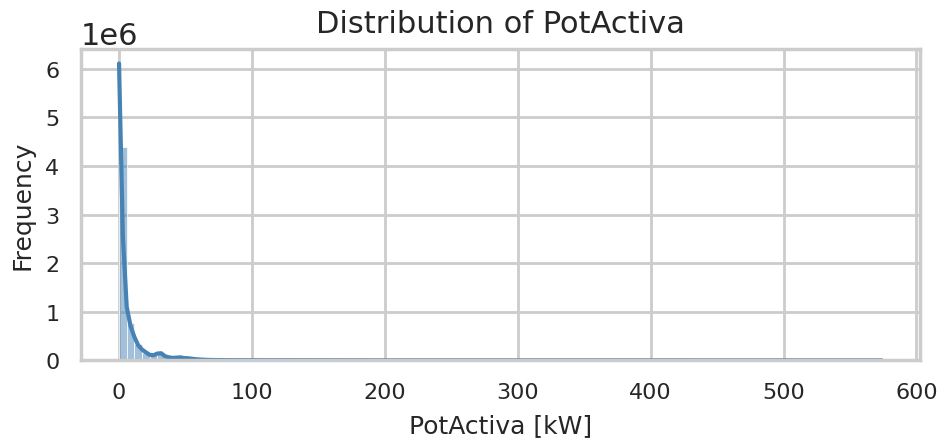

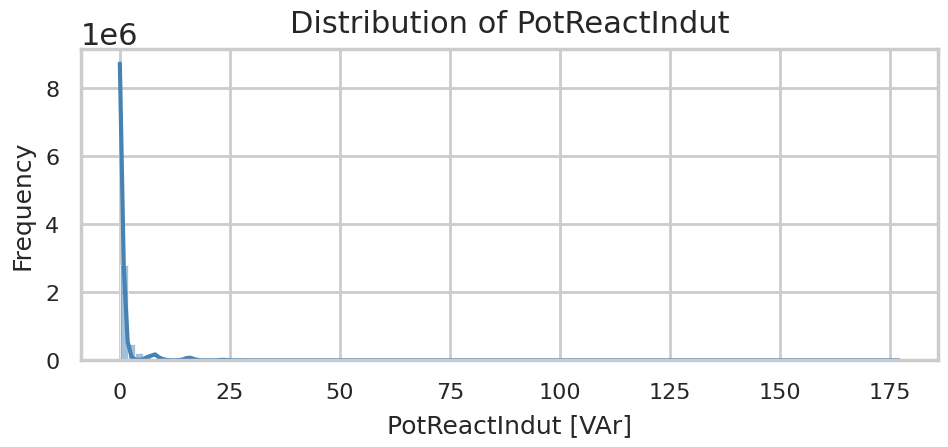

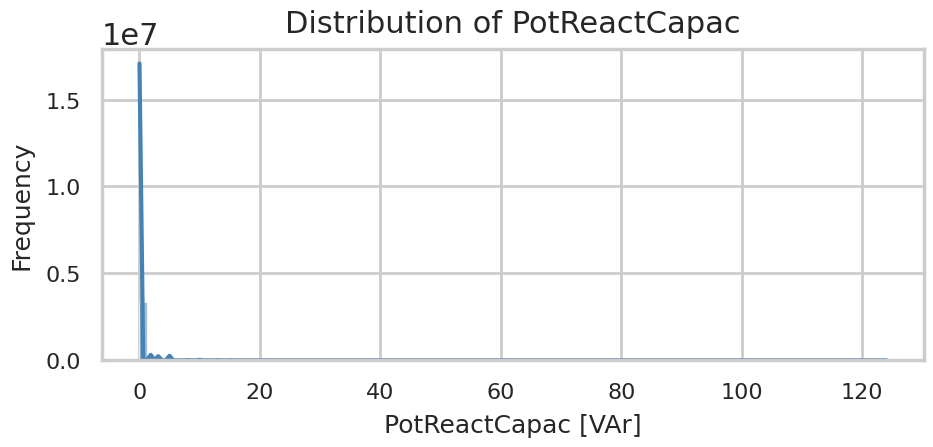

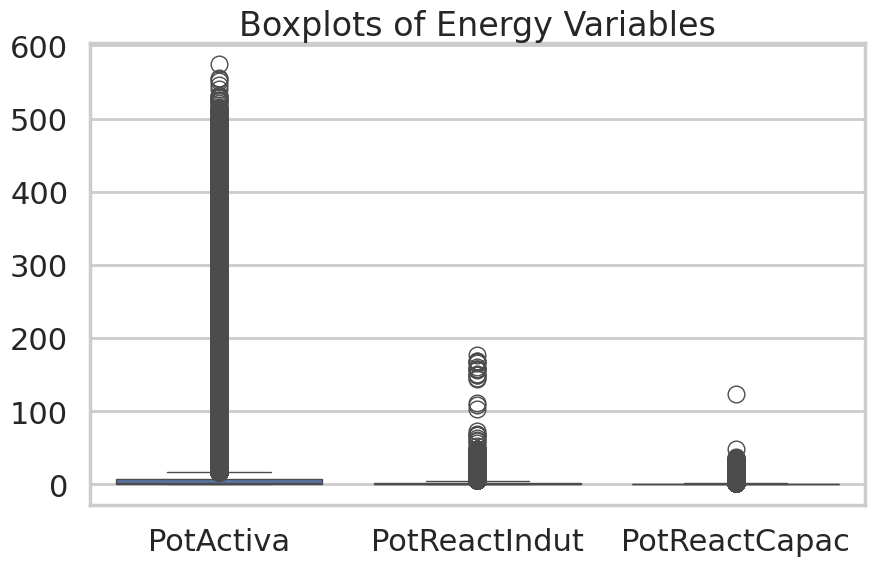

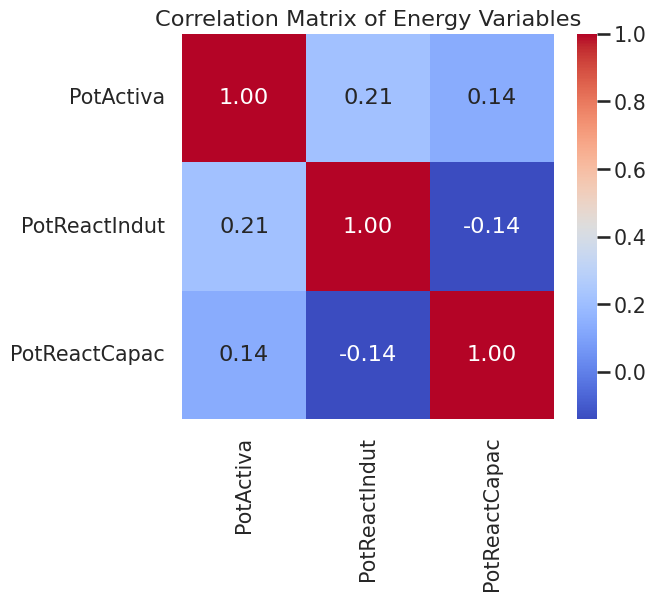

<Figure size 1200x500 with 0 Axes>

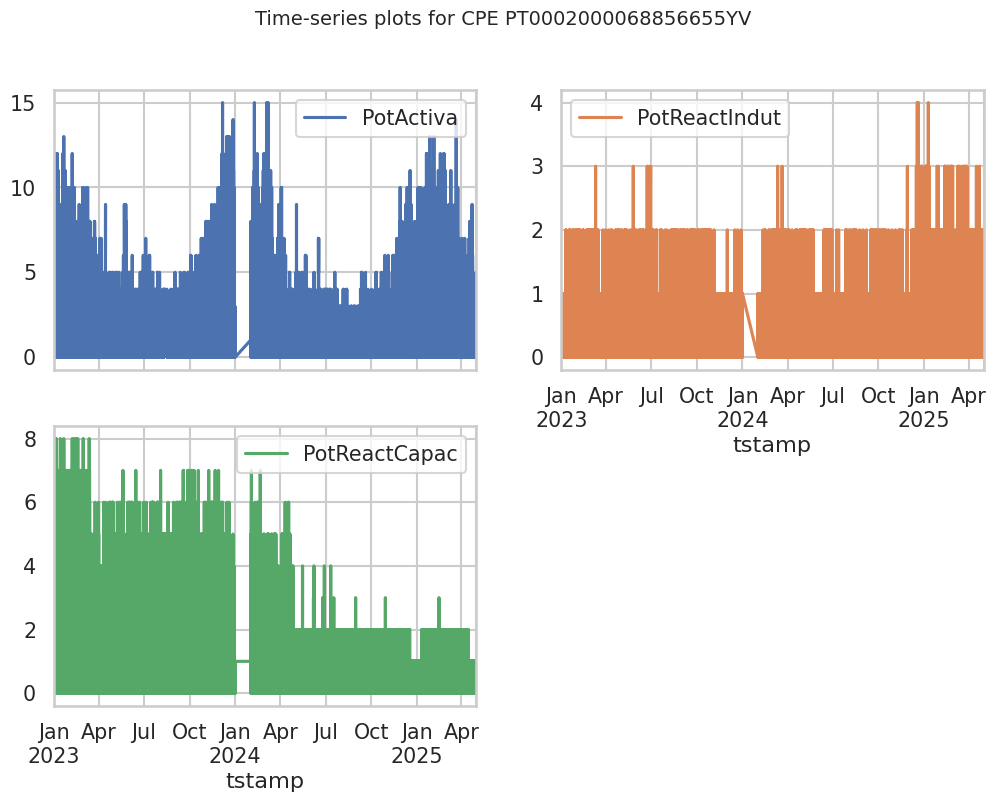

Cleaned dataset saved to data/cleaned_d4maia.parquet


/tmp/ipython-input-588022929.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_features = df_clean.groupby("CPE")[measure_cols].agg(


Aggregated features saved to data/agg_features.parquet


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# === Stile e dimensioni globali (testi più grandi) ===
sns.set_theme(style="whitegrid")
sns.set_context("poster", font_scale=1.0)


# Mappa delle unità per ciascuna colonna
units_map = {
    'PotActiva': '[kW]',
    'PotReactIndut': '[VAr]',
    'PotReactCapac': '[VAr]'
}

# --- Distribuzioni ---
for col in measure_cols:
    if col in df_clean.columns:
        plt.figure(figsize=(10, 5))  # leggermente più ampio
        ax = sns.histplot(
            df_clean[col].dropna(),
            bins=100,
            kde=True,
            color='steelblue'
        )
        unit = units_map.get(col, '')
        ax.set_title(f"Distribution of {col}", fontsize=22, pad=12)
        ax.set_xlabel(f"{col} {unit}", fontsize=18, labelpad=8)
        ax.set_ylabel("Frequency", fontsize=18, labelpad=8)
        ax.tick_params(axis='both', which='major', labelsize=16)
        plt.tight_layout()
        plt.show()

# Boxplots to detect outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean[measure_cols])
plt.title("Boxplots of Energy Variables")
plt.show()

# === Da qui in poi: testi più piccoli ===
sns.set_context("talk", font_scale=0.9)  # più piccolo e leggibile

# Correlation heatmap
corr = df_clean[measure_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Energy Variables")
plt.show()

# Time-series visualization for one sample CPE
sample_cpe = df_clean['CPE'].unique()[0]
df_sample = df_clean[df_clean['CPE'] == sample_cpe]

plt.figure(figsize=(12,5))
df_sample[measure_cols].plot(subplots=True, layout=(2,2), figsize=(12,8), sharex=True)
plt.suptitle(f"Time-series plots for CPE {sample_cpe}", fontsize=14)
plt.show()

# Save cleaned dataset (compressed for efficiency)
clean_path = "data/cleaned_d4maia.parquet"
df_clean.to_parquet(clean_path, compression="snappy")
print(f"Cleaned dataset saved to {clean_path}")

# Save aggregated features per CPE (for clustering/classical ML)
agg_features = df_clean.groupby("CPE")[measure_cols].agg(
    ['mean','std','max','min']
)
agg_features.columns = ['_'.join(col) for col in agg_features.columns]
agg_path = "data/agg_features.parquet"
agg_features.to_parquet(agg_path, compression="snappy")
print(f"Aggregated features saved to {agg_path}")

# Task
Plot the monthly average values for the sample CPE, showing the trend across all available months, then iterate through all unique months present in the `df_cpe` DataFrame and generate a separate plot for the daily average values of `PotActiva`, `PotReactIndut`, and `PotReactCapac` for each month. After that, plot hourly profiles for a few selected days, ensuring the selected days fall within an existing month in the data. Finally, summarize the generated plots and highlight any key insights observed from the monthly and daily trend visualizations.

## Plot Monthly Averages

### Subtask:
Review the plot displaying the monthly average values for the sample CPE.


<Figure size 1200x600 with 0 Axes>

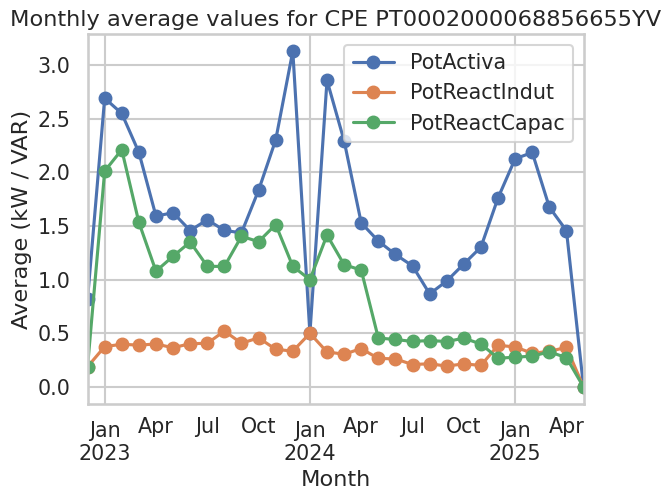

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


<Figure size 1200x600 with 0 Axes>

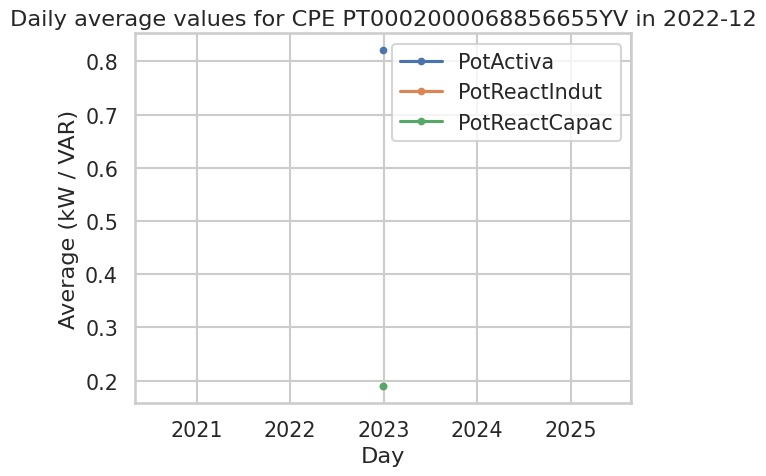

<Figure size 1200x600 with 0 Axes>

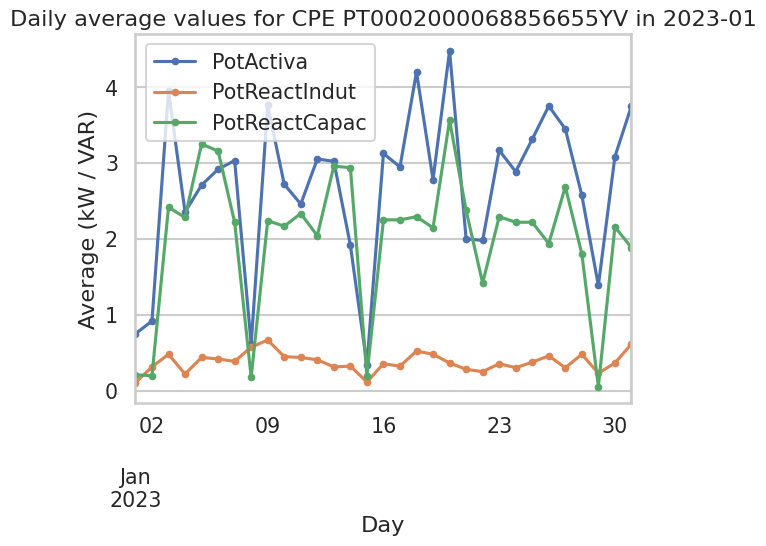

<Figure size 1200x600 with 0 Axes>

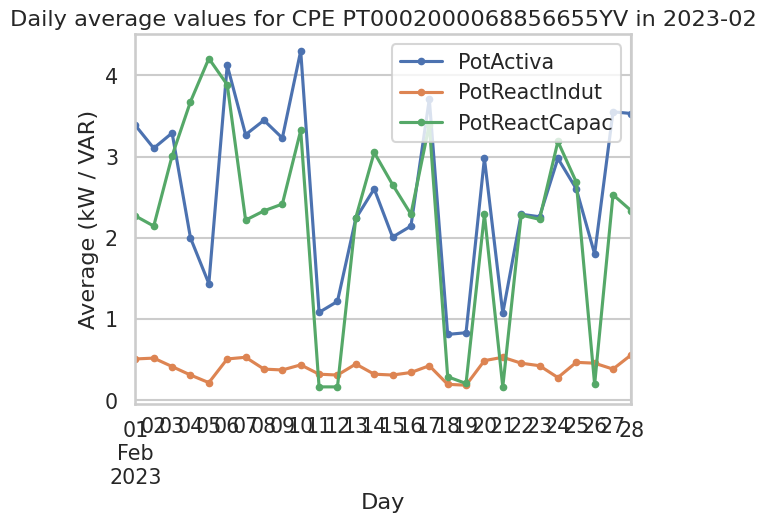

<Figure size 1200x600 with 0 Axes>

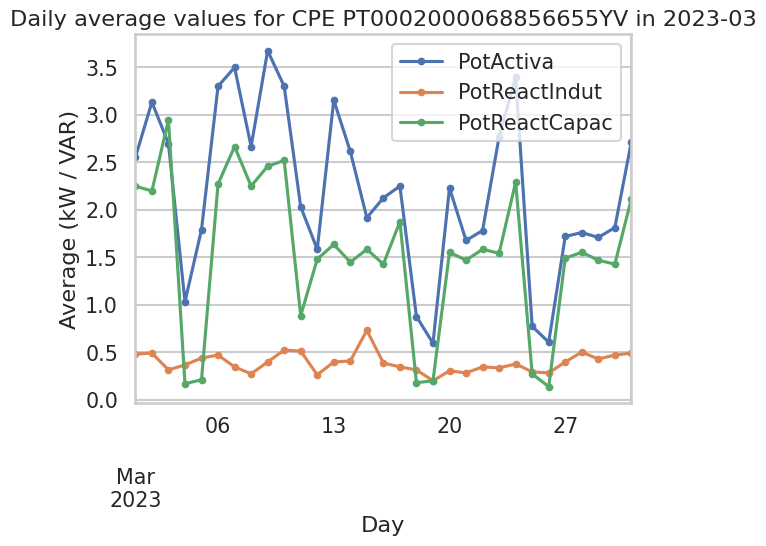

<Figure size 1200x600 with 0 Axes>

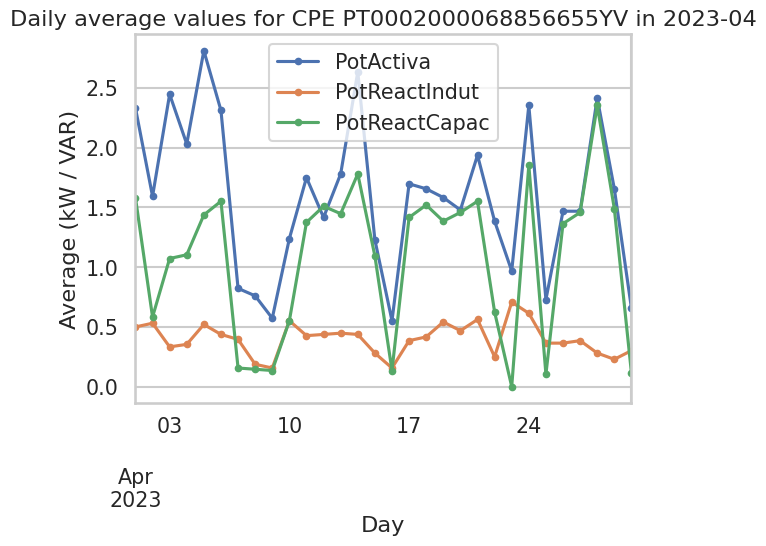

<Figure size 1200x600 with 0 Axes>

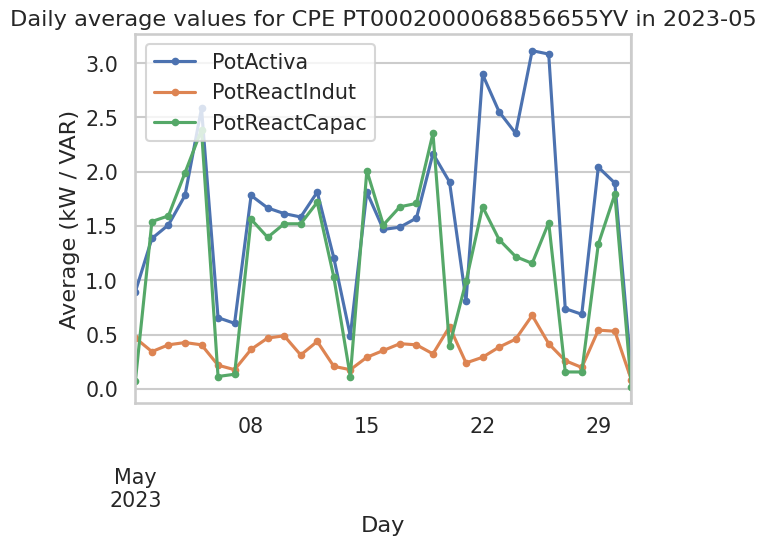

<Figure size 1200x600 with 0 Axes>

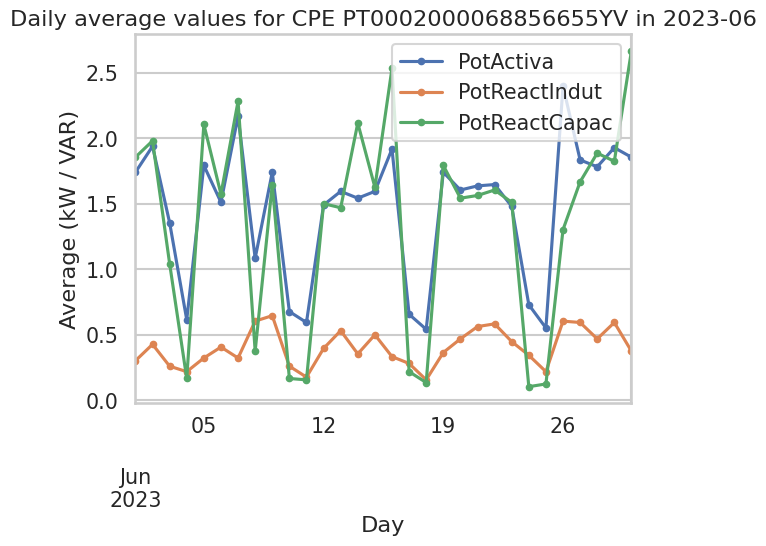

<Figure size 1200x600 with 0 Axes>

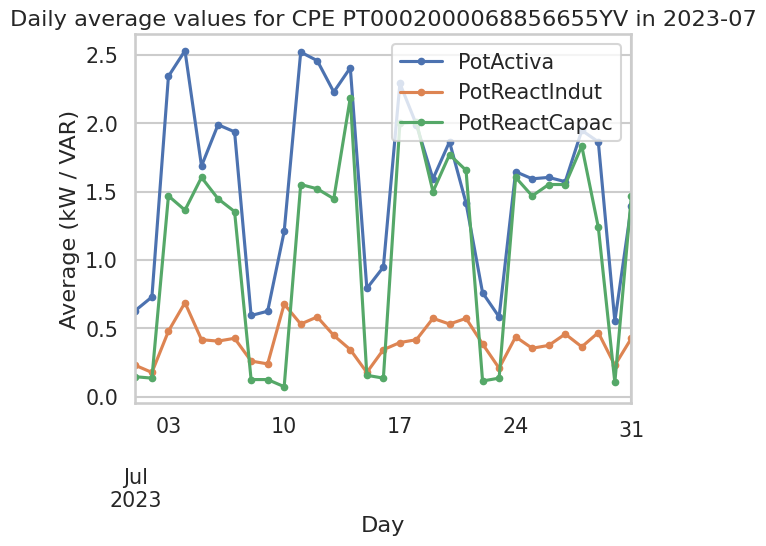

<Figure size 1200x600 with 0 Axes>

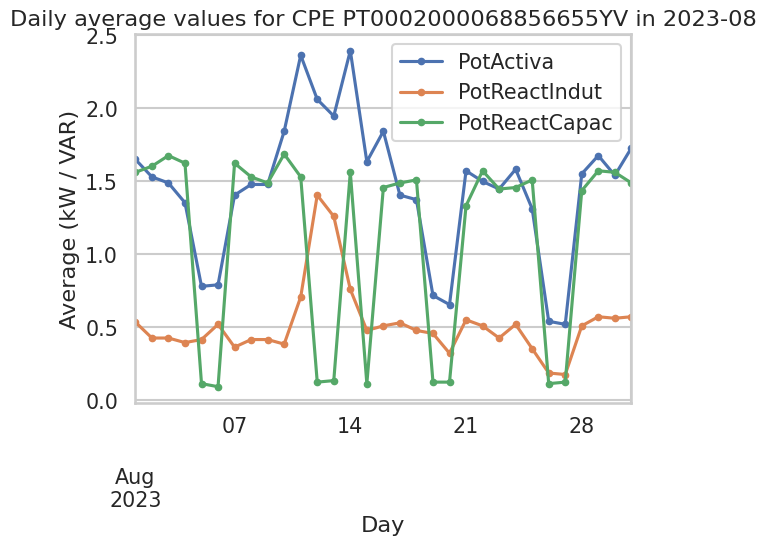

<Figure size 1200x600 with 0 Axes>

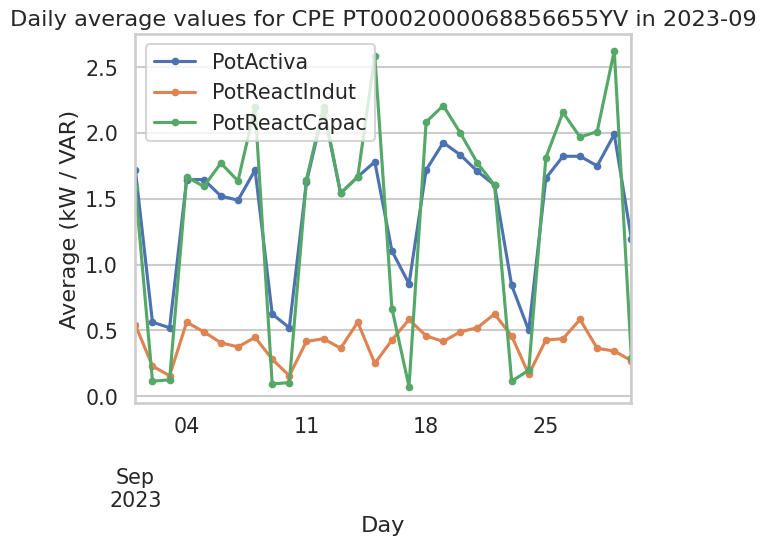

<Figure size 1200x600 with 0 Axes>

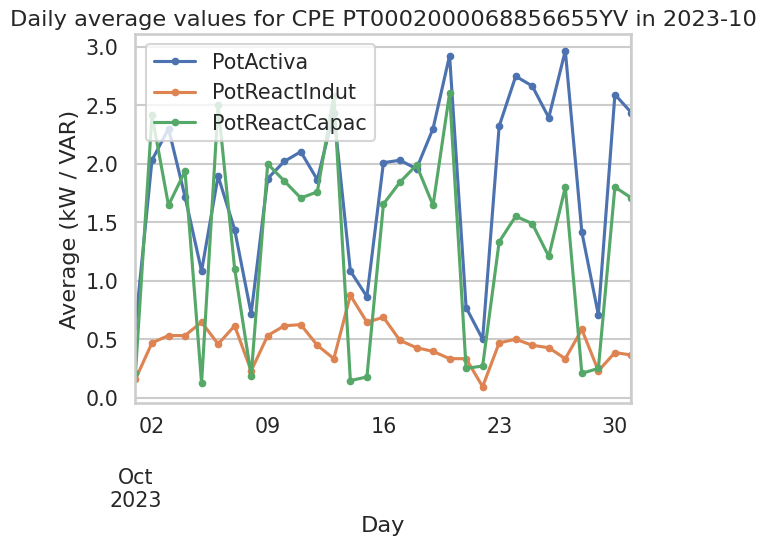

<Figure size 1200x600 with 0 Axes>

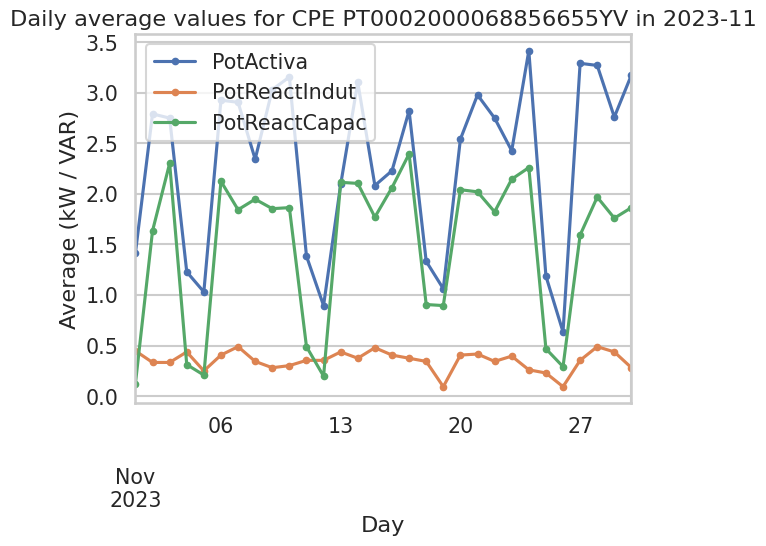

<Figure size 1200x600 with 0 Axes>

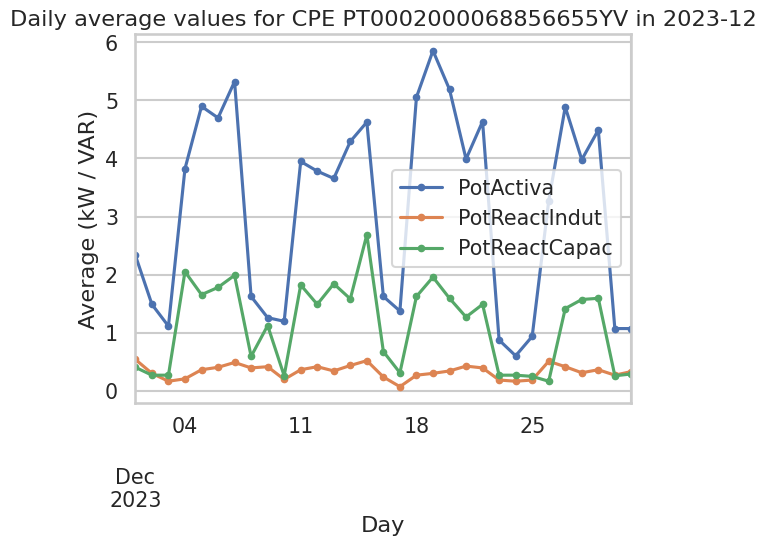

<Figure size 1200x600 with 0 Axes>

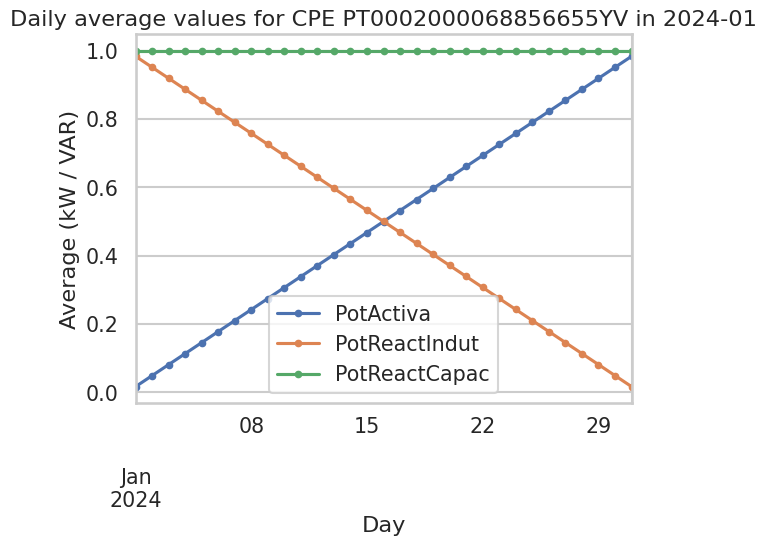

<Figure size 1200x600 with 0 Axes>

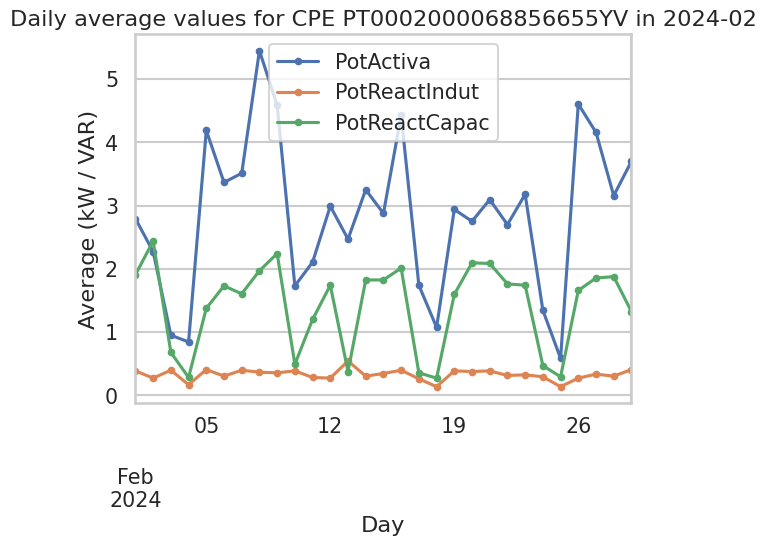

<Figure size 1200x600 with 0 Axes>

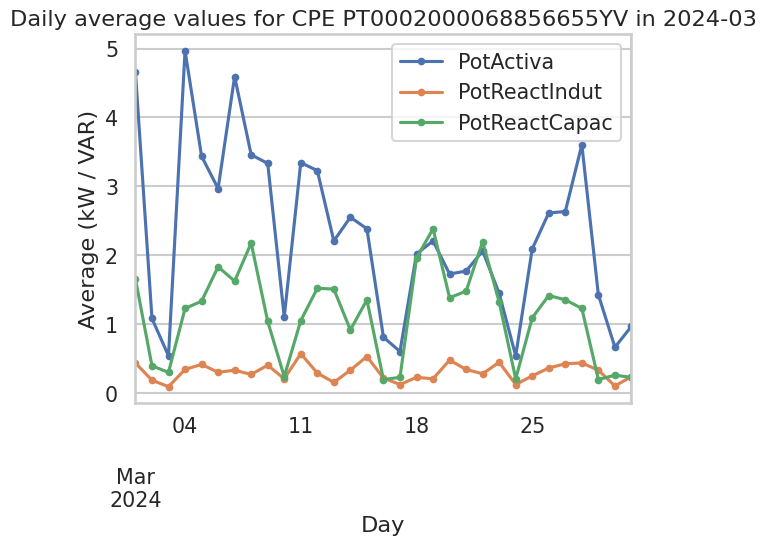

<Figure size 1200x600 with 0 Axes>

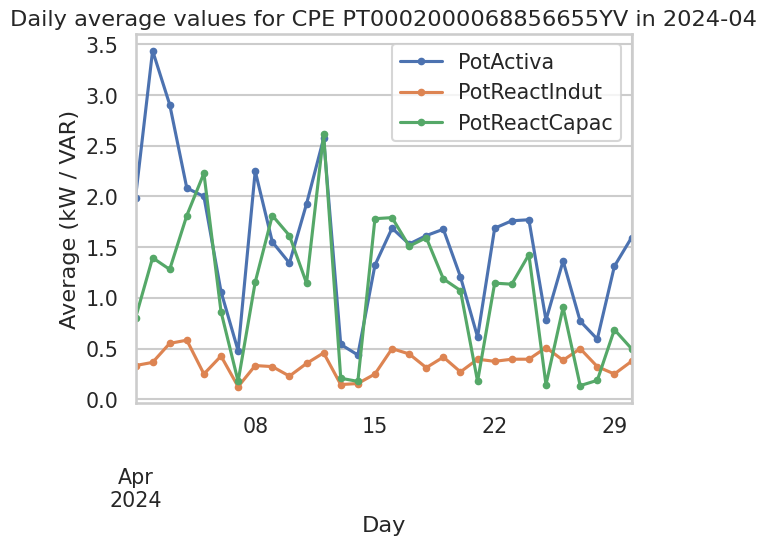

<Figure size 1200x600 with 0 Axes>

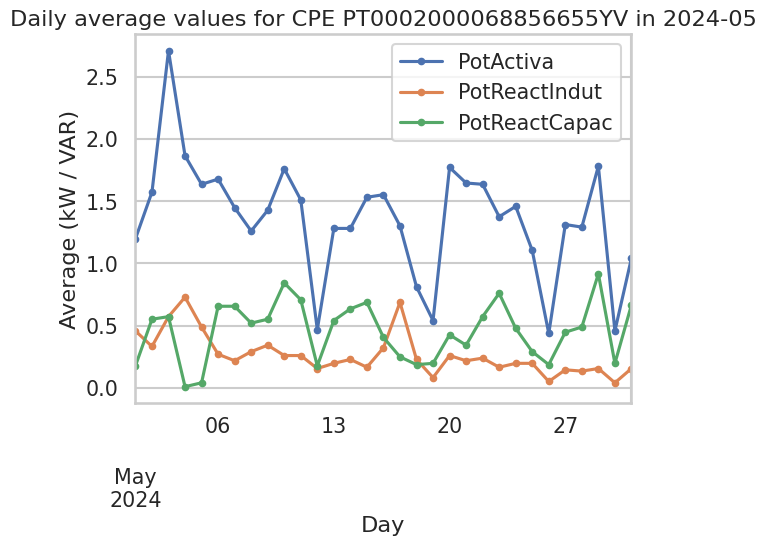

<Figure size 1200x600 with 0 Axes>

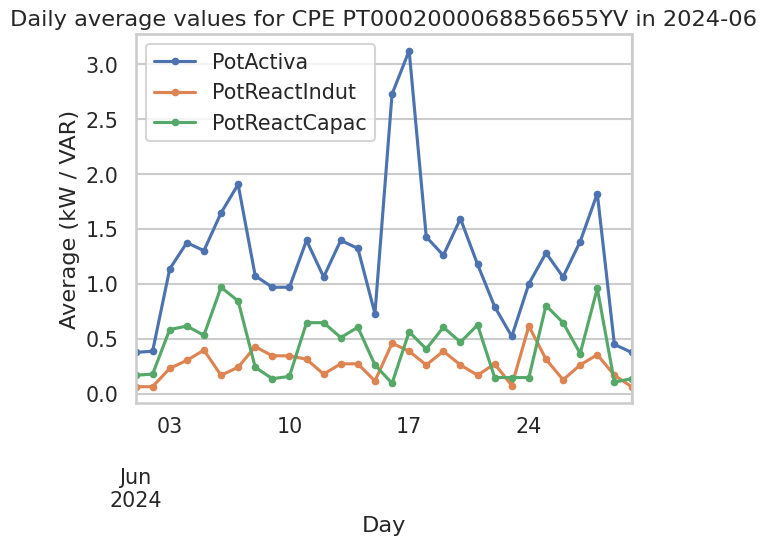

<Figure size 1200x600 with 0 Axes>

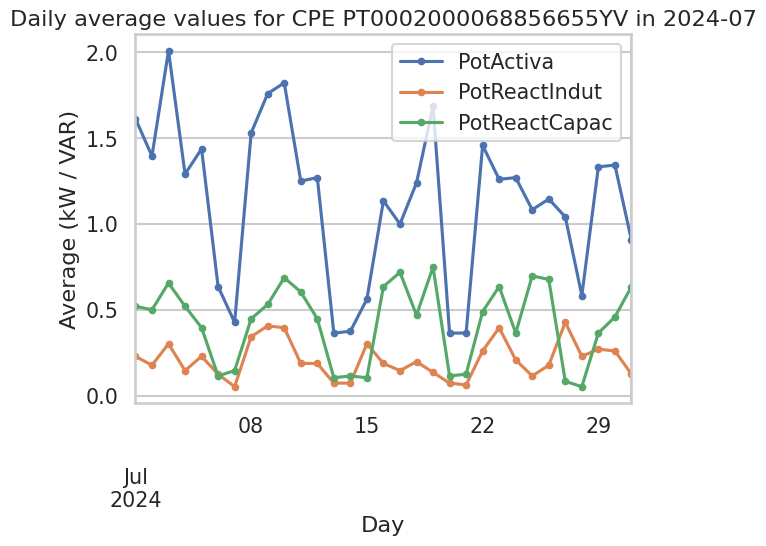

<Figure size 1200x600 with 0 Axes>

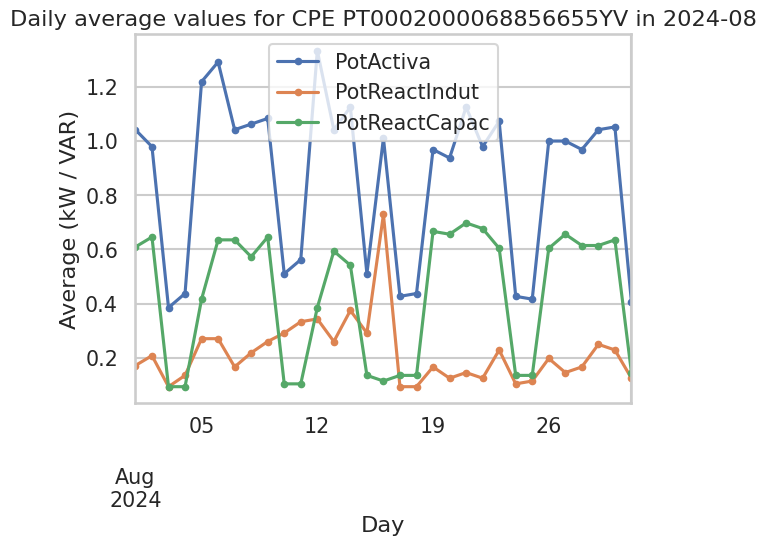

<Figure size 1200x600 with 0 Axes>

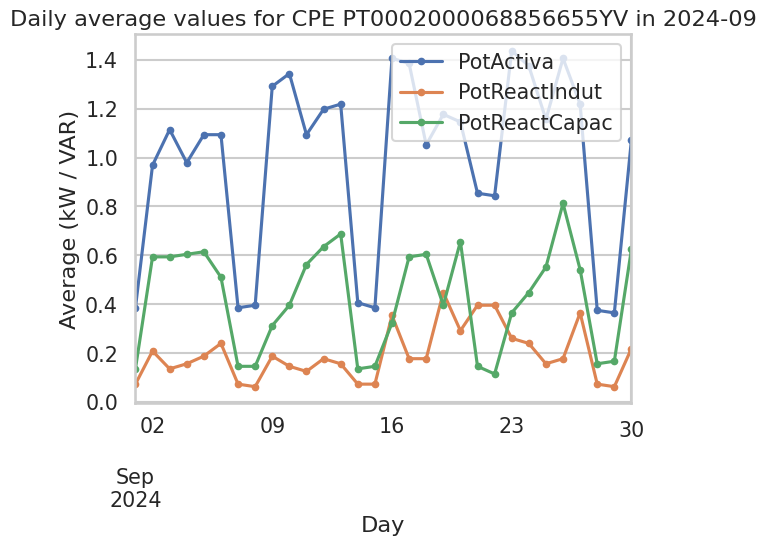

<Figure size 1200x600 with 0 Axes>

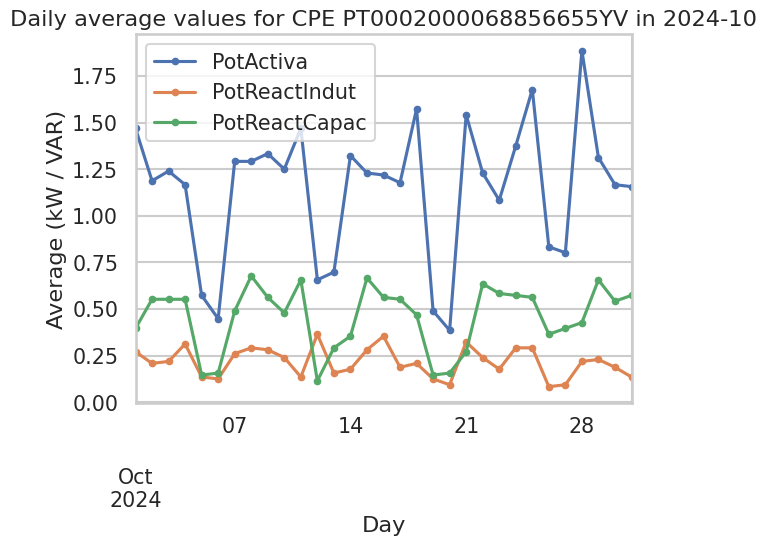

<Figure size 1200x600 with 0 Axes>

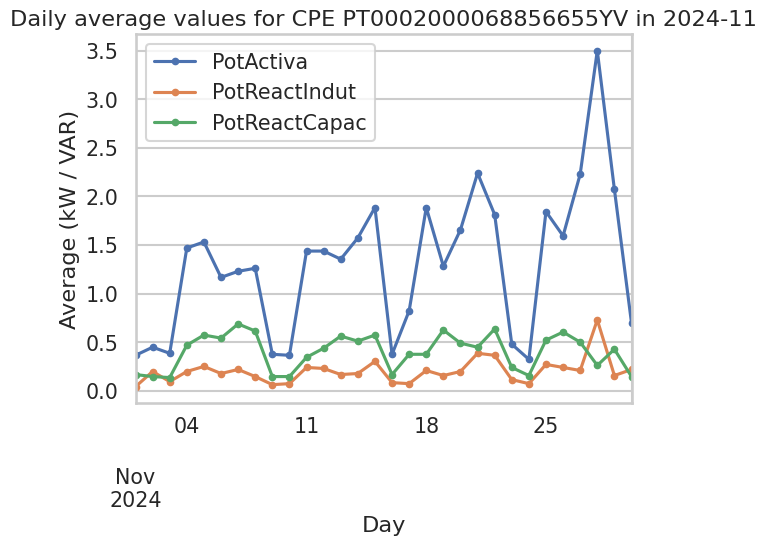

<Figure size 1200x600 with 0 Axes>

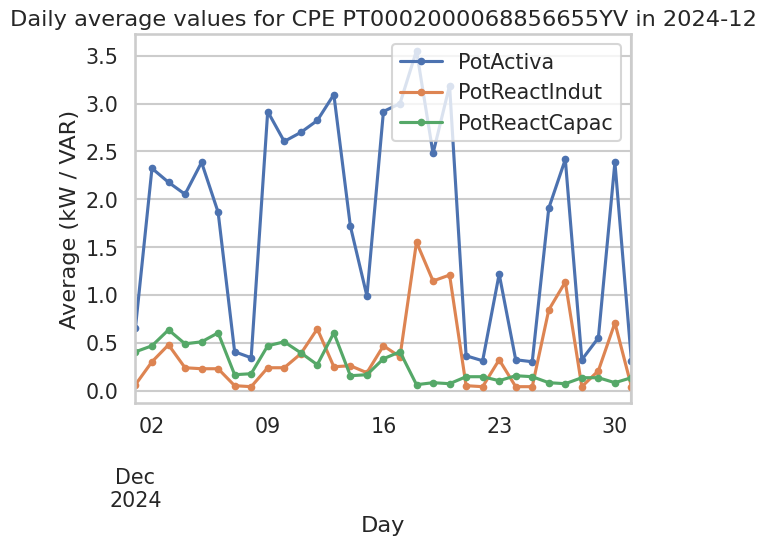

<Figure size 1200x600 with 0 Axes>

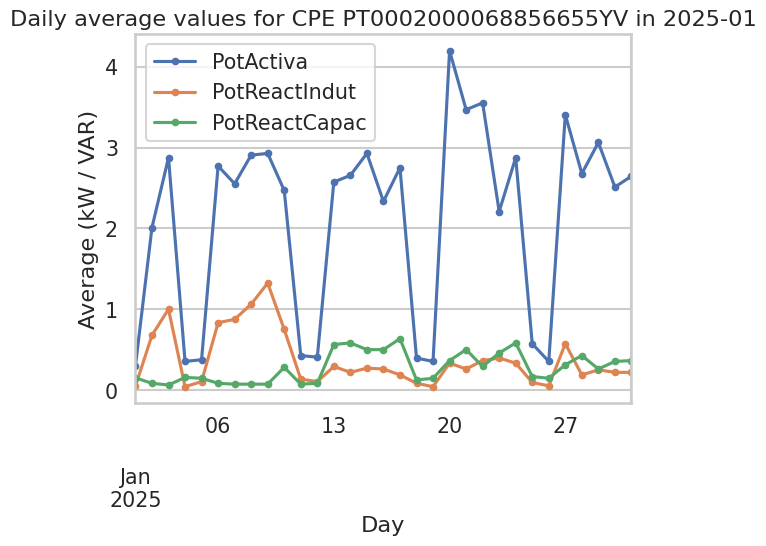

<Figure size 1200x600 with 0 Axes>

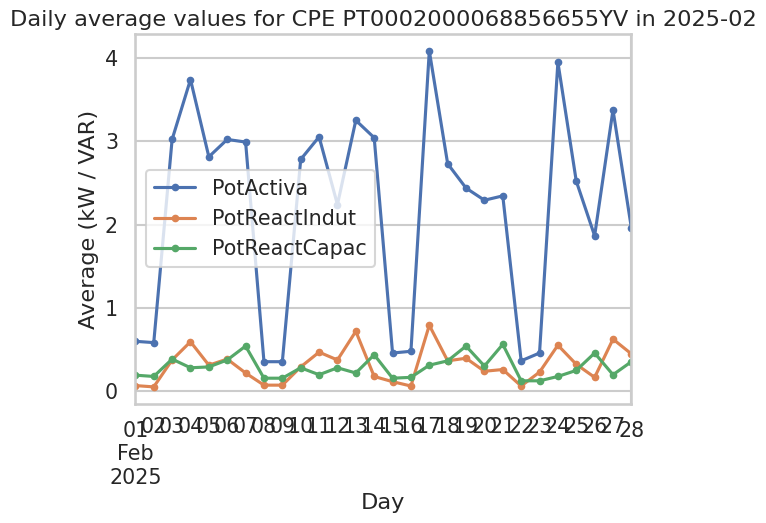

<Figure size 1200x600 with 0 Axes>

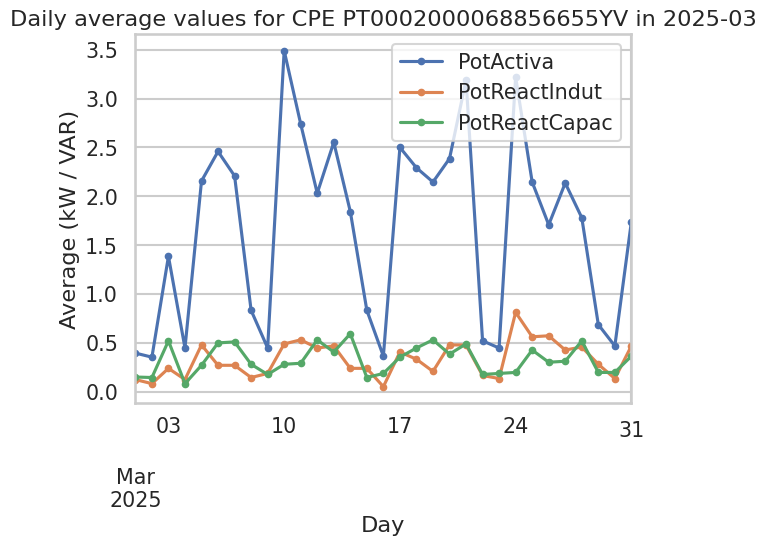

<Figure size 1200x600 with 0 Axes>

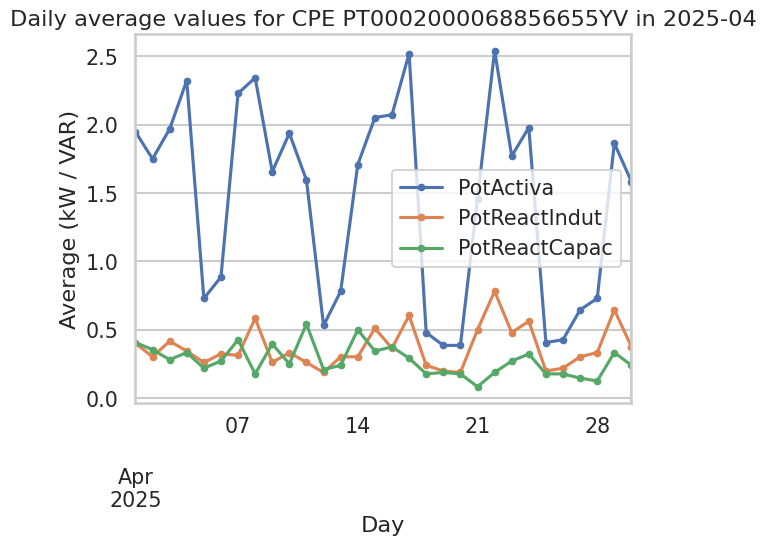

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


<Figure size 1200x600 with 0 Axes>

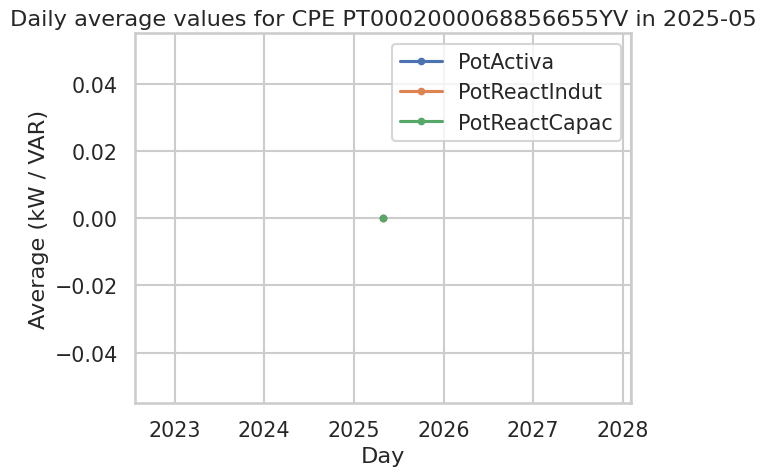

/tmp/ipython-input-3543697841.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_day[measure_cols].resample('H').mean()


<Figure size 1000x500 with 0 Axes>

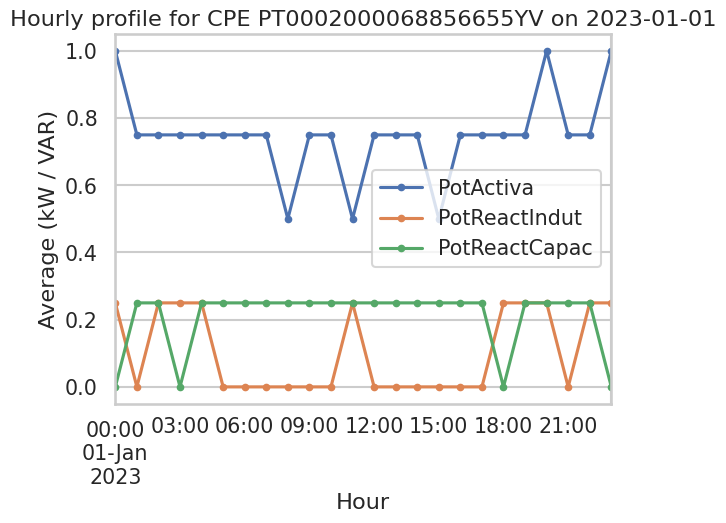

/tmp/ipython-input-3543697841.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_day[measure_cols].resample('H').mean()


<Figure size 1000x500 with 0 Axes>

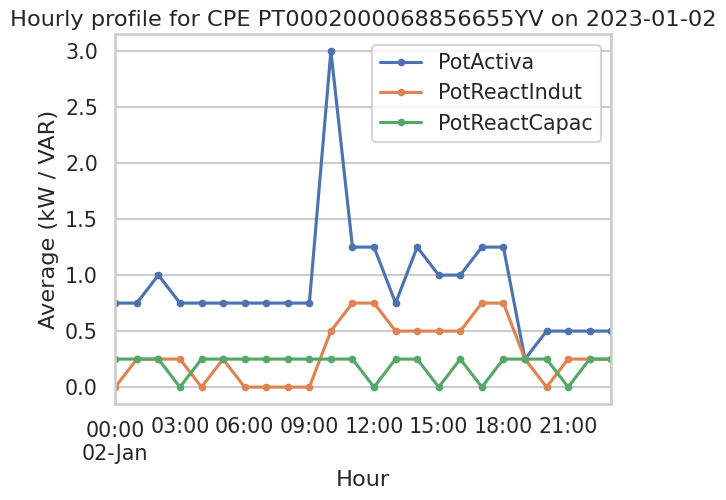

/tmp/ipython-input-3543697841.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_day[measure_cols].resample('H').mean()


<Figure size 1000x500 with 0 Axes>

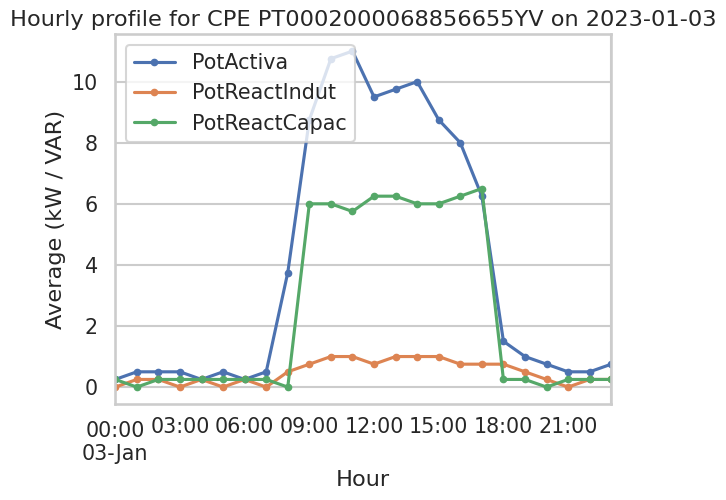

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose one CPE
sample_cpe = df_clean['CPE'].unique()[0]
df_cpe = df_clean[df_clean['CPE'] == sample_cpe]

# Monthly Aggregates
monthly = df_cpe[measure_cols].resample('ME').mean()

plt.figure(figsize=(12,6))
monthly.plot(marker='o')
plt.title(f"Monthly average values for CPE {sample_cpe}")
plt.ylabel("Average (kW / VAR)")
plt.xlabel("Month")
plt.legend(measure_cols)
plt.show()

# Daily Profiles (within each month)
unique_months = df_cpe.index.to_period('M').unique().strftime('%Y-%m').tolist()

# Generate daily average plots for each unique month
for month_to_plot in unique_months:
    # Use .loc for robust time-based slicing
    df_month = df_cpe.loc[month_to_plot]

    if not df_month.empty:
        daily = df_month[measure_cols].resample('D').mean()

        plt.figure(figsize=(12,6))
        daily.plot(marker='.')
        plt.title(f"Daily average values for CPE {sample_cpe} in {month_to_plot}")
        plt.ylabel("Average (kW / VAR)")
        plt.xlabel("Day")
        plt.legend(measure_cols)
        plt.show()
    else:
        print(f"No data for month {month_to_plot} for CPE {sample_cpe}")

# Hourly Profiles (for selected days)
first_full_month = '2023-01'
days_to_plot = [f'{first_full_month}-01', f'{first_full_month}-02', f'{first_full_month}-03'] # Pick first few days of this month

for day in days_to_plot:
    # Use .loc for robust time-based slicing
    df_day = df_cpe.loc[day]

    if not df_day.empty:
        hourly = df_day[measure_cols].resample('H').mean()

        plt.figure(figsize=(10,5))
        hourly.plot(marker='.')
        plt.title(f"Hourly profile for CPE {sample_cpe} on {day}")
        plt.ylabel("Average (kW / VAR)")
        plt.xlabel("Hour")
        plt.legend(measure_cols)
        plt.show()
    else:
        print(f"No data for day {day} for CPE {sample_cpe}")

/tmp/ipython-input-662353063.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_cpe[measure_cols].resample('M').mean()


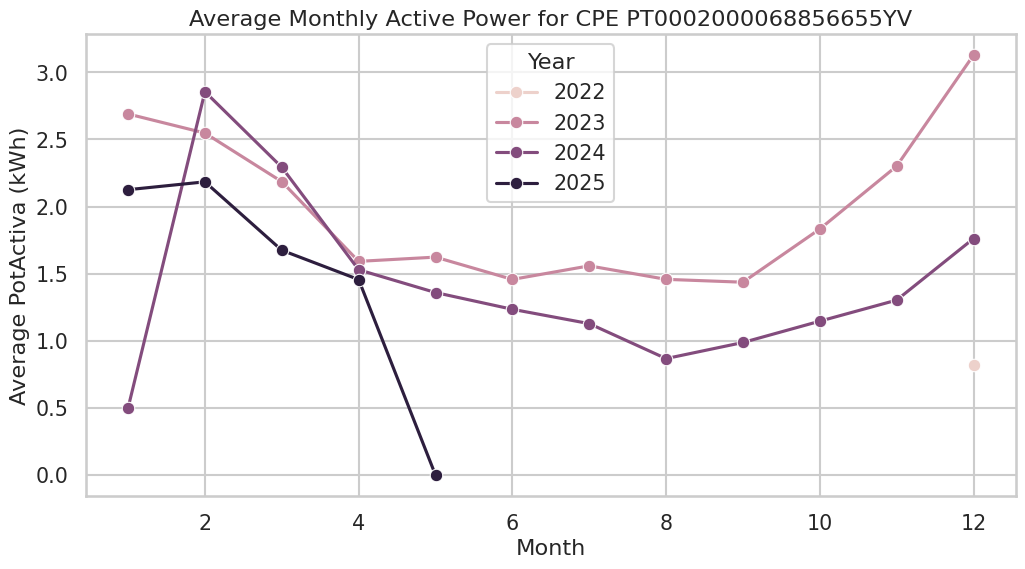

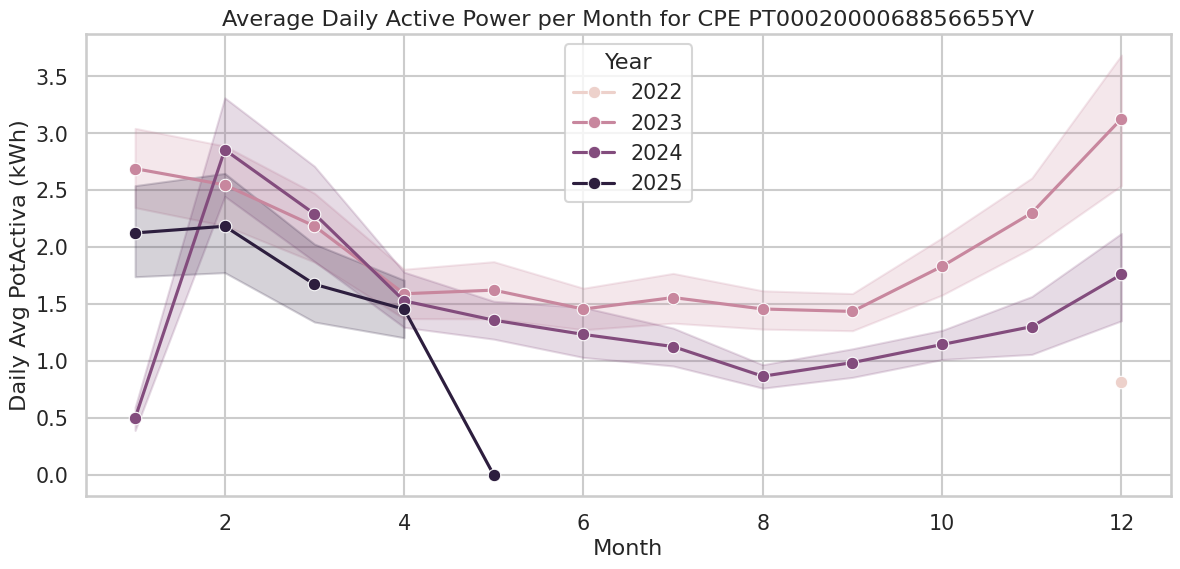

/tmp/ipython-input-662353063.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_cpe[measure_cols].resample('H').mean()


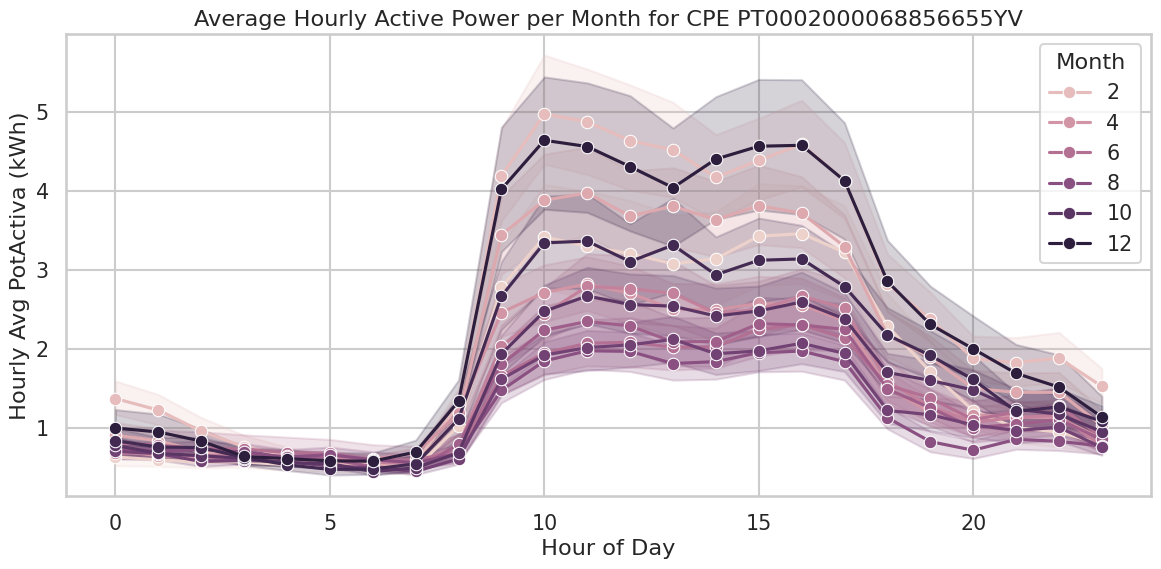

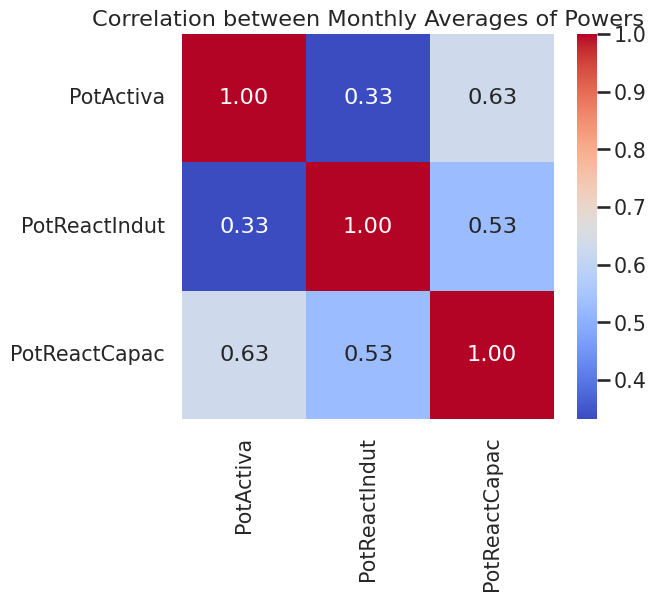

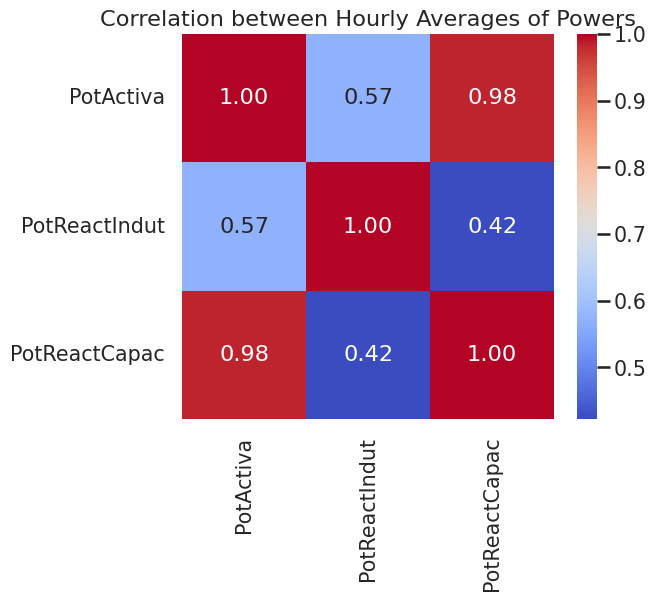

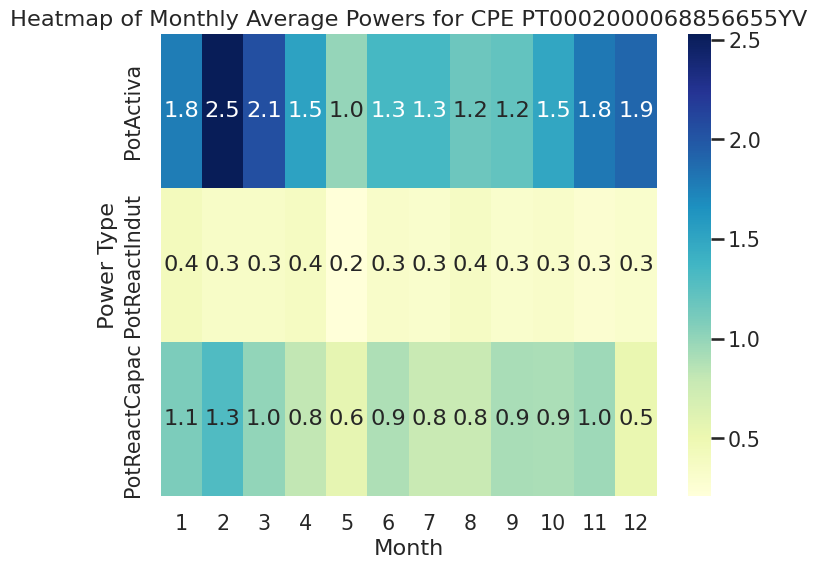

<Figure size 800x600 with 0 Axes>

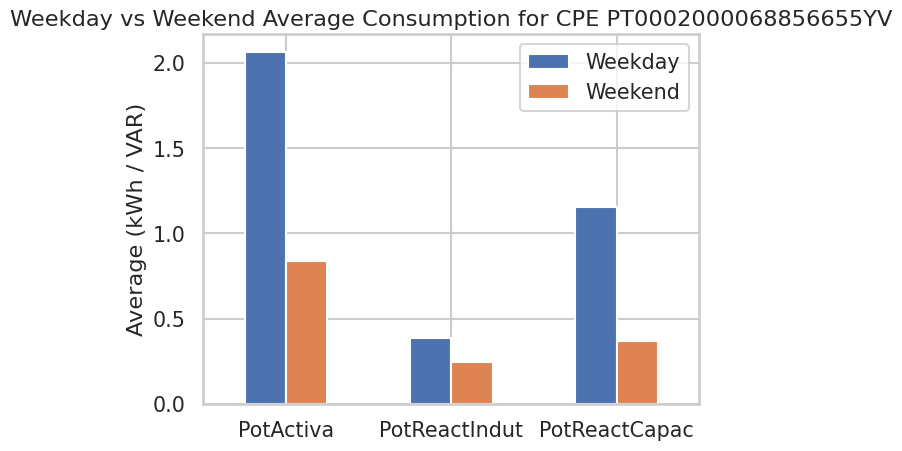

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose one CPE
sample_cpe = df_clean['CPE'].unique()[0]
df_cpe = df_clean[df_clean['CPE'] == sample_cpe].copy()

# 1) Average monthly consumption for each year
monthly = df_cpe[measure_cols].resample('M').mean()
monthly['Year'] = monthly.index.year
monthly['Month'] = monthly.index.month

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly, x='Month', y='PotActiva', hue='Year', marker='o')
plt.title(f"Average Monthly Active Power for CPE {sample_cpe}")
plt.ylabel("Average PotActiva (kWh)")
plt.xlabel("Month")
plt.legend(title="Year")
plt.show()

# 2) Average daily consumption for each month and year
daily = df_cpe[measure_cols].resample('D').mean()
daily['Year'] = daily.index.year
daily['Month'] = daily.index.month

plt.figure(figsize=(14,6))
sns.lineplot(data=daily, x='Month', y='PotActiva', hue='Year', estimator='mean', marker='o')
plt.title(f"Average Daily Active Power per Month for CPE {sample_cpe}")
plt.ylabel("Daily Avg PotActiva (kWh)")
plt.xlabel("Month")
plt.show()

# 3) Average hourly consumption for each month
hourly = df_cpe[measure_cols].resample('H').mean()
hourly['Hour'] = hourly.index.hour
hourly['Month'] = hourly.index.month

plt.figure(figsize=(14,6))
sns.lineplot(data=hourly, x='Hour', y='PotActiva', hue='Month', estimator='mean', marker='o')
plt.title(f"Average Hourly Active Power per Month for CPE {sample_cpe}")
plt.ylabel("Hourly Avg PotActiva (kWh)")
plt.xlabel("Hour of Day")
plt.legend(title="Month")
plt.show()

# 4) Correlations between months or hours
# Monthly correlation
monthly_corr = monthly.groupby('Month')[measure_cols].mean().corr()
plt.figure(figsize=(6,5))
sns.heatmap(monthly_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Monthly Averages of Powers")
plt.show()

# Hourly correlation
hourly_corr = hourly.groupby('Hour')[measure_cols].mean().corr()
plt.figure(figsize=(6,5))
sns.heatmap(hourly_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Hourly Averages of Powers")
plt.show()

# 5) Heatmap for average monthly between the powers
monthly_avg = monthly.groupby('Month')[measure_cols].mean()
plt.figure(figsize=(8,6))
sns.heatmap(monthly_avg.T, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title(f"Heatmap of Monthly Average Powers for CPE {sample_cpe}")
plt.xlabel("Month")
plt.ylabel("Power Type")
plt.show()

# 6) Other types of comparison
df_cpe.loc[:, 'Weekday'] = df_cpe.index.weekday
df_cpe.loc[:, 'IsWeekend'] = df_cpe['Weekday'] >= 5

weekday_avg = df_cpe.groupby('IsWeekend')[measure_cols].mean()

plt.figure(figsize=(8,6))
weekday_avg.T.plot(kind='bar')
plt.title(f"Weekday vs Weekend Average Consumption for CPE {sample_cpe}")
plt.ylabel("Average (kWh / VAR)")
plt.xticks(rotation=0)
plt.legend(["Weekday","Weekend"])
plt.show()

Create functions to calculate average power consumptions during different timeslopes.

In [ ]:
import pandas as pd
import numpy as np

def avg_daily_peak_value(df_cpe, col='PotActiva'):
    """
    Calculates the Average Daily Peak Load (kW).
    1. Finds the maximum value for each day (Daily Max).
    2. Returns the average of these daily maximums.
    """
    daily_maxes = df_cpe[col].resample('D').max()

    return daily_maxes.mean()

def avg_daily_peak_time(df_cpe, col='PotActiva'):
    #Compute average time of daily peak consumption. Returns mean hour of peak load across all days.
    daily_peak_times = (
        df_cpe[col]
        .resample('D')
        .apply(lambda x: x.idxmax().hour if not x.empty else np.nan)
    )
    return daily_peak_times.mean()

def avg_time_below_half_peak(df_cpe, col='PotActiva', threshold_ratio=0.5):
    #Compute average time per day where consumption is below threshold_ratio * daily max.
    results = []
    for day, group in df_cpe[col].resample('D'):
        if group.empty:
            continue
        threshold = group.max() * threshold_ratio
        below = (group < threshold).sum()
        results.append(below * 15)                                              # 15 minutes per sample
    return np.mean(results) if results else np.nan

def avg_time_below_threshold(df_cpe, col='PotActiva', threshold_ratio=0.25):
    #Compute average time per day where consumption is below threshold_ratio * daily max.
    results = []
    for day, group in df_cpe[col].resample('D'):
        if group.empty:
            continue
        threshold = group.max() * threshold_ratio
        below = (group < threshold).sum()
        results.append(below * 15)                                              # 15 minutes per sample
    return np.mean(results) if results else np.nan

def avg_time_above_threshold(df_cpe, col='PotActiva', threshold_ratio=0.75):
    #Compute average time per day where consumption is below threshold_ratio * daily max.
    results = []
    for day, group in df_cpe[col].resample('D'):
        if group.empty:
            continue
        threshold = group.max() * threshold_ratio
        below = (group > threshold).sum()
        results.append(below * 15)                                              # 15 minutes per sample
    return np.mean(results) if results else np.nan

def load_variability_index(df_cpe, col='PotActiva'):
    #Standard deviation / mean of daily consumption.
    daily_mean = df_cpe[col].resample('D').mean()
    return daily_mean.std() / daily_mean.mean() if daily_mean.mean() != 0 else np.nan

def peak_to_average_ratio(df_cpe, col='PotActiva'):
    #Ratio of max daily consumption to average daily consumption.
    daily_mean = df_cpe[col].resample('D').mean()
    daily_max = df_cpe[col].resample('D').max()
    return (daily_max.mean() / daily_mean.mean()) if daily_mean.mean() != 0 else np.nan

def seasonal_consumption_ratio(df_cpe, col='PotActiva'):
    #Ratio of average winter (Dec–Feb) to summer (Jun–Aug) consumption.
    winter = df_cpe[df_cpe.index.month.isin([12,1,2])][col].mean()
    summer = df_cpe[df_cpe.index.month.isin([6,7,8])][col].mean()
    return (winter / summer) if summer != 0 else np.nan

def weekday_weekend_ratio(df_cpe, col='PotActiva'):
    #Ratio of average weekday to weekend consumption.
    df_cpe_local = df_cpe.copy()                                                # Make a local copy to avoid SettingWithCopyWarning
    df_cpe_local['Weekday'] = df_cpe_local.index.weekday
    weekday = df_cpe_local[df_cpe_local['Weekday'] < 5][col].mean()
    weekend = df_cpe_local[df_cpe_local['Weekday'] >= 5][col].mean()
    return (weekday / weekend) if weekend != 0 else np.nan

def nighttime_load_share(df_cpe, col='PotActiva'):
    #Fraction of consumption between 00:00–06:00 relative to total
    night = df_cpe.between_time('00:00','06:00')[col].sum()
    total = df_cpe[col].sum()
    return (night / total) if total != 0 else np.nan

def worktime_load_share(df_cpe, col='PotActiva'):
    #Fraction of consumption between 00:00–06:00 relative to total
    day = df_cpe.between_time('07:00','18:00')[col].sum()
    total = df_cpe[col].sum()
    return (day / total) if total != 0 else np.nan

import numpy as np

def get_power_factor(df_cpe):
    # 1. Sum total consumption for the period (P and Q)
    P = df_cpe['PotActiva'].sum()
    I = df_cpe['PotReactIndut'].sum() # We typically use Inductive for lag PF issues
    C = df_cpe['PotReactCapac'].sum()
    # 2. Calculate Apparent Power (S)
    S = np.sqrt(P**2 + (C+I)**2)

    # 3. Calculate Ratio (avoid division by zero)
    if S == 0:
        return 1.0  # Default to perfect PF if no consumption

    return P / S

def get_power_over_ind(df_cpe):
  P = df_cpe['PotActiva'].sum()
  C= df_cpe['PotReactCapac'].sum()
  I = df_cpe['PotReactIndut'].sum()
  S = np.sqrt(P**2 + (I)**2)

  if S == 0:
      return 1.0

  return I / S

def get_power_over_cap(df_cpe):
  P = df_cpe['PotActiva'].sum()
  I = df_cpe['PotReactIndut'].sum()
  C = df_cpe['PotReactCapac'].sum()
  S = np.sqrt(P**2 + (C)**2)

  if S == 0:
      return 1.0

  return C / S

In [ ]:
feature_rows = []

print("Generating integrated feature set...")

for cpe in df_clean['CPE'].unique():
    # Explicitly make a copy here to avoid SettingWithCopyWarning
    df_cpe = df_clean[df_clean['CPE'] == cpe].copy()

    # Build the single dictionary with ALL features
    feats = {
        'CPE': cpe,
        # Existing statistical features
        'avg_daily_peak_value': avg_daily_peak_value(df_cpe),
        'avg_daily_peak_time': avg_daily_peak_time(df_cpe),
        'avg_time_below_50pct': avg_time_below_half_peak(df_cpe, threshold_ratio=0.5),
        'avg_time_below_25pct': avg_time_below_threshold(df_cpe, threshold_ratio=0.25),
        'avg_time_above_75pct': avg_time_above_threshold(df_cpe, threshold_ratio=0.75),
        'load_variability_index': load_variability_index(df_cpe),
        'peak_to_average_ratio': peak_to_average_ratio(df_cpe),
        'seasonal_consumption_ratio': seasonal_consumption_ratio(df_cpe),
        'weekday_weekend_ratio': weekday_weekend_ratio(df_cpe),
        'nighttime_load_share': nighttime_load_share(df_cpe),
        'power_factor': get_power_factor(df_cpe),
        'power_over_ind': get_power_over_ind(df_cpe),
        'power_over_cap': get_power_over_cap(df_cpe),
        'worktime_load_share': worktime_load_share(df_cpe)
    }
    feature_rows.append(feats)
# Create the final unified DataFrame
features_df = pd.DataFrame(feature_rows).set_index('CPE')

# Check the result
print(f"Feature matrix shape: {features_df.shape}")
features_df.head()

Generating integrated feature set...
Feature matrix shape: (91, 14)


,avg_daily_peak_value,avg_daily_peak_time,avg_time_below_50pct,avg_time_below_25pct,avg_time_above_75pct,load_variability_index,peak_to_average_ratio,seasonal_consumption_ratio,weekday_weekend_ratio,nighttime_load_share,power_factor,power_over_ind,power_over_cap,worktime_load_share
CPE,,,,,,,,,,,,,,
PT0002000068856655YV,4.712766,10.317702,829.572098,543.499414,262.016413,0.604894,2.749174,1.721605,2.460992,0.104264,0.802579,0.197069,0.476696,0.697048
PT0002000068856781NM,35.967175,10.963658,1.828839,1.723329,1409.929660,0.066607,1.135527,0.983408,1.057553,0.251003,0.999256,0.019765,0.018830,0.486106
PT0002000068856872QG,1.473036,5.029308,1177.667057,1162.104338,82.069168,1.402464,10.500875,0.921202,0.581469,0.163750,0.404241,0.043052,0.911737,0.455646
PT0002000068856906VS,10.773740,10.347011,507.045721,59.454865,243.710434,0.361732,1.848852,1.437643,1.153913,0.255041,0.851083,0.522755,0.003684,0.481651
PT0002000068857099AR,12.289566,16.409144,1114.730363,910.603751,165.439625,0.313394,4.095547,1.234523,1.379750,0.145654,0.915416,0.402409,0.000130,0.333295


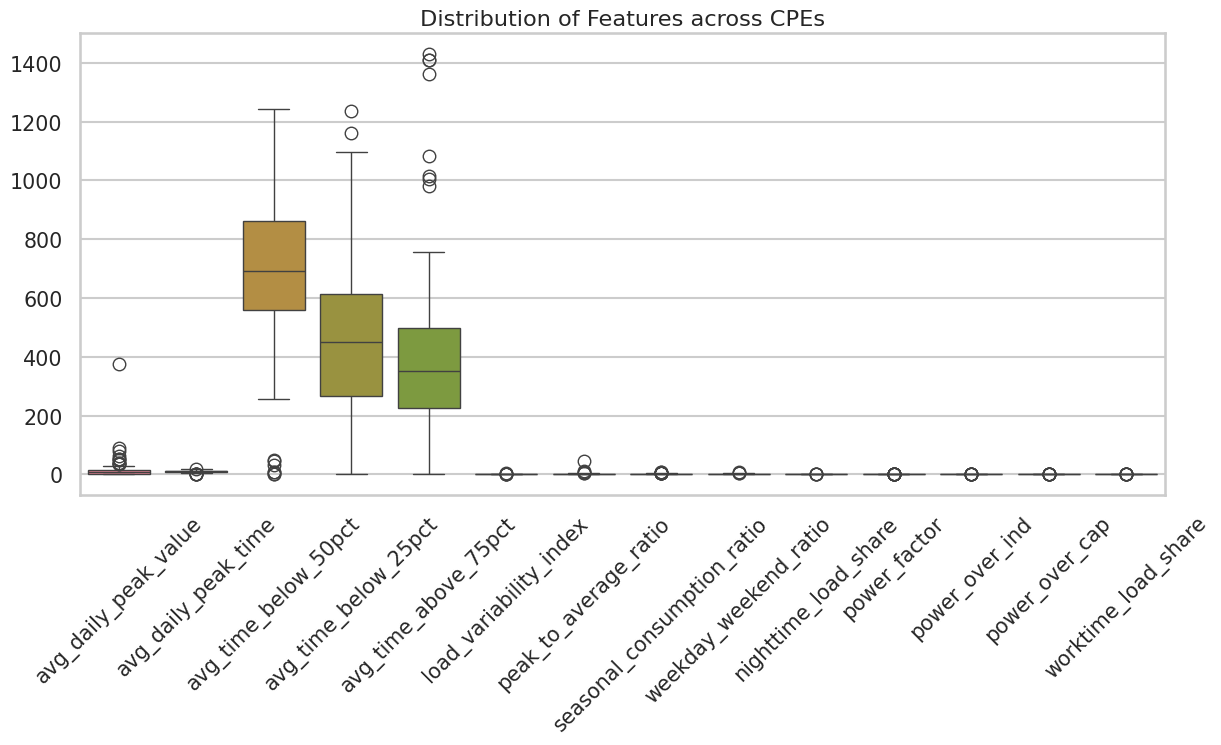

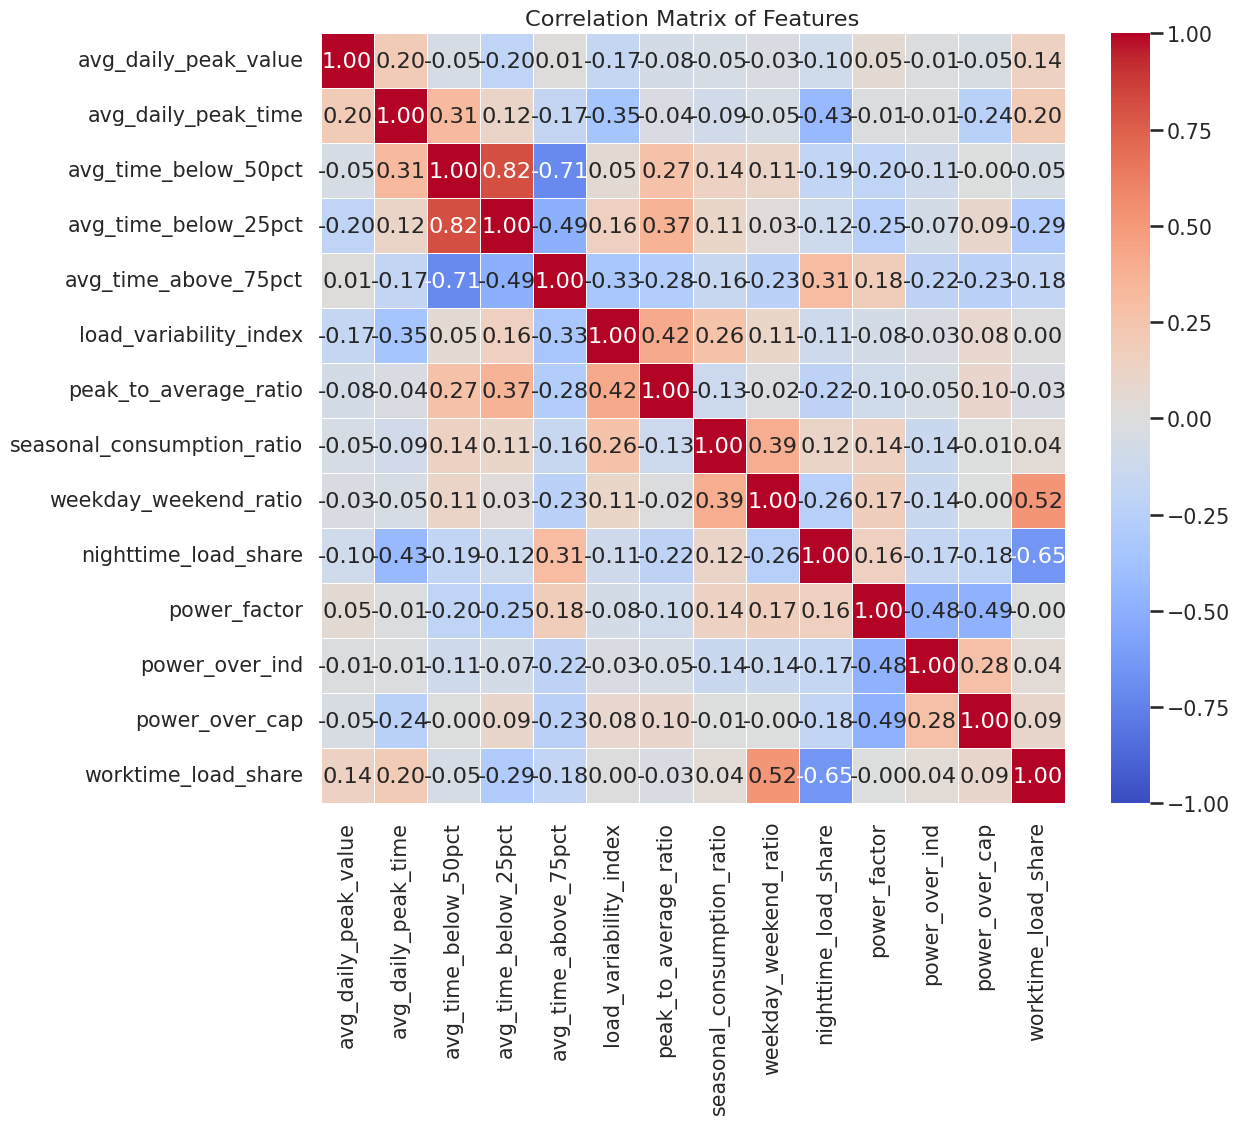

<Figure size 1500x1500 with 0 Axes>

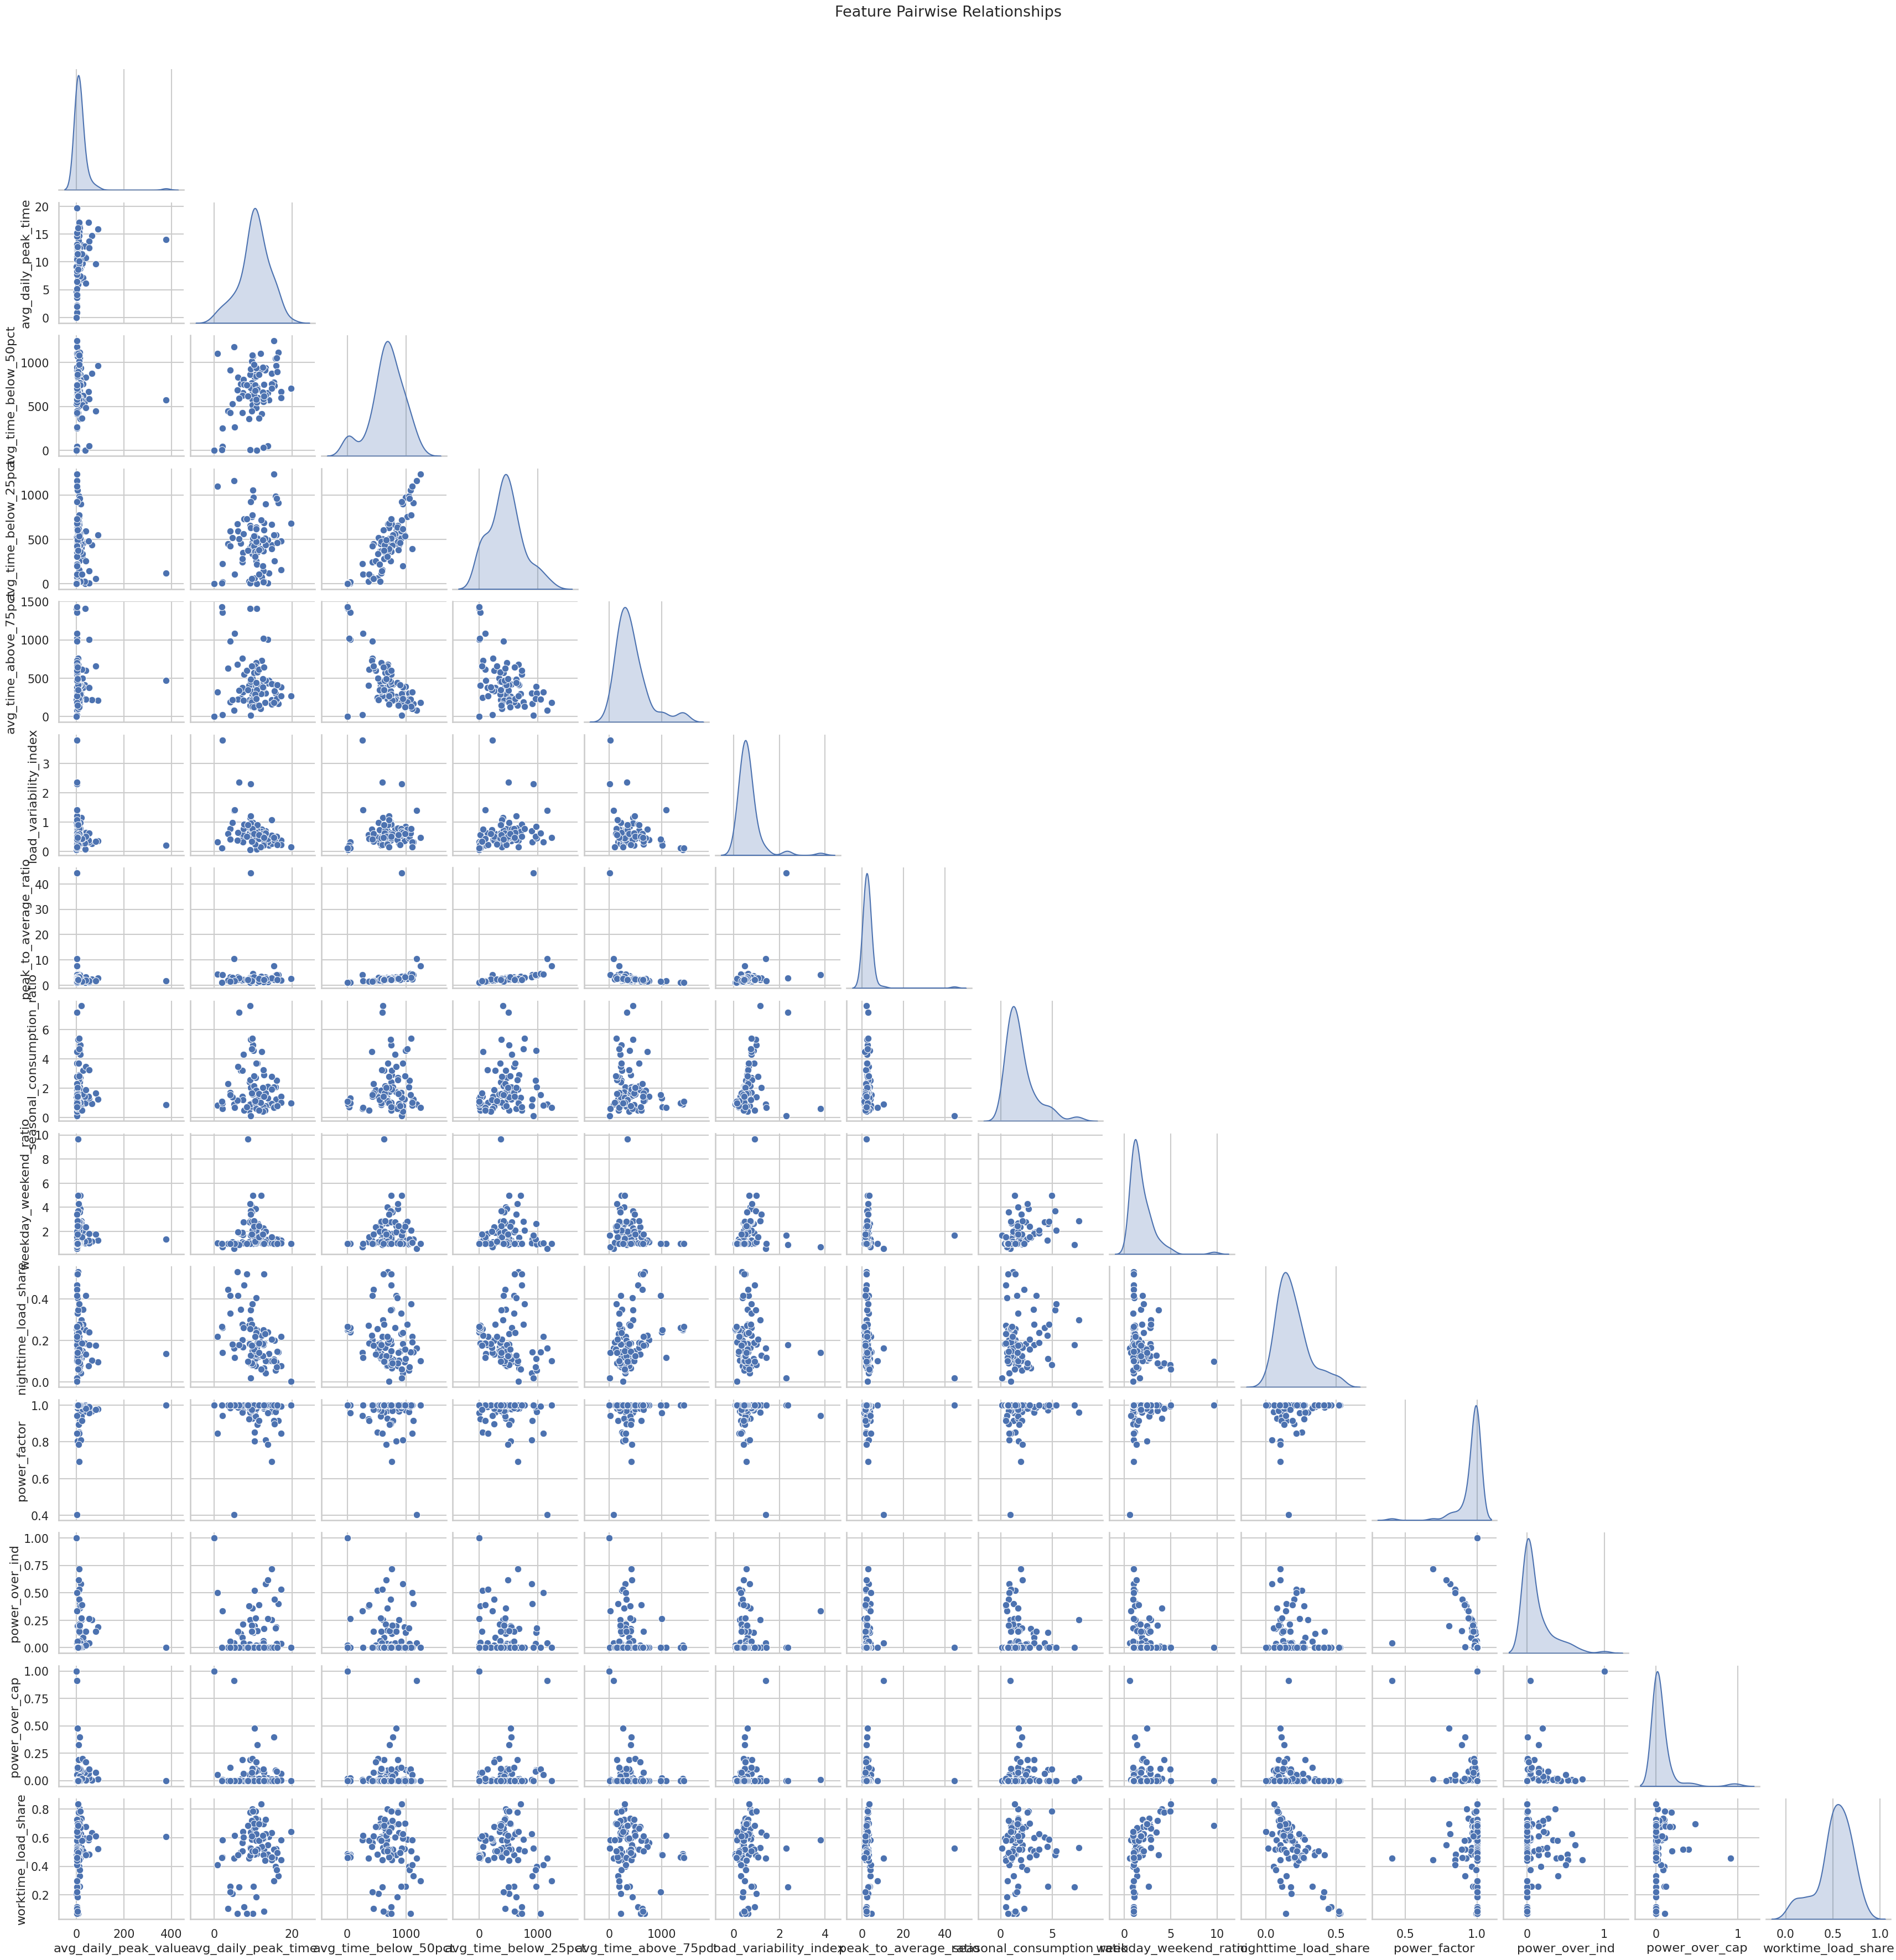

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=features_df)
plt.xticks(rotation=45)
plt.title("Distribution of Features across CPEs")
plt.show()

# Calculate the correlation matrix
corr_matrix = features_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title("Correlation Matrix of Features")
plt.show()# Pairplot to visualize relationships
plt.figure(figsize=(15, 15))
sns.pairplot(features_df, corner=True, diag_kind='kde')
plt.suptitle("Feature Pairwise Relationships", y=1.02)
plt.show()




In [ ]:
# 1. Saatleri kategorilere ayıran fonksiyon
def get_time_window(hour):
    if 0 <= hour < 6:
        return 'Night_00_06'
    elif 6 <= hour < 12:
        return 'Morning_06_12'
    elif 12 <= hour < 18:
        return 'Afternoon_12_18'
    else:
        return 'Evening_18_24'

# 2. Veri setine bu kategorileri ekleyelim
df_windows = df_clean.copy()
df_windows['TimeWindow'] = df_windows.index.hour.map(get_time_window)

# 3. Her müşteri (CPE) için bu zaman dilimlerinin ortalamasını alalım
# unstack() komutu ile satırları sütuna çeviriyoruz (pivot işlemi)
time_windows_df = df_windows.groupby(['CPE', 'TimeWindow'])['PotActiva'].mean().unstack()

# Kontrol edelim
print("Time Windows tablosu başarıyla oluşturuldu!")
print(time_windows_df.head())

/tmp/ipython-input-21480756.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_windows_df = df_windows.groupby(['CPE', 'TimeWindow'])['PotActiva'].mean().unstack()


Time Windows tablosu başarıyla oluşturuldu!
TimeWindow            Afternoon_12_18  Evening_18_24  Morning_06_12  \
CPE                                                                   
PT0002000068856655YV         2.964538       1.386926       1.821590   
PT0002000068856781NM        33.534233      30.841255      31.870941   
PT0002000068856872QG         0.149746       0.209996       0.113214   
PT0002000068856906VS         6.470755       5.709116       5.410211   
PT0002000068857099AR         2.237774       6.214691       1.863214   

TimeWindow            Night_00_06  
CPE                                
PT0002000068856655YV     0.691944  
PT0002000068856781NM    30.561277  
PT0002000068856872QG     0.088811  
PT0002000068856906VS     5.732174  
PT0002000068857099AR     1.682610  


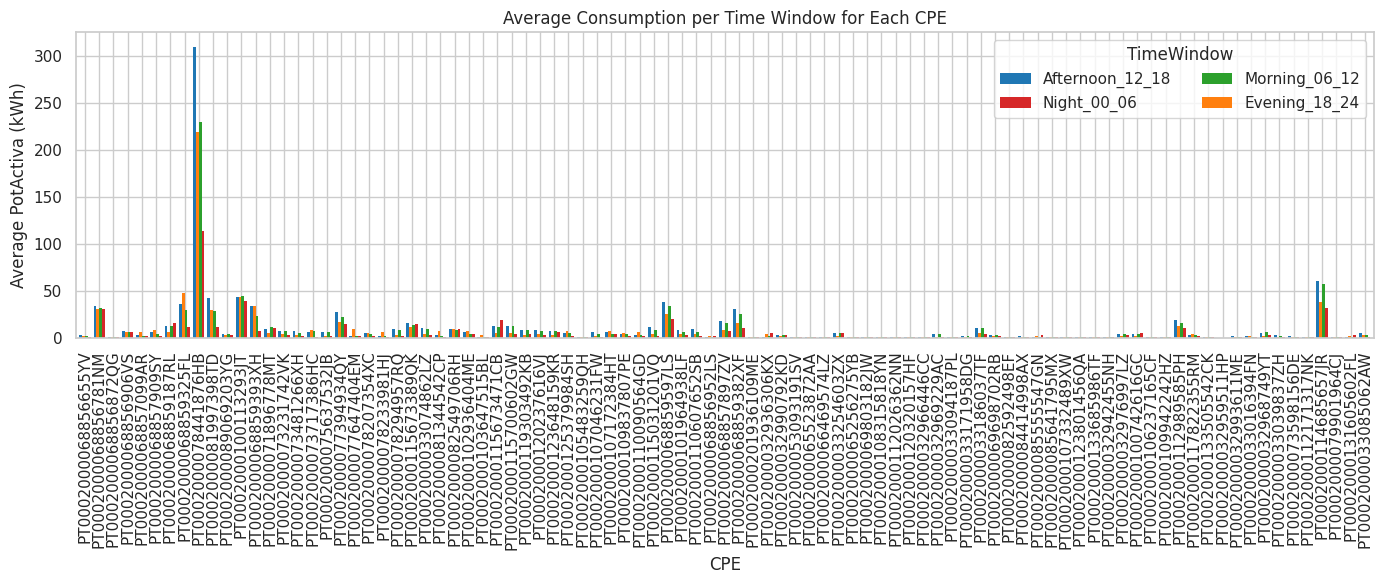

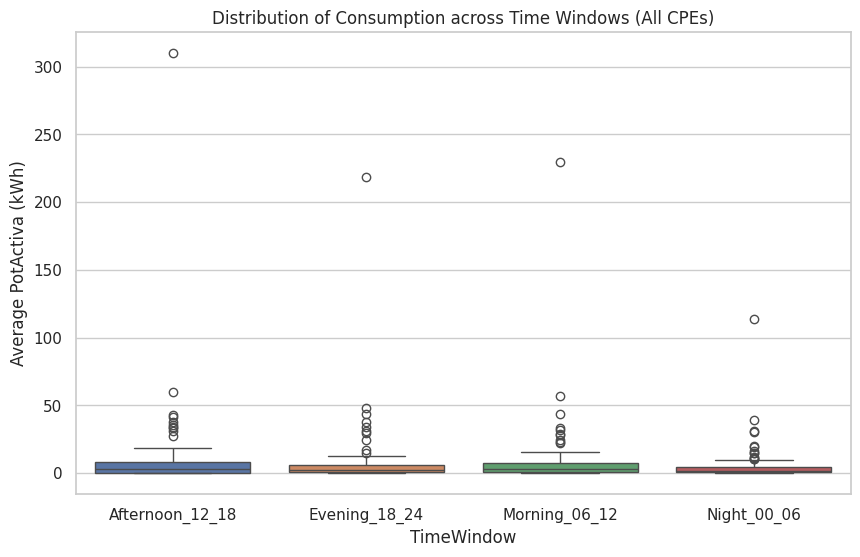

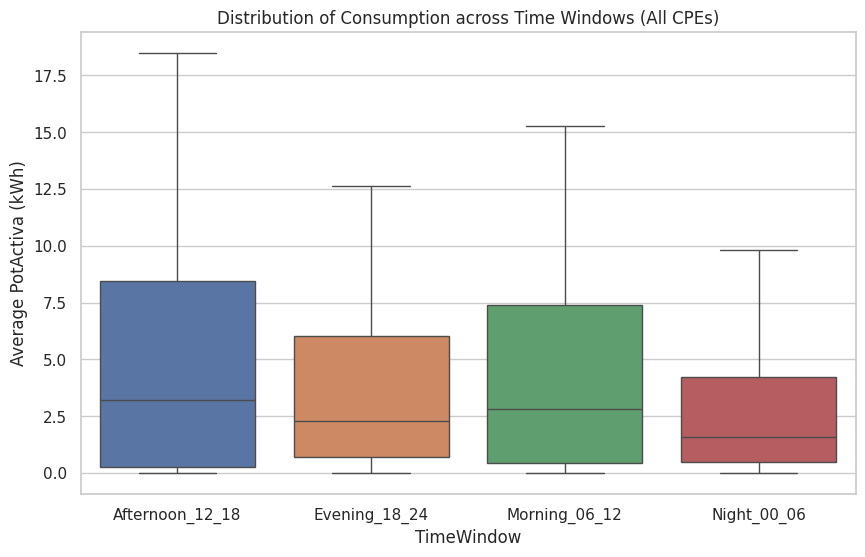

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

colors = {
    'Afternoon_12_18': '#1f77b4',  # blu
    'Night_00_06':     '#d62728',  # rosso
    'Morning_06_12':   '#2ca02c',  # verde
    'Evening_18_24':   '#ff7f0e',  # arancione
}

order = ['Afternoon_12_18', 'Night_00_06', 'Morning_06_12', 'Evening_18_24']

sns.set_theme(style='whitegrid')
bar_colors = [colors[c] for c in time_windows_df.columns]

ax = time_windows_df.plot(
    kind='bar',
    figsize=(14, 6),
    color=bar_colors,
    alpha=1.0,          # nessuna trasparenza
    edgecolor='none',   # niente contorno grigio
    width=0.8
)

# Titolo e asse Y
ax.set_title("Average Consumption per Time Window for Each CPE")
ax.set_ylabel("Average PotActiva (kWh)")
plt.xticks(rotation=90)

# Legenda ordinata come desiderato
handles, labels = ax.get_legend_handles_labels()
label_to_handle = {l: h for h, l in zip(handles, labels)}
ax.legend([label_to_handle[k] for k in order], order, title="TimeWindow", ncol=2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=time_windows_df)
plt.title("Distribution of Consumption across Time Windows (All CPEs)")
plt.ylabel("Average PotActiva (kWh)")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=time_windows_df, showfliers=False)   # hide extreme values
plt.title("Distribution of Consumption across Time Windows (All CPEs)")
plt.ylabel("Average PotActiva (kWh)")
plt.show()


# **Experiments**

1. Use unsupervised learning to define and characterize sub-groups of the data, notice if
any of these clusters has particular characteristics and detect possible outliers. If possible, characterize different consumers (e.g. day-services, night-services, ... etc), based
on the their consumption profile. Options must be adequately justified. Suggested
algorithms: K-Means and DBScan;

In [ ]:
# Remove redundant feautures
final_features = features_df.drop(columns=['peak_to_average_ratio', 'avg_time_below_50pct'])

print("Final Feature Matrix Shape:", final_features.shape)
final_features.head()


Final Feature Matrix Shape: (91, 12)


,avg_daily_peak_value,avg_daily_peak_time,avg_time_below_25pct,avg_time_above_75pct,load_variability_index,seasonal_consumption_ratio,weekday_weekend_ratio,nighttime_load_share,power_factor,power_over_ind,power_over_cap,worktime_load_share
CPE,,,,,,,,,,,,
PT0002000068856655YV,4.712766,10.317702,543.499414,262.016413,0.604894,1.721605,2.460992,0.104264,0.802579,0.197069,0.476696,0.697048
PT0002000068856781NM,35.967175,10.963658,1.723329,1409.929660,0.066607,0.983408,1.057553,0.251003,0.999256,0.019765,0.018830,0.486106
PT0002000068856872QG,1.473036,5.029308,1162.104338,82.069168,1.402464,0.921202,0.581469,0.163750,0.404241,0.043052,0.911737,0.455646
PT0002000068856906VS,10.773740,10.347011,59.454865,243.710434,0.361732,1.437643,1.153913,0.255041,0.851083,0.522755,0.003684,0.481651
PT0002000068857099AR,12.289566,16.409144,910.603751,165.439625,0.313394,1.234523,1.379750,0.145654,0.915416,0.402409,0.000130,0.333295


Normalization part

In [ ]:
# --- 1) Clean features --- (Re-using logic from original cell -3lpMzzX7P3l here for robustness)
final_features = final_features.replace([np.inf, -np.inf], np.nan)
final_features_clean = final_features.fillna(0)

print("Original number of CPEs:", final_features.shape[0])
print("After cleaning:", final_features_clean.shape[0])
print("Dropped:", final_features.shape[0] - final_features_clean.shape[0], "CPEs")
# --- Check for NaNs before outlier detection (User Request) ---
print(f"NaNs in final_features_clean before outlier detection: {final_features_clean.isnull().sum().sum()}")

Original number of CPEs: 91
After cleaning: 91
Dropped: 0 CPEs
NaNs in final_features_clean before outlier detection: 0


K-means study: choose the best K parameter

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances_argmin
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# --- 2) Outlier detection with IQR ---
def flag_outliers_iqr(df, multiplier=3.0):  # use 3.0 to reduce false positives
    outlier_mask = pd.Series(False, index=df.index)
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        outlier_mask |= (df[col] < lower) | (df[col] > upper)
    return outlier_mask

outlier_mask = flag_outliers_iqr(final_features_clean)
final_features_clean['is_outlier'] = outlier_mask.astype(int)

outliers_df = final_features_clean[final_features_clean['is_outlier'] == 1]
print("Number of outliers:", outliers_df.shape[0])
print(outliers_df.head())

# --- 3) Prepare data for clustering and Scale non-outliers ---
X = final_features_clean.loc[final_features_clean['is_outlier'] == 0].drop(columns=['is_outlier'])

# Impute any remaining NaNs in X before scaling (re-introducing this for robustness)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# --- 4) K-means study ---
sil_scores = {}
for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
    print(f"k={k}, silhouette={sil:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
print("Best k:", best_k)

# --- 5) Final K-means with best_k ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# --- 6) Assign cluster labels back to DataFrame ---
final_features_clean["cluster_kmeans"] = np.nan
final_features_clean.loc[X.index, "cluster_kmeans"] = labels_kmeans

# --- 7) Post-hoc assignment of outliers to nearest centroid ---
outliers = final_features_clean.loc[final_features_clean['is_outlier'] == 1].drop(columns=['is_outlier','cluster_kmeans'])

# Impute and scale outliers using same transformers fitted on non-outliers
outliers_imputed = imputer.transform(outliers) # Use the same imputer
outliers_scaled = scaler.transform(outliers_imputed) # Use the same scaler

# Assign to nearest centroid
outlier_labels = pairwise_distances_argmin(outliers_scaled, kmeans.cluster_centers_)
final_features_clean.loc[outliers.index, "cluster_kmeans"] = outlier_labels

# --- 8) Inspect cluster distribution ---
print(final_features_clean["cluster_kmeans"].value_counts(dropna=False))

Number of outliers: 24
                      avg_daily_peak_value  avg_daily_peak_time  \
CPE                                                               
PT0002000068856655YV              4.712766            10.317702   
PT0002000068856781NM             35.967175            10.963658   
PT0002000068856872QG              1.473036             5.029308   
PT0002000068856906VS             10.773740            10.347011   
PT0002000068859325FL             89.137108            15.878077   

                      avg_time_below_25pct  avg_time_above_75pct  \
CPE                                                                
PT0002000068856655YV            543.499414            262.016413   
PT0002000068856781NM              1.723329           1409.929660   
PT0002000068856872QG           1162.104338             82.069168   
PT0002000068856906VS             59.454865            243.710434   
PT0002000068859325FL            551.342321            208.223916   

                      load_var

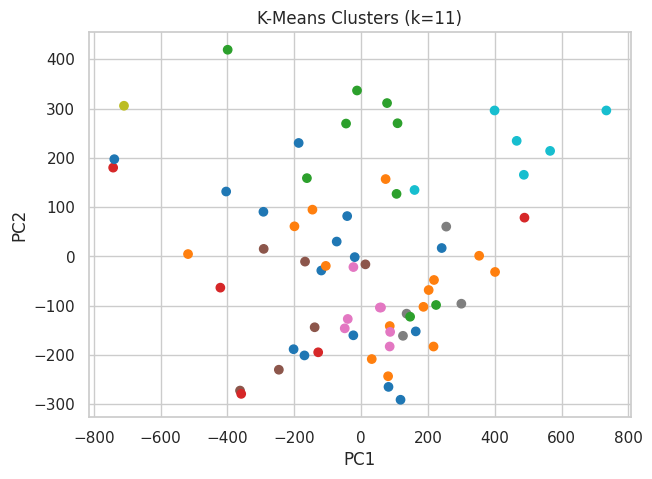

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#dimensional reduction: PC1 and PC2 are linear combination of features
pca = PCA(n_components=5)
pc = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(pc[:,0], pc[:,1], c=final_features_clean.loc[X.index, "cluster_kmeans"], cmap="tab10")
plt.title("K-Means Clusters (k=11)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Quality check

In [ ]:
from sklearn.metrics import silhouette_samples
from scipy.spatial.distance import cdist

# Non-outliers and their labels (from your pipeline)
X_non_out = final_features_clean.loc[final_features_clean['is_outlier'] == 0].drop(columns=['is_outlier','cluster_kmeans'])
labels_non_out = (final_features_clean.loc[final_features_clean['is_outlier'] == 0, 'cluster_kmeans']
                  .astype(int).values)

# Silhouette per sample (non-outliers)
sil_values = silhouette_samples(X_scaled, labels_non_out)
df_diag = pd.DataFrame({
    'cluster': labels_non_out,
    'silhouette': sil_values
}, index=X_non_out.index)

print("Mean silhouette per cluster:")
print(df_diag.groupby('cluster')['silhouette'].mean().round(3))

# Distances to assigned centroid (non-outliers)
centroids = kmeans.cluster_centers_
dists = cdist(X_scaled, centroids, metric='euclidean')              # X_scaled is non-outliers only
assigned_dist = dists[np.arange(dists.shape[0]), labels_non_out]
df_diag['distance_to_centroid'] = assigned_dist

print("\nDistance-to-centroid distribution per cluster:")
print(df_diag.groupby('cluster')['distance_to_centroid'].describe().round(3))

print("\nCluster sizes (including outliers post-assignment):")
print(final_features_clean["cluster_kmeans"].value_counts(dropna=False).sort_index())


Mean silhouette per cluster:
cluster
0    0.284
1    0.143
2    0.326
3    0.153
4    0.231
5    0.310
6    0.259
7    0.000
8    0.192
Name: silhouette, dtype: float64

Distance-to-centroid distribution per cluster:
         count   mean    std    min    25%    50%    75%    max
cluster                                                        
0         15.0  1.813  0.642  1.038  1.433  1.658  1.920  3.246
1         14.0  2.146  0.615  1.087  1.698  2.142  2.504  3.198
2          9.0  2.033  0.648  1.317  1.576  1.701  2.392  3.055
3          5.0  2.477  1.101  1.282  1.803  2.041  3.383  3.875
4          6.0  2.058  0.559  1.272  1.843  1.919  2.487  2.746
5          7.0  1.649  0.682  0.924  1.094  1.466  2.119  2.731
6          4.0  1.770  0.671  0.871  1.597  1.857  2.029  2.495
7          1.0  0.000    NaN  0.000  0.000  0.000  0.000  0.000
8          6.0  2.111  0.581  1.227  1.805  2.154  2.506  2.820

Cluster sizes (including outliers post-assignment):
cluster_kmeans
0.0    16
1

microclusters and high standard deviations, are present, as well as negative silhouettes. We need to split/mix some clusters

Step 1:
If sep_to_compact_ratio < 2, the cluster is not well separated relative to its spread.
If size < 5, it’s too small for reliable characterization.
Use the nearest centroid as a merge candidate.

In [ ]:

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# We already have:
# - X_scaled (non-outliers only)
# - labels_non_out (non-outlier labels as int)
# - kmeans.cluster_centers_ -> centroids
# - df_diag with per-sample silhouette and distance_to_centroid (assigned_dist)

cluster_ids = np.sort(np.unique(labels_non_out))
summary = []
for c in cluster_ids:
    idx = np.where(labels_non_out == c)[0]
    size = len(idx)
    sil_mean = df_diag.loc[X_non_out.index[idx], 'silhouette'].mean()
    dist_assign = df_diag.loc[X_non_out.index[idx], 'distance_to_centroid'].values
    compact_mean = dist_assign.mean()
    compact_p90 = np.percentile(dist_assign, 90)
    summary.append([c, size, sil_mean, compact_mean, compact_p90])

summary_df = pd.DataFrame(summary, columns=['cluster','size','silhouette_mean','compact_mean','compact_p90']).set_index('cluster')

# Centroid separations (in standardized space)
centroids = kmeans.cluster_centers_
centroid_dists = cdist(centroids, centroids)
np.fill_diagonal(centroid_dists, np.inf)
sep_min = pd.Series(centroid_dists.min(axis=1), index=summary_df.index, name='separation_min')
summary_df = summary_df.join(sep_min)

# Separation vs compactness ratio
summary_df['sep_to_compact_ratio'] = summary_df['separation_min'] / summary_df['compact_mean']
print(summary_df.round(3))

# Flag problem clusters: low silhouette OR small OR poor separation
problem_mask = (
    (summary_df['silhouette_mean'] < 0.05) |
    (summary_df['sep_to_compact_ratio'] < 2.0) |
    (summary_df['size'] < 5)
)
print("Problematic clusters:", summary_df.index[problem_mask].tolist())

# For each problematic cluster, suggest the nearest neighbor centroid as a merge target
nearest_targets = {}
for c in summary_df.index:
    drow = centroid_dists[c]
    nearest = np.argmin(drow)
    nearest_targets[c] = nearest
print("Nearest centroid targets:", nearest_targets)


         size  silhouette_mean  compact_mean  compact_p90  separation_min  \
cluster                                                                     
0          15            0.284         1.813        2.805           2.956   
1          14            0.143         2.146        2.943           2.956   
2           9            0.326         2.033        3.000           3.776   
3           5            0.153         2.477        3.678           3.790   
4           6            0.231         2.058        2.709           3.352   
5           7            0.310         1.649        2.380           3.269   
6           4            0.259         1.770        2.309           3.344   
7           1            0.000         0.000        0.000           5.592   
8           6            0.192         2.111        2.706           3.518   

         sep_to_compact_ratio  
cluster                        
0                       1.630  
1                       1.377  
2                       

It is not enough!
Then:
Step 2:
Given the weakness in clusters 1 and 10 and the micro-clusters, I’d re-run KMeans focusing on k in [3…8] and pick by multiple indices (i.e. not only silhouette). Pick the k with:

High silhouette, low Davies-Bouldin, high Calinski-Harabasz, and a clear elbow in inertia.

In [ ]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

min_size = 3
candidates = []
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)  # aumenta n_init per stabilità
    lbls = km.fit_predict(X_scaled)
    sizes = pd.Series(lbls).value_counts()
    sil = silhouette_score(X_scaled, lbls)
    db = davies_bouldin_score(X_scaled, lbls)
    ch = calinski_harabasz_score(X_scaled, lbls)
    ok = (sizes.min() >= min_size)
    candidates.append((k, sil, db, ch, ok, sizes.sort_index().to_dict()))

df_cand = pd.DataFrame(candidates, columns=[
    'k','silhouette','davies_bouldin','calinski_harabasz','meets_min_size','sizes'
])
print(df_cand.round(3).to_string(index=False))

# Seleziona il miglior k che rispetta la dimensione minima
df_ok = df_cand[df_cand['meets_min_size']].sort_values('silhouette', ascending=False)
if not df_ok.empty:
    best_k_constrained = int(df_ok.iloc[0]['k'])
    print(f"\nScelgo k vincolato: {best_k_constrained}, sizes: {df_ok.iloc[0]['sizes']}")
else:
    print("\nNessun k tra 3..8 rispetta min_size: valuta k più piccolo o passa allo Step 2 (merge post-hoc).")


 k  silhouette  davies_bouldin  calinski_harabasz  meets_min_size                                              sizes
 3       0.186           1.675             13.395            True                               {0: 7, 1: 20, 2: 40}
 4       0.177           1.621             13.471            True                        {0: 23, 1: 25, 2: 11, 3: 8}
 5       0.215           1.441             13.524            True                 {0: 11, 1: 15, 2: 24, 3: 10, 4: 7}
 6       0.222           1.332             13.262            True            {0: 16, 1: 6, 2: 9, 3: 10, 4: 19, 5: 7}
 7       0.226           1.317             13.107            True      {0: 6, 1: 16, 2: 16, 3: 7, 4: 6, 5: 11, 6: 5}
 8       0.216           1.303             13.021            True {0: 8, 1: 7, 2: 7, 3: 10, 4: 6, 5: 9, 6: 6, 7: 14}

Scelgo k vincolato: 7, sizes: {0: 6, 1: 16, 2: 16, 3: 7, 4: 6, 5: 11, 6: 5}


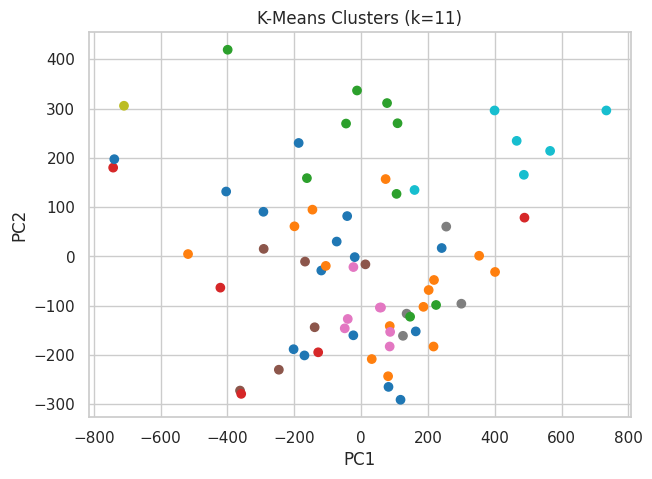

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#dimensional reduction: PC1 and PC2 are linear combination of features
pca = PCA(n_components=5)
pc = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(pc[:,0], pc[:,1], c=final_features_clean.loc[X.index, "cluster_kmeans"], cmap="tab10")
plt.title("K-Means Clusters (k=11)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#Interpretation of formed clusters

Profile the Centroids:
High positive z-score → feature significantly above average.
High negative z-score → feature significantly below average.

In [ ]:

# Centroids in original units
centroids_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_profiles_raw = pd.DataFrame(centroids_unscaled, columns=X.columns).rename_axis('cluster')

# Global mean and std
global_mean = X.mean()
global_std = X.std(ddof=0)

# Z-score profiles
cluster_profiles_z = (cluster_profiles_raw - global_mean) / global_std
print(cluster_profiles_z.round(2))


         avg_daily_peak_value  avg_daily_peak_time  avg_time_below_25pct  \
cluster                                                                    
0                       -0.57                 0.52                 -0.42   
1                       -0.07                -0.29                  0.07   
2                       -0.74                -1.17                  0.46   
3                        0.90                 0.78                 -0.85   
4                        2.11                 0.31                 -0.87   
5                        0.16                -0.27                 -0.21   
6                        0.06                -0.07                  0.44   
7                       -0.87                -1.70                 -1.45   
8                       -0.21                 0.82                  1.98   

         avg_time_above_75pct  load_variability_index  \
cluster                                                 
0                        0.18                   -

Identify Key Features per Cluster

In [ ]:

for c in cluster_profiles_z.index:
    z_abs = cluster_profiles_z.loc[c].abs().sort_values(ascending=False).head(5)
    print(f"Cluster {c} - top features:\n{z_abs.round(2)}\n")


Cluster 0 - top features:
load_variability_index        0.68
power_over_cap                0.62
seasonal_consumption_ratio    0.61
avg_daily_peak_value          0.57
power_factor                  0.57
Name: 0, dtype: float64

Cluster 1 - top features:
seasonal_consumption_ratio    1.27
load_variability_index        0.83
power_factor                  0.49
power_over_cap                0.47
weekday_weekend_ratio         0.46
Name: 1, dtype: float64

Cluster 2 - top features:
worktime_load_share      1.87
nighttime_load_share     1.81
avg_daily_peak_time      1.17
weekday_weekend_ratio    0.87
avg_daily_peak_value     0.74
Name: 2, dtype: float64

Cluster 3 - top features:
power_factor                  2.69
power_over_ind                2.65
avg_daily_peak_value          0.90
seasonal_consumption_ratio    0.87
avg_time_below_25pct          0.85
Name: 3, dtype: float64

Cluster 4 - top features:
avg_daily_peak_value      2.11
power_over_cap            1.79
avg_time_below_25pct      0.87
lo

In [ ]:

import pandas as pd

# cluster_profiles_z: DataFrame indexed by cluster, columns = feature names (z-scores of centroids)
top_features_per_cluster = {}
for c in cluster_profiles_z.index:
    z_abs = cluster_profiles_z.loc[c].abs().sort_values(ascending=False)
    top_features_per_cluster[c] = z_abs.head(5).index.tolist()

# Quick check
for c, feats in top_features_per_cluster.items():
    print(f"Cluster {c}: top features -> {feats}")


Cluster 0: top features -> ['load_variability_index', 'power_over_cap', 'seasonal_consumption_ratio', 'avg_daily_peak_value', 'power_factor']
Cluster 1: top features -> ['seasonal_consumption_ratio', 'load_variability_index', 'power_factor', 'power_over_cap', 'weekday_weekend_ratio']
Cluster 2: top features -> ['worktime_load_share', 'nighttime_load_share', 'avg_daily_peak_time', 'weekday_weekend_ratio', 'avg_daily_peak_value']
Cluster 3: top features -> ['power_factor', 'power_over_ind', 'avg_daily_peak_value', 'seasonal_consumption_ratio', 'avg_time_below_25pct']
Cluster 4: top features -> ['avg_daily_peak_value', 'power_over_cap', 'avg_time_below_25pct', 'load_variability_index', 'worktime_load_share']
Cluster 5: top features -> ['power_over_ind', 'worktime_load_share', 'power_factor', 'weekday_weekend_ratio', 'nighttime_load_share']
Cluster 6: top features -> ['weekday_weekend_ratio', 'worktime_load_share', 'power_over_cap', 'nighttime_load_share', 'load_variability_index']
Cluster

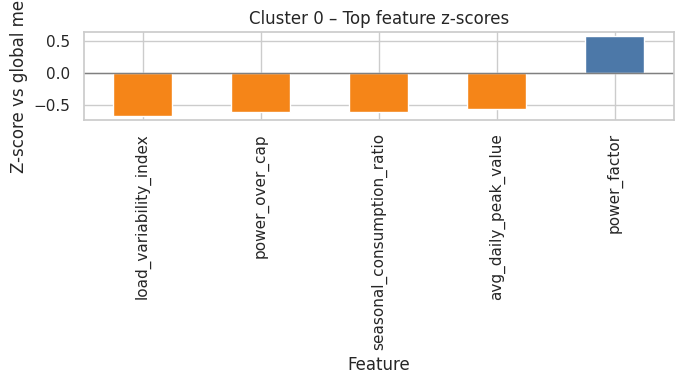

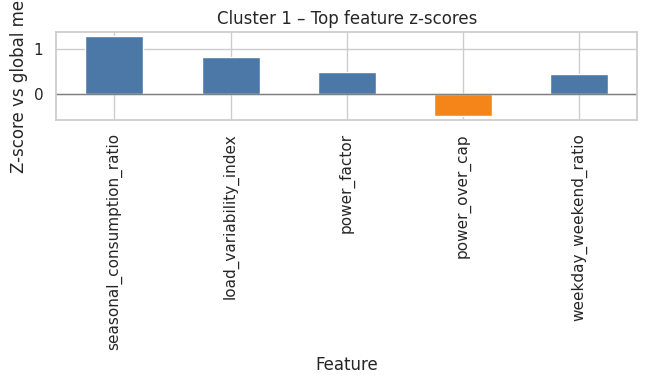

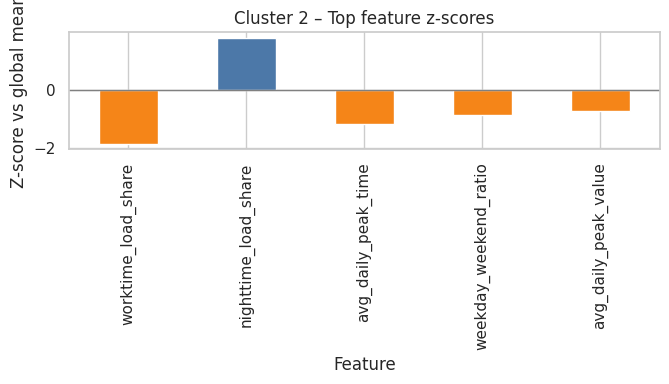

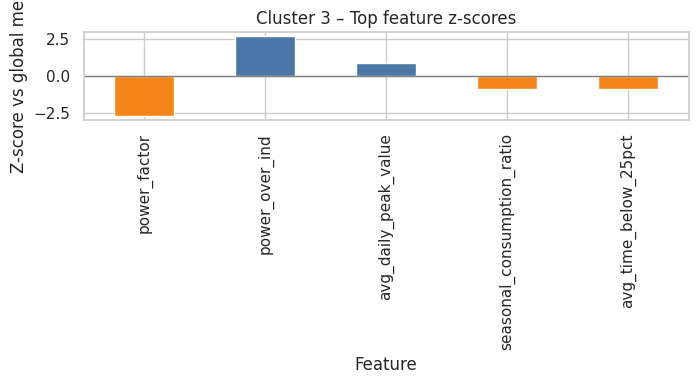

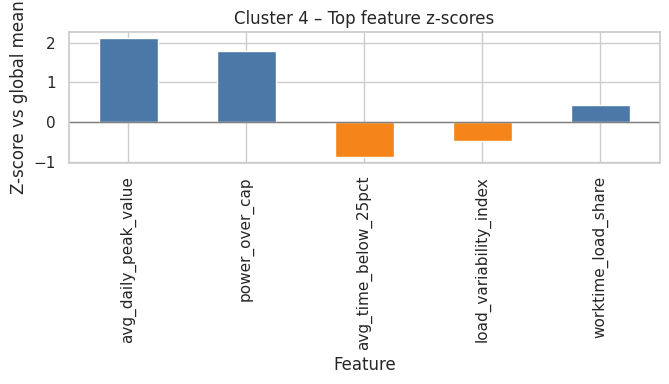

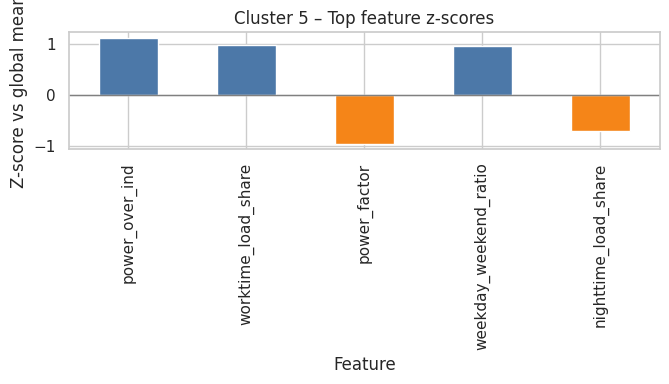

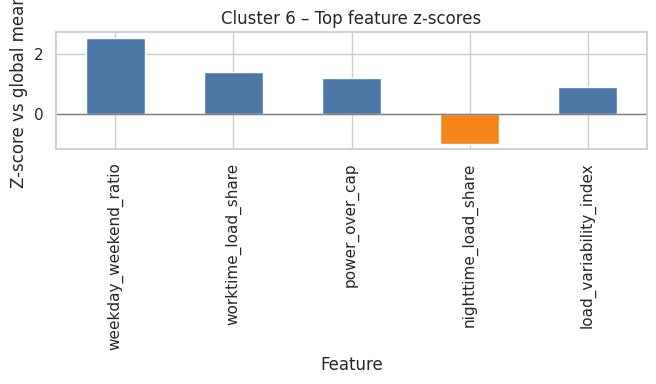

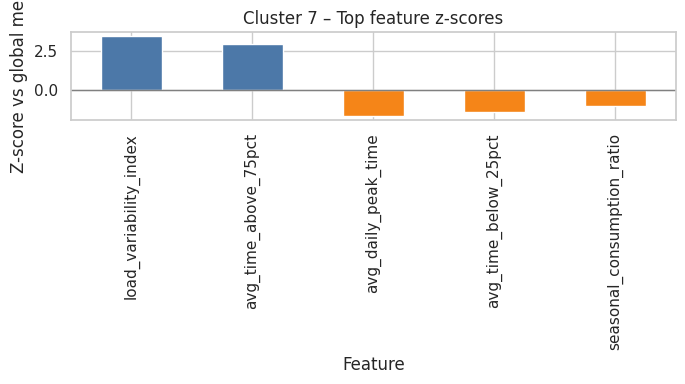

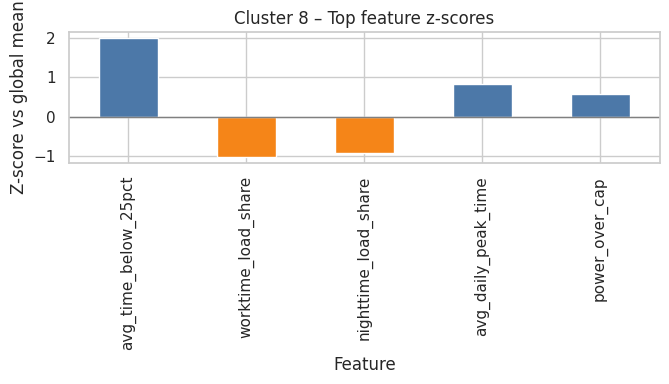

In [ ]:

import matplotlib.pyplot as plt

for c, feats in top_features_per_cluster.items():
    zvals = cluster_profiles_z.loc[c, feats]
    plt.figure(figsize=(7,4))
    zvals.sort_values(key=lambda s: s.abs(), ascending=False).plot(kind='bar', color=[
        '#4C78A8' if v>=0 else '#F58518' for v in zvals.values
    ])
    plt.axhline(0, color='gray', linewidth=1)
    plt.title(f'Cluster {c} – Top feature z-scores')
    plt.ylabel('Z-score vs global mean')
    plt.xlabel('Feature')
    plt.tight_layout()
    plt.show()


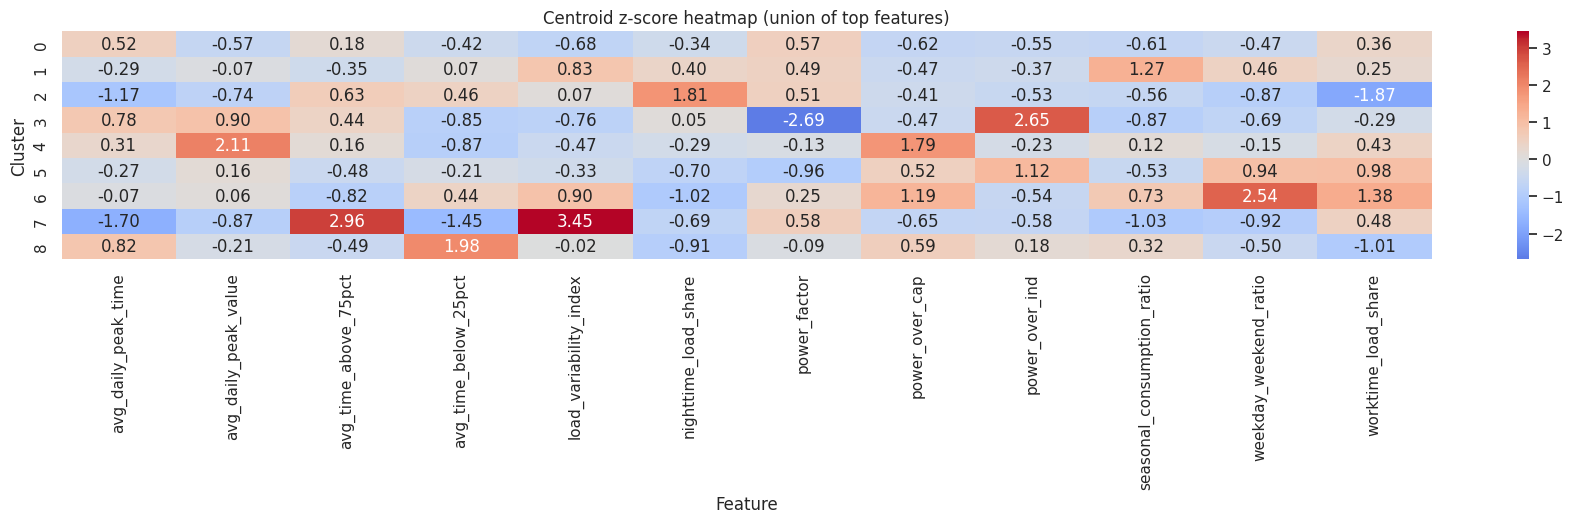

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Union of all top features
top_union = sorted(set(f for feats in top_features_per_cluster.values() for f in feats))

plt.figure(figsize=(1.5*len(top_union), 0.6*len(cluster_profiles_z)))
sns.heatmap(cluster_profiles_z[top_union].round(2),
            cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Centroid z-score heatmap (union of top features)')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


Testing the z-score we can observe the high efficient of the Cluster 7, where the values tend to take the extreme values (high or low). The most important factors are the Load variability index, the Average time above 75% but also the negative one of the average dailty peak time. Cluster 3 & 5 also show strong overload/capacity signals (power_over_cap, power_over_ind). Cluster 4 & 6 lean toward daytime/worktime usage. Cluster 8 shows strong negative values in worktime and high load metrics.

This tells us clusters are not random — they capture load intensity, time-of-day behavior, efficiency, and weekly/seasonal trends.

##DBSCAN

In [ ]:
final_features = final_features.replace([np.inf, -np.inf], np.nan)
final_features_clean = final_features.fillna(0)

print("Original number of CPEs:", final_features.shape[0])
print("After cleaning:", final_features_clean.shape[0])
print("Dropped:", final_features.shape[0] - final_features_clean.shape[0], "CPEs")

Original number of CPEs: 91
After cleaning: 91
Dropped: 0 CPEs


##Finding the best epsilon value

I implemented a sweep over a range of eps values for DBSCAN, running clustering for each eps and computing internal validation metrics (Silhouette, Calinski–Harabasz, and Davies–Bouldin) only on non-noise points. I tracked the number of clusters and the noise ratio, then combined the metrics into a weighted composite score with a penalty when noise exceeded a chosen threshold. The script selected the best eps by maximizing this composite score (subject to constraints like having at least two real clusters) and visualized how metrics, noise, and the score change with eps. Finally, it refit DBSCAN with the best eps and added the resulting labels back to your dataframe.

In [ ]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

K_TARGET = 6        # minimo numero di cluster desiderati
min_samples_grid = [3, 5, 7, 10]  # griglia per robustezza cluster

X_df = final_features_clean.drop(columns=["cluster_dbscan"], errors="ignore")
X = X_df.values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

k = 3
nbrs = NearestNeighbors(n_neighbors=k).fit(Xs)
dists, _ = nbrs.kneighbors(Xs)
kdist = np.sort(dists[:, k-1])
second_deriv = np.gradient(np.gradient(kdist))
eps_knee = float(kdist[int(np.nanargmax(second_deriv))])

# Range EPS: molto ampio (sotto e sopra il knee)
eps_values = np.concatenate([
    np.linspace(max(1e-6, 0.02*eps_knee), 0.5*eps_knee, 120),
    np.linspace(0.5*eps_knee, 2.0*eps_knee, 180)
])
eps_values = np.unique(np.round(eps_values, 6))

def n_clusters_no_noise(labels):
    core = labels[labels != -1]
    return len(set(core)) if core.size > 0 else 0

rows = []
best = None

for MIN_SAMPLES in min_samples_grid:
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric="euclidean").fit_predict(Xs)
        ncl = n_clusters_no_noise(labels)
        noise = (labels == -1).mean()
        score = ncl  # semplice: più cluster = meglio

        rows.append((MIN_SAMPLES, eps, ncl, noise, score, labels))

        if best is None or ncl > best[2]:
            best = (MIN_SAMPLES, eps, ncl, noise, score, labels)

ms_star, eps_star, ncl_star, noise_star, score_star, labels_best = best


print("---- Ricerca DBSCAN (euclidea, senza PCA, rumore ignorato) ----")
print(f"Knee eps (3-NN): {eps_knee:.4f}")
print(f"Sweep eps: [{eps_values.min():.4f}, {eps_values.max():.4f}] con {len(eps_values)} passi")
print(f"Grid min_samples: {min_samples_grid}")
print(f"Scelto: min_samples={ms_star}, eps={eps_star:.4f} -> #cluster={ncl_star}, rumore={noise_star:.1%}")

# Distribuzione etichette
unique, counts = np.unique(labels_best, return_counts=True)
vc = dict(zip(unique, counts))
print("Distribuzione etichette:", vc)
print("Numero cluster (no rumore):", len([u for u in unique if u != -1]))
print("Rumore (%):", (labels_best == -1).mean()*100)

# Applica i cluster al DataFrame
final_features_clean["cluster_dbscan"] = labels_best

# Tabella riassuntiva: top per numero di cluster
df_try = pd.DataFrame(rows, columns=["min_samples","eps","n_clusters","noise_ratio","score","labels"])
top_clusters = df_try.sort_values("n_clusters", ascending=False).head(12)[["min_samples","eps","n_clusters","noise_ratio"]]
print("\nTop configurazioni per numero di cluster:")
print(top_clusters.to_string(index=False))


---- Ricerca DBSCAN (euclidea, senza PCA, rumore ignorato) ----
Knee eps (3-NN): 4.9190
Sweep eps: [0.0984, 9.8380] con 299 passi
Grid min_samples: [3, 5, 7, 10]
Scelto: min_samples=3, eps=1.6063 -> #cluster=5, rumore=41.8%
Distribuzione etichette: {np.int64(-1): np.int64(38), np.int64(0): np.int64(3), np.int64(1): np.int64(37), np.int64(2): np.int64(3), np.int64(3): np.int64(7), np.int64(4): np.int64(3)}
Numero cluster (no rumore): 5
Rumore (%): 41.75824175824176

Top configurazioni per numero di cluster:
 min_samples      eps  n_clusters  noise_ratio
           3 1.606322           5     0.417582
           3 1.626163           5     0.417582
           3 1.646004           5     0.384615
           3 2.102355           4     0.153846
           3 1.586480           4     0.450549
           3 1.665846           4     0.384615
           3 1.685687           4     0.384615
           3 1.705528           4     0.384615
           3 1.110288           4     0.780220
           5 2.003

/tmp/ipython-input-168556557.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


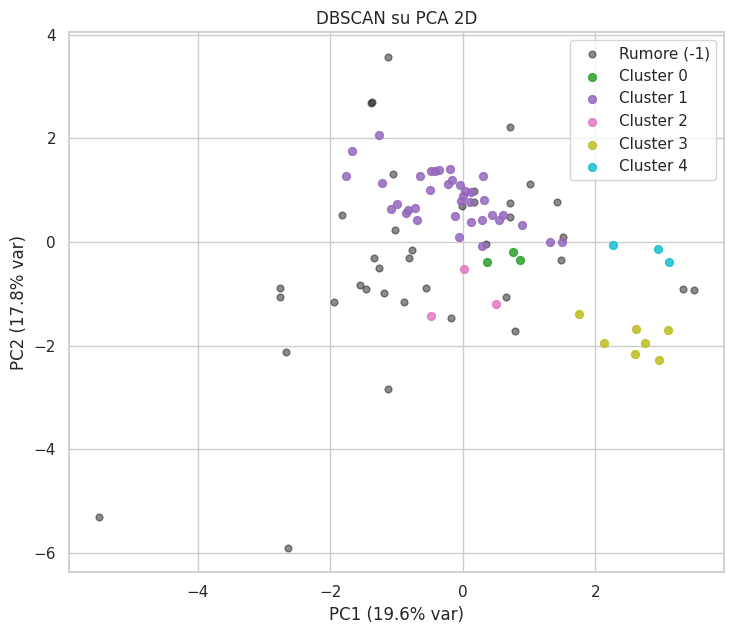

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Prepara dati (solo feature numeriche)
X_df = final_features_clean.drop(columns=["cluster_dbscan"], errors="ignore")
X = X_df.values

# 2) Scaling
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# 3) PCA per plotting 2D
pca2 = PCA(n_components=2, random_state=42)
Z2 = pca2.fit_transform(Xs)

# 4) Recupera etichette cluster
labels = final_features_clean["cluster_dbscan"].values
unique_labels = np.unique(labels)

# 5) Plot 2D dei cluster
plt.figure(figsize=(7.5, 6.5))
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

for i, lab in enumerate(unique_labels):
    mask = labels == lab
    if lab == -1:
        plt.scatter(Z2[mask, 0], Z2[mask, 1], c='k', s=24, alpha=0.5, label='Rumore (-1)')
    else:
        plt.scatter(Z2[mask, 0], Z2[mask, 1], s=32, alpha=0.85, label=f'Cluster {lab}', color=cmap(i))

plt.title('DBSCAN su PCA 2D')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Identify Key Features per Cluster

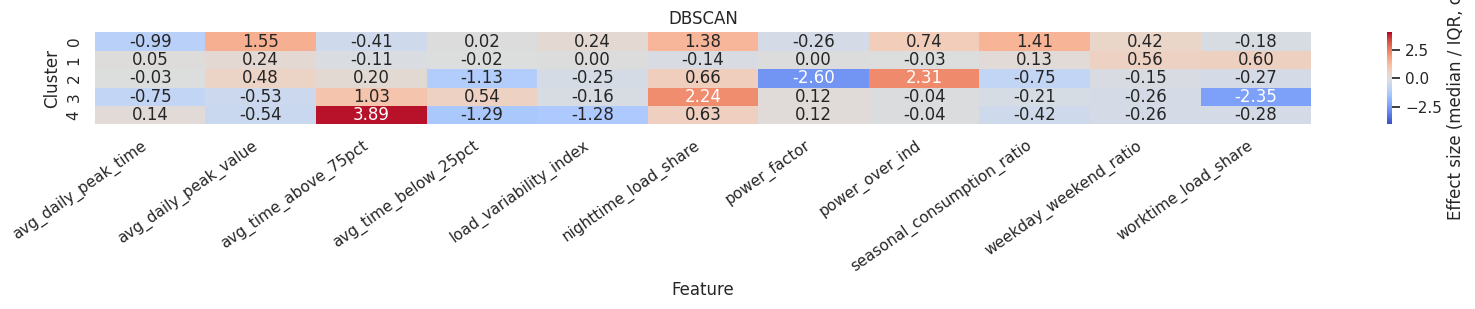

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================
EXCLUDE_NOISE   = True   # escludi solo il rumore (-1) dalla heatmap
WINSORIZE       = True   # attenua outlier con clipping ai quantili globali
P_LOW, P_HIGH   = 0.02, 0.98
TOP_K           = 5
EPS_IQR         = 1e-3   # pavimento per IQR
VMAX_IQR        = 4.0    # limiti colore heatmap [-VMAX_IQR, +VMAX_IQR]

# =========================
# Dati
# =========================
df = final_features_clean.copy()
labels = df["cluster_dbscan"].values
X_df   = df.drop(columns=["cluster_dbscan"], errors="ignore")

# (opz.) winsorization lieve per attenuare code
def winsorize_series(s, p_low=P_LOW, p_high=P_HIGH):
    lo, hi = s.quantile(p_low), s.quantile(p_high)
    return s.clip(lower=lo, upper=hi)

Xw = X_df.apply(winsorize_series) if WINSORIZE else X_df.copy()

# Maschera (escludi solo il rumore, NON i cluster)
mask = (labels != -1) if EXCLUDE_NOISE else np.ones_like(labels, dtype=bool)
X_in = Xw.loc[mask]
lb_in = labels[mask]

# Statistiche globali robuste (su Xw)
g_med = Xw.median()
q25   = Xw.quantile(0.25)
q75   = Xw.quantile(0.75)
iqr   = (q75 - q25).replace(0, np.nan)

# Profili per cluster (mediana)
cluster_median = X_in.groupby(lb_in).median()

# Effetto normalizzato per IQR con pavimento
den = iqr.fillna(0.0).clip(lower=EPS_IQR)
effect_iqr = (cluster_median - g_med) / den

# Top feature per cluster (per modulo dell’effetto)
top_feats_iqr = {
    c: effect_iqr.loc[c].abs().sort_values(ascending=False).head(TOP_K).index.tolist()
    for c in effect_iqr.index
}
top_union_iqr = sorted({f for lst in top_feats_iqr.values() for f in lst})

# Heatmap
if top_union_iqr:
    plt.figure(figsize=(1.5*len(top_union_iqr), 0.65*len(effect_iqr)))
    sns.heatmap(effect_iqr[top_union_iqr].clip(-VMAX_IQR, VMAX_IQR).round(2),
                cmap="coolwarm", center=0, vmin=-VMAX_IQR, vmax=VMAX_IQR,
                annot=True, fmt=".2f",
                cbar_kws={'label': 'Effect size (median / IQR, clipped)'})
    plt.title('DBSCAN')
    plt.xlabel('Feature'); plt.ylabel('Cluster')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout(); plt.show()
else:
    print("Nessuna top feature per la heatmap IQR.")


DBSCAN outlier characterization

**# Experiment 2**

#Why to pass on a hourly base instead of 15' based?

XGBoost comparison

In [ ]:

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "XGBoost is not installed in this environment. "
        "Install it (e.g., pip install xgboost) or switch to RandomForest."
    ) from e

# Metrics
def rmse(y_true, y_pred):
    """Root Mean Squared Error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    """Mean Absolute Error."""
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred, eps=1e-8):
    """Mean Absolute Percentage Error (in %)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

def nrmse(y_true, y_pred):
    """
    Normalized RMSE = RMSE / std(y_true) on the evaluation window.
    Using std as the scale makes errors comparable across granularities.
    """
    return rmse(y_true, y_pred) / (np.std(y_true) + 1e-8)

# Week-safe features for 15-minute data (lags >= one week)
def make_features_15m(s_df, target_col="PotActiva"):
    """
    Build leakage-free features on 15-minute data.
    'Week-safe' means any statistic for t uses data <= t-1week.
    We enforce this by shifting the target before rolling aggregations.
    """
    d = s_df.copy()
    # Time encodings (no leakage)
    d["hour"]      = d.index.hour
    d["dayofweek"] = d.index.dayofweek
    d["month"]     = d.index.month
    # One week at 15' = 672 steps
    d["lag_672"]   = d[target_col].shift(672)
    d["lag_1344"]  = d[target_col].shift(1344)
    # Week-safe rolling: shift -> then roll
    d["roll_mean_672"] = d[target_col].shift(672).rolling(672).mean()
    d["roll_std_672"]  = d[target_col].shift(672).rolling(672).std()
    # Optional daily seasonality encodings
    d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
    d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)
    return d.dropna()

# Week-safe features for hourly data (lags >= one week)
def make_features_1h(s_df, target_col="PotActiva"):
    """Leakage-free features on hourly data (168-step weekly lag)."""
    d = s_df.copy()
    d["hour"]      = d.index.hour
    d["dayofweek"] = d.index.dayofweek
    d["month"]     = d.index.month
    # One week at hourly freq = 168
    d["lag_168"]   = d[target_col].shift(168)
    d["lag_336"]   = d[target_col].shift(336)
    d["roll_mean_168"] = d[target_col].shift(168).rolling(168).mean()
    d["roll_std_168"]  = d[target_col].shift(168).rolling(168).std()
    d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
    d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)
    return d.dropna()

# Weekly baseline (same hour one week earlier)
def weekly_baseline(series, weekly_shift):
    """Weekly naive baseline: y_hat(t) = y(t - weekly_shift)."""
    return series.shift(weekly_shift)

# Chronological split 70/30 (no shuffling)
def time_split(df, target_col="PotActiva", train_ratio=0.7):
    """
    Chronological split: first 70% -> train, last 30% -> test.
    Returns (X_train, y_train, X_test, y_test).
    """
    split_idx = int(len(df) * train_ratio)
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]
    X_train = train.drop(columns=[target_col])
    y_train = train[target_col]
    X_test  = test.drop(columns=[target_col])
    y_test  = test[target_col]
    return X_train, y_train, X_test, y_test

# Main comparison: XGBoost on 15' vs 1h using same 1-week window
def compare_15min_vs_hourly_xgb(df_clean, target_cpe, target_col="PotActiva",
                                plot_path="comparison_15m_vs_1h_xgb.png",
                                xgb_params=None):
    """
    Trains an XGBoost regressor on 'week-safe' features for both granularities (15' and 1h)
    using a 70/30 chronological split. Evaluates on the same 1-week window inside test.
    Plots actual vs baseline vs model for each granularity and a bar chart of NRMSE.
    """
    # 1) Extract one CPE
    df_cpe = df_clean[df_clean["CPE"] == target_cpe].copy().sort_index()
    if df_cpe.empty:
        raise ValueError(f"No data for CPE {target_cpe}")

    # 2) Build 15' and 1h target series
    s_15m = df_cpe[[target_col]].copy()
    s_1h  = df_cpe[[target_col]].resample("1H").mean().dropna()

    WEEK_SHIFT_15M = 7 * 24 * 4  # 672
    WEEK_SHIFT_1H  = 168

    # 3) Week-safe features
    f_15m = make_features_15m(s_15m, target_col=target_col)
    f_1h  = make_features_1h(s_1h,  target_col=target_col)

    # 4) Split 70/30
    Xtr_15m, ytr_15m, Xte_15m, yte_15m = time_split(f_15m, target_col=target_col)
    Xtr_1h,  ytr_1h,  Xte_1h,  yte_1h  = time_split(f_1h,  target_col=target_col)

    # 5) Common 7-day window inside both test sets
    start = max(yte_15m.index.min(), yte_1h.index.min())
    end   = start + pd.Timedelta(days=7)
    yte_15m_w = yte_15m.loc[(yte_15m.index >= start) & (yte_15m.index < end)]
    yte_1h_w  = yte_1h.loc[(yte_1h.index >= start)  & (yte_1h.index  < end)]
    Xte_15m_w = Xte_15m.loc[yte_15m_w.index]
    Xte_1h_w  = Xte_1h.loc[yte_1h_w.index]

    # 6) Weekly naive baseline
    base_15m_w = weekly_baseline(s_15m[target_col], WEEK_SHIFT_15M).loc[yte_15m_w.index]
    base_1h_w  = weekly_baseline(s_1h[target_col],  WEEK_SHIFT_1H).loc[yte_1h_w.index]

    # 7) XGBoost models (separate fit per granularity)
    default_params = dict(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
        objective="reg:squarederror", verbosity=0
    )
    if xgb_params:
        default_params.update(xgb_params)

    xgb_15m = XGBRegressor(**default_params)
    xgb_1h  = XGBRegressor(**default_params)

    xgb_15m.fit(Xtr_15m.values, ytr_15m.values)
    xgb_1h.fit(Xtr_1h.values, ytr_1h.values)

    pred_15m_w = xgb_15m.predict(Xte_15m_w.values)
    pred_1h_w  = xgb_1h.predict(Xte_1h_w.values)

    # 8) Metrics
    metrics = {
        "15m": {
            "RMSE_base": rmse(yte_15m_w.values, base_15m_w.values),
            "MAE_base":  mae(yte_15m_w.values, base_15m_w.values),
            "MAPE_base": mape(yte_15m_w.values, base_15m_w.values),
            "NRMSE_base": nrmse(yte_15m_w.values, base_15m_w.values),

            "RMSE_model": rmse(yte_15m_w.values, pred_15m_w),
            "MAE_model":  mae(yte_15m_w.values, pred_15m_w),
            "MAPE_model": mape(yte_15m_w.values, pred_15m_w),
            "NRMSE_model": nrmse(yte_15m_w.values, pred_15m_w),

            "N_points": len(yte_15m_w)
        },
        "1h": {
            "RMSE_base": rmse(yte_1h_w.values, base_1h_w.values),
            "MAE_base":  mae(yte_1h_w.values, base_1h_w.values),
            "MAPE_base": mape(yte_1h_w.values, base_1h_w.values),
            "NRMSE_base": nrmse(yte_1h_w.values, base_1h_w.values),

            "RMSE_model": rmse(yte_1h_w.values, pred_1h_w),
            "MAE_model":  mae(yte_1h_w.values, pred_1h_w),
            "MAPE_model": mape(yte_1h_w.values, pred_1h_w),
            "NRMSE_model": nrmse(yte_1h_w.values, pred_1h_w),

            "N_points": len(yte_1h_w)
        }
    }

    # 9) Plot: time panels and NRMSE bars
    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.2])

    # (A) 15'
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(yte_15m_w.index, yte_15m_w.values, label="Actual 15′", color="#1f77b4", lw=1.5)
    ax1.plot(base_15m_w.index, base_15m_w.values, label="Baseline t-1w (15′)", color="#ff7f0e", ls="--")
    ax1.plot(yte_15m_w.index, pred_15m_w, label="XGBoost (15′)", color="#2ca02c")
    ax1.set_title("1-week comparison (15-minute)")
    ax1.set_ylabel("Active Power [kW]")
    ax1.legend(); ax1.grid(alpha=0.3)

    # (B) 1h
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(yte_1h_w.index, yte_1h_w.values, label="Actual 1h", color="#1f77b4", lw=1.5)
    ax2.plot(base_1h_w.index, base_1h_w.values, label="Baseline t-1w (1h)", color="#ff7f0e", ls="--")
    ax2.plot(yte_1h_w.index, pred_1h_w, label="XGBoost (1h)", color="#2ca02c")
    ax2.set_title("1-week comparison (hourly)")
    ax2.legend(); ax2.grid(alpha=0.3)

    # (C) NRMSE bars
    ax3 = fig.add_subplot(gs[1, :])
    labels = ["15′ baseline", "15′ XGB", "1h baseline", "1h XGB"]
    values = [
        metrics["15m"]["NRMSE_base"], metrics["15m"]["NRMSE_model"],
        metrics["1h"]["NRMSE_base"],  metrics["1h"]["NRMSE_model"]
    ]
    colors = ["#ff7f0e", "#2ca02c", "#ff7f0e", "#2ca02c"]
    ax3.bar(labels, values, color=colors)
    ax3.set_title("NRMSE (normalized) — granularity comparison (XGBoost)")
    ax3.set_ylabel("NRMSE")
    for i, v in enumerate(values):
        ax3.text(i, v, f"{v:.3f}", ha="center", va="bottom")
    ax3.grid(axis="y", alpha=0.2)

    n15 = metrics["15m"]["N_points"]; n1h = metrics["1h"]["N_points"]
    fig.suptitle(
        f"CPE {target_cpe} — 15′ vs 1h (XGBoost) on the same 1-week test window\n"
        f"Samples: 15′={n15} (~4× 1h={n1h}). Hourly reduces noise & compute; normalized errors comparable/lower.",
        y=0.98, fontsize=12
    )

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    # 10) Console summary
    print("\n--- 15-minute (XGB) METRICS ---")
    for k, v in metrics["15m"].items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")
    print("\n--- Hourly (XGB) METRICS ---")
    for k, v in metrics["1h"].items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    return metrics

/tmp/ipython-input-95170214.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  s_1h  = df_cpe[[target_col]].resample("1H").mean().dropna()


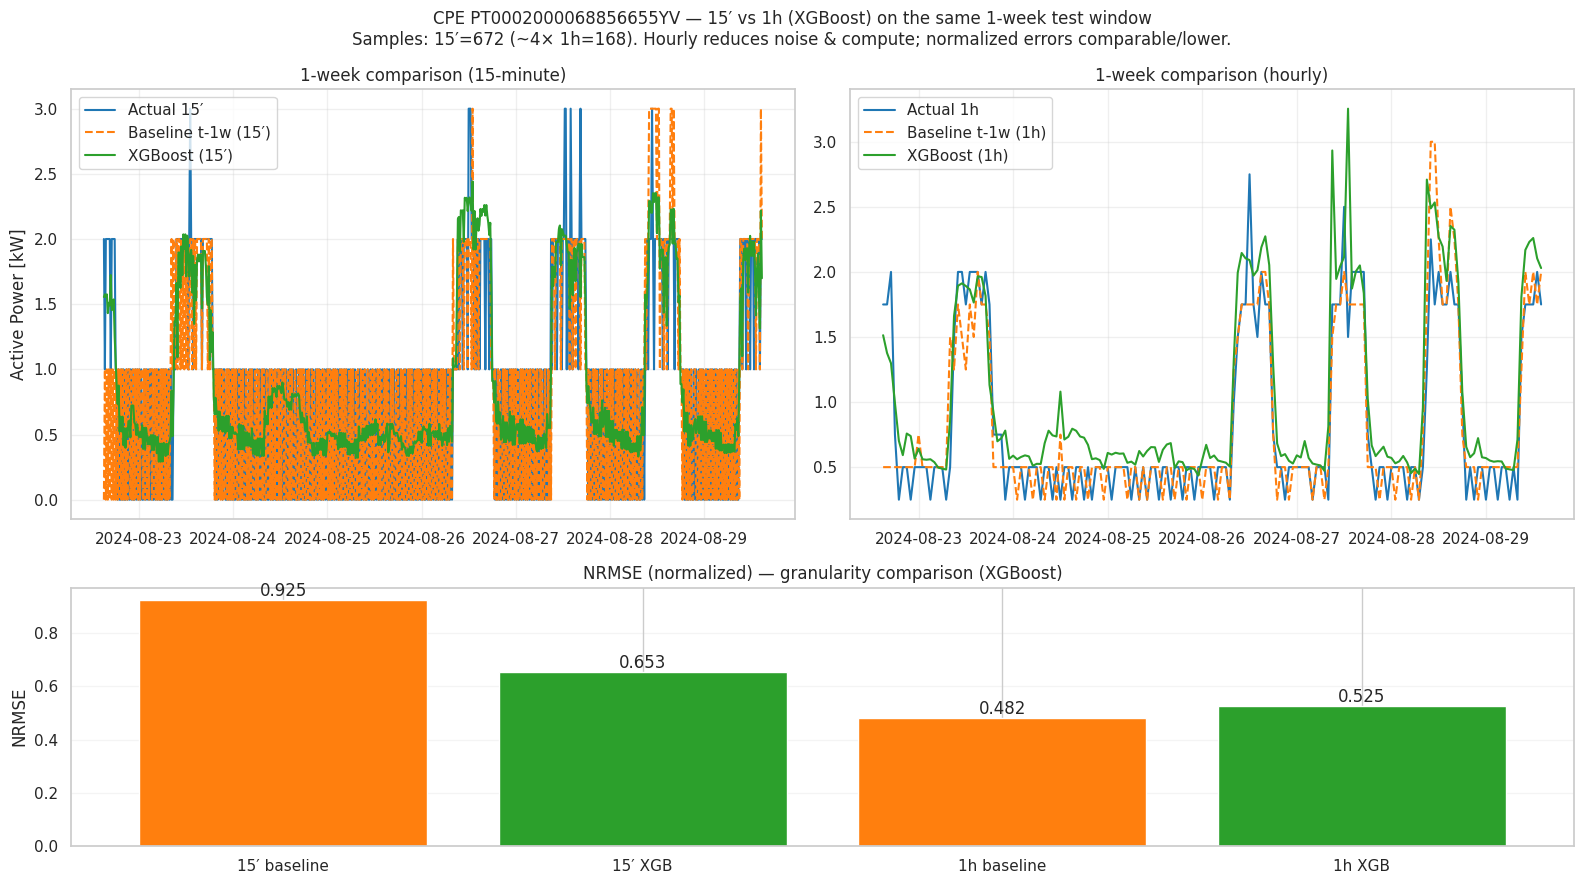


--- 15-minute (XGB) METRICS ---
RMSE_base: 0.7340
MAE_base: 0.5089
MAPE_base: 1904761984.0
NRMSE_base: 0.9255
RMSE_model: 0.5180
MAE_model: 0.4687
MAPE_model: 2091118592.0
NRMSE_model: 0.6532
N_points: 672

--- Hourly (XGB) METRICS ---
RMSE_base: 0.3122
MAE_base: 0.1875
MAPE_base: 32.63496017456055
NRMSE_base: 0.4818
RMSE_model: 0.3401
MAE_model: 0.2383
MAPE_model: 47.437469482421875
NRMSE_model: 0.5249
N_points: 168


In [ ]:

# Choose a CPE (e.g., the first available)
example_cpe = df_clean["CPE"].unique()[0]

# Run the 15' vs 1h comparison with XGBoost
metrics_xgb = compare_15min_vs_hourly_xgb(
    df_clean,
    target_cpe=example_cpe,
    target_col="PotActiva",
    plot_path="comparison_15m_vs_1h_xgb.png",
    xgb_params=None  # or pass custom params dict
)

RandomForest comparison

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone

#Main function: compare 15' vs 1h on the same test week
def compare_15min_vs_hourly(df_clean, target_cpe, target_col="PotActiva",
                            model_name="RandomForest", plot_path="comparison_15m_vs_1h.png"):

    def rmse(y_true, y_pred):
        """Root Mean Squared Error."""
        return np.sqrt(mean_squared_error(y_true, y_pred))

    def mae(y_true, y_pred):
        """Mean Absolute Error."""
        return mean_absolute_error(y_true, y_pred)

    def mape(y_true, y_pred, eps=1e-8):
        """Mean Absolute Percentage Error (in %)."""
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

    def nrmse(y_true, y_pred):

        return rmse(y_true, y_pred) / (np.std(y_true) + 1e-8)

    # Week-safe features for 15-minute data (lags >= one week)
    def make_features_15m(s_df, target_col="PotActiva"):

        d = s_df.copy()

        # Time-based features (derived from timestamp -> no leakage)
        d["hour"]      = d.index.hour
        d["dayofweek"] = d.index.dayofweek
        d["month"]     = d.index.month

        # One week at 15 minutes: 7*24*4 = 672 steps
        d["lag_672"]   = d[target_col].shift(672)     # 1 week lag
        d["lag_1344"]  = d[target_col].shift(1344)    # 2 weeks lag

        # Week-safe rolling: shift first, then roll (avoids peeking into the future)
        d["roll_mean_672"] = d[target_col].shift(672).rolling(672).mean()
        d["roll_std_672"]  = d[target_col].shift(672).rolling(672).std()

        # Optional seasonal encodings (purely time-derived)
        d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
        d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)

        return d.dropna()

    # Week-safe features for hourly data (lags >= one week)
    def make_features_1h(s_df, target_col="PotActiva"):

        d = s_df.copy()

        # Time features
        d["hour"]      = d.index.hour
        d["dayofweek"] = d.index.dayofweek
        d["month"]     = d.index.month

        # One week at hourly freq: 168
        d["lag_168"]   = d[target_col].shift(168)     # 1 week lag
        d["lag_336"]   = d[target_col].shift(336)     # 2 weeks lag

        # Week-safe rolling (shift -> then roll)
        d["roll_mean_168"] = d[target_col].shift(168).rolling(168).mean()
        d["roll_std_168"]  = d[target_col].shift(168).rolling(168).std()

        d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
        d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)

        return d.dropna()

    # Weekly baseline (same hour one week before)
    def weekly_baseline(series, weekly_shift):

        return series.shift(weekly_shift)

    # Time-based split 70/30 (no shuffling)
    def time_split(df, target_col="PotActiva", train_ratio=0.7):

        split_idx = int(len(df) * train_ratio)
        train = df.iloc[:split_idx]
        test  = df.iloc[split_idx:]
        X_train = train.drop(columns=[target_col])
        y_train = train[target_col]
        X_test  = test.drop(columns=[target_col])
        y_test  = test[target_col]
        return X_train, y_train, X_test, y_test

    # Model factory
    def get_model(model_name="RandomForest"):

        if model_name == "RandomForest":
            return RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)
        else:
            try:
                from xgboost import XGBRegressor
                return XGBRegressor(
                    n_estimators=400, learning_rate=0.05, max_depth=6,
                    subsample=0.9, colsample_bytree=0.9, random_state=42, verbosity=0
                )
            except Exception:
                # Fallback to RF if XGBoost is not available in the environment
                return RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)


    # 1) Extract one CPE time series
    df_cpe = df_clean[df_clean["CPE"] == target_cpe].copy().sort_index()
    if df_cpe.empty:
        raise ValueError(f"No data for CPE {target_cpe}")

    # 2) 15-minute series (already at 15' in df_clean). Keep frequency as is.
    s_15m = df_cpe[[target_col]].copy()
    WEEK_SHIFT_15M = 7 * 24 * 4  # 672

    # 3) Hourly series via resample (mean); drop missing
    s_1h = df_cpe[[target_col]].resample("1H").mean().dropna()
    WEEK_SHIFT_1H  = 168

    # 4) Week-safe features
    f_15m = make_features_15m(s_15m, target_col=target_col)
    f_1h  = make_features_1h(s_1h,  target_col=target_col)

    # 5) 70/30 time split
    Xtr_15m, ytr_15m, Xte_15m, yte_15m = time_split(f_15m, target_col=target_col)
    Xtr_1h,  ytr_1h,  Xte_1h,  yte_1h  = time_split(f_1h,  target_col=target_col)

    # 6) Define a common 7-day window inside both test sets
    start = max(yte_15m.index.min(), yte_1h.index.min())
    end   = start + pd.Timedelta(days=7)
    yte_15m_w = yte_15m.loc[(yte_15m.index >= start) & (yte_15m.index < end)]
    yte_1h_w  = yte_1h.loc[(yte_1h.index >= start)  & (yte_1h.index  < end)]

    # Align features on the same week window
    Xte_15m_w = Xte_15m.loc[yte_15m_w.index]
    Xte_1h_w  = Xte_1h.loc[yte_1h_w.index]

    # 7) Weekly naive baseline (same hour one week earlier)
    base_15m_w = weekly_baseline(s_15m[target_col], WEEK_SHIFT_15M).loc[yte_15m_w.index]
    base_1h_w  = weekly_baseline(s_1h[target_col],  WEEK_SHIFT_1H).loc[yte_1h_w.index]

    # 8) Train the feature-based models
    model_15m = get_model(model_name)
    model_1h  = get_model(model_name)

    model_15m.fit(Xtr_15m.values, ytr_15m.values)
    pred_15m_w = model_15m.predict(Xte_15m_w.values)

    model_1h.fit(Xtr_1h.values, ytr_1h.values)
    pred_1h_w = model_1h.predict(Xte_1h_w.values)

    # 9) Compute metrics for both granularities
    metrics = {
        "15m": {
            "RMSE_base": rmse(yte_15m_w.values, base_15m_w.values),
            "MAE_base":  mae(yte_15m_w.values, base_15m_w.values),
            "MAPE_base": mape(yte_15m_w.values, base_15m_w.values),
            "NRMSE_base": nrmse(yte_15m_w.values, base_15m_w.values),

            "RMSE_model": rmse(yte_15m_w.values, pred_15m_w),
            "MAE_model":  mae(yte_15m_w.values, pred_15m_w),
            "MAPE_model": mape(yte_15m_w.values, pred_15m_w),
            "NRMSE_model": nrmse(yte_15m_w.values, pred_15m_w),

            "N_points": len(yte_15m_w)
        },
        "1h": {
            "RMSE_base": rmse(yte_1h_w.values, base_1h_w.values),
            "MAE_base":  mae(yte_1h_w.values, base_1h_w.values),
            "MAPE_base": mape(yte_1h_w.values, base_1h_w.values),
            "NRMSE_base": nrmse(yte_1h_w.values, base_1h_w.values),

            "RMSE_model": rmse(yte_1h_w.values, pred_1h_w),
            "MAE_model":  mae(yte_1h_w.values, pred_1h_w),
            "MAPE_model": mape(yte_1h_w.values, pred_1h_w),
            "NRMSE_model": nrmse(yte_1h_w.values, pred_1h_w),

            "N_points": len(yte_1h_w)
        }
    }

    # 10) Plot comparison figure
    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.2])

    # (A) 15-minute panel
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(yte_15m_w.index, yte_15m_w.values, label="Actual 15′", color="#1f77b4", lw=1.5)
    ax1.plot(base_15m_w.index, base_15m_w.values, label="Baseline t-1w (15′)", color="#ff7f0e", ls="--")
    ax1.plot(yte_15m_w.index, pred_15m_w, label=f"Model {model_name} (15′)", color="#2ca02c")
    ax1.set_title("1-week comparison (15-minute)")
    ax1.set_ylabel("Active Power [kW]")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # (B) 1-hour panel
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(yte_1h_w.index, yte_1h_w.values, label="Actual 1h", color="#1f77b4", lw=1.5)
    ax2.plot(base_1h_w.index, base_1h_w.values, label="Baseline t-1w (1h)", color="#ff7f0e", ls="--")
    ax2.plot(yte_1h_w.index, pred_1h_w, label=f"Model {model_name} (1h)", color="#2ca02c")
    ax2.set_title("1-week comparison (hourly)")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # (C) Bar chart: NRMSE baseline vs model, 15′ vs 1h
    ax3 = fig.add_subplot(gs[1, :])
    labels = ["15′ baseline", "15′ model", "1h baseline", "1h model"]
    values = [
        metrics["15m"]["NRMSE_base"], metrics["15m"]["NRMSE_model"],
        metrics["1h"]["NRMSE_base"],  metrics["1h"]["NRMSE_model"]
    ]
    colors = ["#ff7f0e", "#2ca02c", "#ff7f0e", "#2ca02c"]
    ax3.bar(labels, values, color=colors)
    ax3.set_title("NRMSE (normalized) — granularity comparison")
    ax3.set_ylabel("NRMSE")
    for i, v in enumerate(values):
        ax3.text(i, v, f"{v:.3f}", ha="center", va="bottom")
    ax3.grid(axis="y", alpha=0.2)

    # Caption: sample count and compute-cost rationale
    n15 = metrics["15m"]["N_points"]
    n1h = metrics["1h"]["N_points"]
    fig.suptitle(
        f"CPE {target_cpe} — 15′ vs 1h on the same 1-week test window\n"
        f"Samples (week): 15′={n15} (~4× 1h={n1h}). "
        f"Hourly reduces noise and compute load; normalized errors are comparable or lower.",
        y=0.98, fontsize=12
    )

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    # 11) Print metrics summary to console
    print("\n--- 15-minute METRICS ---")
    for k, v in metrics["15m"].items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")
    print("\n--- Hourly METRICS ---")
    for k, v in metrics["1h"].items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    return metrics


/tmp/ipython-input-108835321.py:187: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  s_1h = df_cpe[[target_col]].resample("1H").mean().dropna()


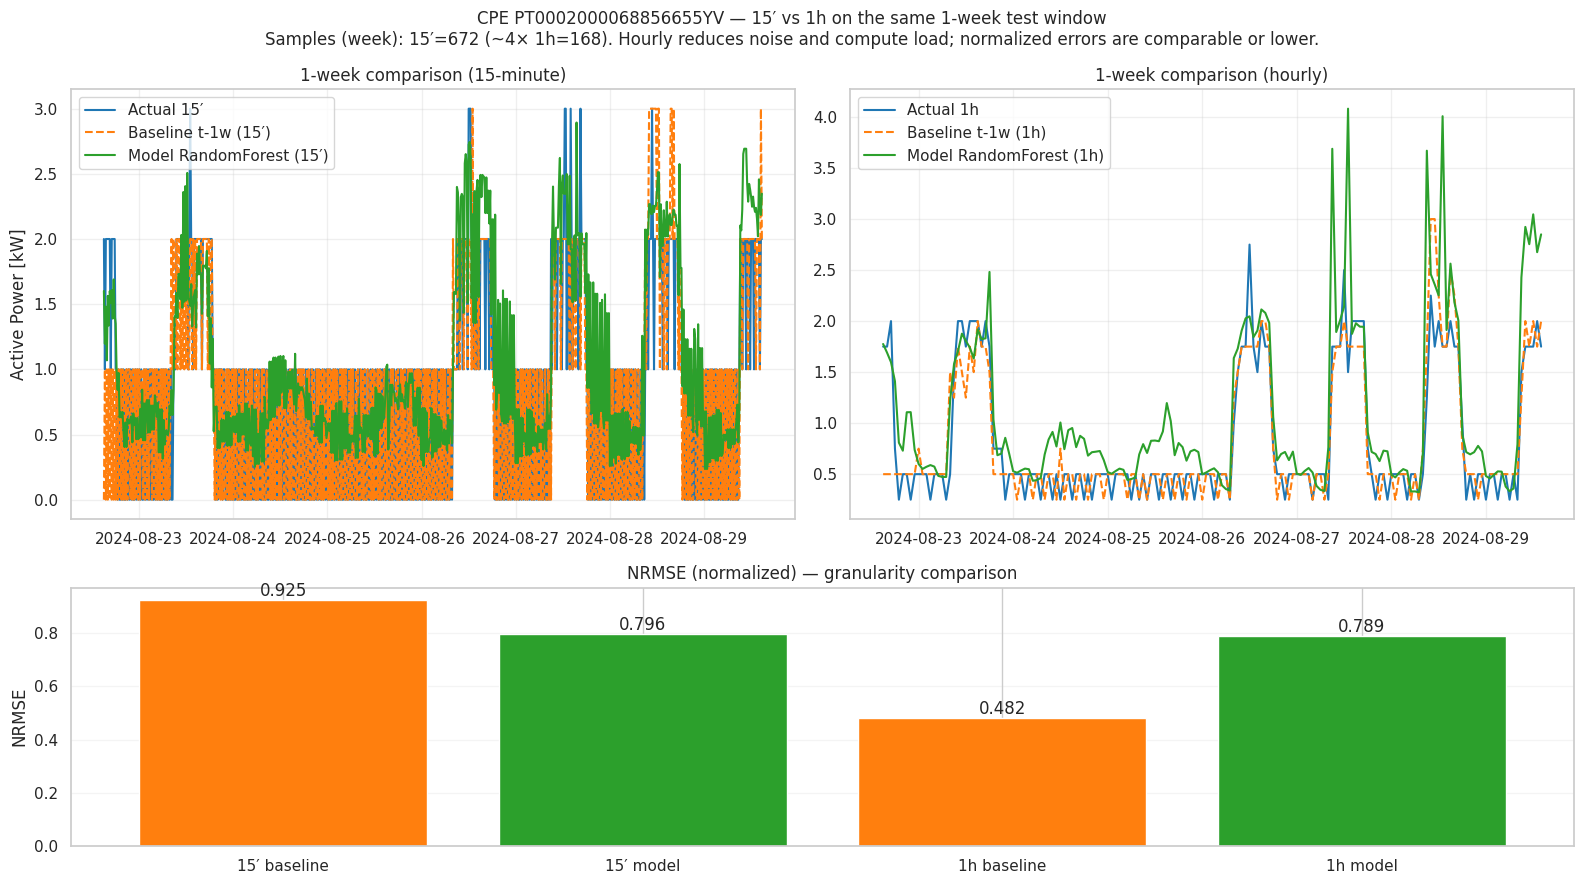


--- 15-minute METRICS ---
RMSE_base: 0.7340
MAE_base: 0.5089
MAPE_base: 1904761984.0
NRMSE_base: 0.9255
RMSE_model: 0.6313
MAE_model: 0.5476
MAPE_model: 2676738312.9069
NRMSE_model: 0.7960
N_points: 672

--- Hourly METRICS ---
RMSE_base: 0.3122
MAE_base: 0.1875
MAPE_base: 32.63496017456055
NRMSE_base: 0.4818
RMSE_model: 0.5115
MAE_model: 0.3218
MAPE_model: 60.8901
NRMSE_model: 0.7894
N_points: 168


In [ ]:

# Pick a CPE (e.g., the first available CPE in df_clean)
example_cpe = df_clean["CPE"].unique()[0]

# Run the 15' vs 1h comparison using RandomForest (or set model_name="XGB" if xgboost is installed)
metrics = compare_15min_vs_hourly(
    df_clean,
    target_cpe=example_cpe,
    target_col="PotActiva",
    model_name="RandomForest",            # or "XGB"
    plot_path="comparison_15m_vs_1h.png"
)



15 min --> hourly based data shift for one CPE and grafic representation of 70/30 split for one CPE

Modeling for CPE: PT0002000068859187RL
Train samples: 14314
Test samples: 6135


/tmp/ipython-input-1450411458.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_model[['PotActiva']].resample('H').mean()


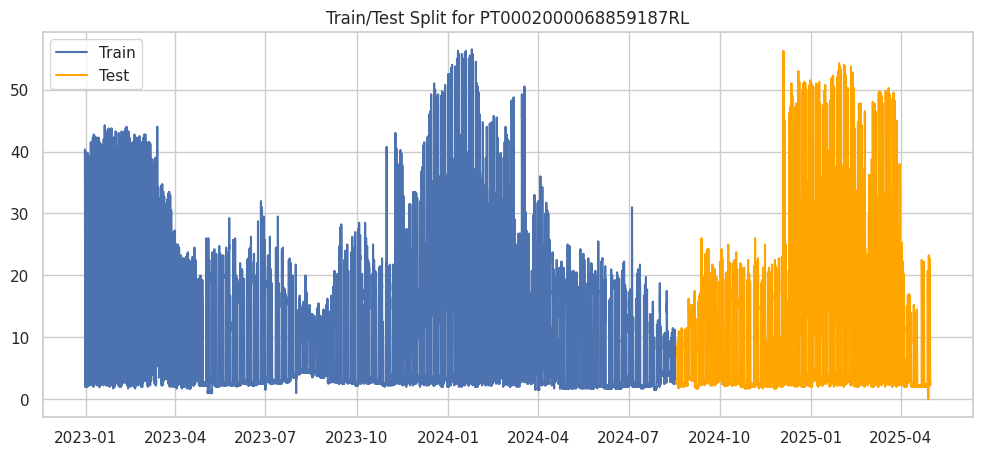

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Select a Representative CPE from the Main Cluster (Cluster 0)
# We use the results from your DBSCAN step
main_cluster_cpes = final_features_clean[final_features_clean["cluster_dbscan"] == 0].index
target_cpe = main_cluster_cpes[0] # Pick the first one
print(f"Modeling for CPE: {target_cpe}")

# 2. Prepare the Series
# We assume 'df_clean' is available from your previous steps
df_model = df_clean[df_clean['CPE'] == target_cpe].copy()
df_model = df_model.sort_index()

# RESAMPLING: 15-min data is very noisy and computationally heavy.
# We will resample to HOURLY for the prediction task (standard practice).
df_hourly = df_model[['PotActiva']].resample('H').mean()

# 3. Train/Test Split (70% Train, 30% Test)
train_size = int(len(df_hourly) * 0.7)
train_data_ts, test_data_ts = df_hourly.iloc[:train_size], df_hourly.iloc[train_size:]

print(f"Train samples: {len(train_data_ts)}")
print(f"Test samples: {len(test_data_ts)}")

# Plot the split
plt.figure(figsize=(12, 5))
plt.plot(train_data_ts.index, train_data_ts['PotActiva'], label='Train')
plt.plot(test_data_ts.index, test_data_ts['PotActiva'], label='Test', color='orange')
plt.title(f"Train/Test Split for {target_cpe}")
plt.legend()
plt.show()

# Helper function for evaluation
def evaluate_forecast(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    return rmse

Iterate it for all the CPEs

In [ ]:

# Generalize the pipeline to ALL CPEs (keep the plot for one CPE)
# - For each CPE:
#   1) Build hourly series (resample 'H')
#   2) Chronological 70/30 split
#   3) Evaluate weekly naive baseline (t-168) on the first test week
#   4) Store metrics per CPE (RMSE / MAE / MAPE / NRMSE)


import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Metrics helpers ---
def rmse(y_true, y_pred):
    """Root Mean Squared Error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    """Mean Absolute Error."""
    return float(mean_absolute_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    """Mean Absolute Percentage Error (%)."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)

def nrmse(y_true, y_pred, eps=1e-8):
    """Normalized RMSE (RMSE/std of y_true on the evaluation window)."""
    return float(rmse(y_true, y_pred) / (np.std(y_true) + eps))

#Weekly baseline (same hour one week before)
def weekly_baseline(series, weekly_shift=168):

    return series.shift(weekly_shift)

#Chronological split 70/30 for a univariate hourly series
def time_split_series(s, train_ratio=0.7):
    split_idx = int(len(s) * train_ratio)
    return s.iloc[:split_idx].copy(), s.iloc[split_idx:].copy()

#Evaluate baseline for one CPE on the first test week
def evaluate_baseline_for_cpe(df_clean, cpe, target_col="PotActiva", eval_h=168):

    # Build hourly series (mean aggregation) and drop missing
    s_1h = (
        df_clean[df_clean["CPE"] == cpe][target_col]
        .sort_index()
        .resample("1H").mean()
        .dropna()
    )

    # Ensure enough history for a fair weekly evaluation
    if len(s_1h) < (168 * 3):  # at least ~3 weeks: train + baseline context + test week
        return None

    # 70/30 chronological split
    train_s, test_s = time_split_series(s_1h, train_ratio=0.7)
    if len(test_s) < eval_h:
        return None

    # Evaluation window: first eval_h hours of the test
    test_week = test_s.iloc[:eval_h]

    # Weekly baseline aligned on the same timestamps
    baseline_week = weekly_baseline(s_1h, weekly_shift=168).loc[test_week.index]

    # Compute metrics
    return {
        "CPE": cpe,
        "Model": "Baseline_t-168",
        "N_eval": len(test_week),
        "RMSE": rmse(test_week.values, baseline_week.values),
        "MAE":  mae (test_week.values, baseline_week.values),
        "MAPE": mape(test_week.values, baseline_week.values),
        "NRMSE": nrmse(test_week.values, baseline_week.values),
    }

#Loop across ALL CPEs (excluding the plot which remains for the selected CPE)
def evaluate_all_cpes_baseline(df_clean, cpe_list=None, target_col="PotActiva", eval_h=168):

    if cpe_list is None:
        cpe_list = df_clean["CPE"].dropna().unique().tolist()

    rows = []
    for i, cpe in enumerate(cpe_list, start=1):
        res = evaluate_baseline_for_cpe(df_clean, cpe, target_col=target_col, eval_h=eval_h)
        if res is not None:
            rows.append(res)
        # Optional progress log every 25 CPEs
        if i % 25 == 0:
            print(f"...processed {i}/{len(cpe_list)} CPEs")

    if not rows:
        print("No baseline metrics computed — check data coverage or increase history.")
        return pd.DataFrame()

    df_metrics = pd.DataFrame(rows)
    # Quick summary across all CPEs
    summary = (df_metrics.groupby("Model")["NRMSE"]
               .agg(["count", "mean", "std", "median"])
               .round(4))
    print("\n=== Baseline (t-168) summary across CPEs ===")
    print(summary.to_string())

    return df_metrics

all_cpes = df_clean["CPE"].dropna().unique().tolist()
# Alternatively: all_cpes = main_cluster_cpes.tolist()  # only cluster 0 CPEs

baseline_metrics_all = evaluate_all_cpes_baseline(
    df_clean,
    cpe_list=all_cpes,
    target_col="PotActiva",
    eval_h=168  # evaluate the first week of the test split
)


/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarn

...processed 25/91 CPEs


/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarn

...processed 50/91 CPEs


/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarn

...processed 75/91 CPEs

=== Baseline (t-168) summary across CPEs ===
                count   mean     std  median
Model                                       
Baseline_t-168     91  0.795  0.6298  0.6686


/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-622226209.py:61: FutureWarn

ARIMA approach

In [ ]:

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Metrics helpers (come nel tuo blocco baseline)
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)

def nrmse(y_true, y_pred, eps=1e-8):
    return float(rmse(y_true, y_pred) / (np.std(y_true) + eps))

# Weekly baseline (stesso orario una settimana prima)
def weekly_baseline(series, weekly_shift=168):
    return series.shift(weekly_shift)

# Split cronologico 70/30 su una serie oraria
def time_split_series(s, train_ratio=0.7):
    split_idx = int(len(s) * train_ratio)
    return s.iloc[:split_idx].copy(), s.iloc[split_idx:].copy()

# (Opzionale) piccola ricerca AIC per scegliere (p,d,q)
def select_arima_order_aic(y_train, p_grid=(0,1,2,3), d_grid=(0,1), q_grid=(0,1,2,3)):
    best_order = (1, 1, 0)
    best_aic = np.inf
    for p in p_grid:
        for d in d_grid:
            for q in q_grid:
                try:
                    fit = ARIMA(y_train, order=(p, d, q)).fit()
                    if fit.aic < best_aic:
                        best_aic, best_order = fit.aic, (p, d, q)
                except Exception:
                    # salta ordini non convergenti
                    pass
    return best_order, best_aic

# ARIMA su un singolo CPE
def evaluate_arima_for_cpe(df_clean, cpe, target_col="PotActiva", eval_h=168,
                           order=(5,1,0), auto_order=False, verbose=False):

    # Serie oraria
    s_1h = (
        df_clean[df_clean["CPE"] == cpe][target_col]
        .sort_index()
        .resample("1H").mean()
        .dropna()
    )

    # Copertura minima: ~3 settimane (train + contesto baseline + test week)
    if len(s_1h) < (168 * 3):
        if verbose:
            print(f"[skip] CPE {cpe}: insufficient history ({len(s_1h)} pts)")
        return None

    # Split 70/30
    train_s, test_s = time_split_series(s_1h, train_ratio=0.7)
    if len(test_s) < eval_h:
        if verbose:
            print(f"[skip] CPE {cpe}: test too short ({len(test_s)} < {eval_h})")
        return None

    # Finestra di valutazione: prima settimana del test
    test_week = test_s.iloc[:eval_h]

    # Baseline settimanale, allineata alla stessa finestra
    baseline_week = weekly_baseline(s_1h, weekly_shift=168).loc[test_week.index]

    # Scelta ordine ARIMA (opzionale via AIC)
    used_order = order
    if auto_order:
        try:
            used_order, _ = select_arima_order_aic(train_s)
            if verbose:
                print(f"CPE {cpe}: selected ARIMA order {used_order} via AIC")
        except Exception as e:
            if verbose:
                print(f"CPE {cpe}: AIC selection failed ({e}), using {order}")

    # Fit ARIMA su train
    try:
        arima_fit = ARIMA(train_s, order=used_order).fit()
        pred_arima = arima_fit.forecast(steps=len(test_week))
    except Exception as e:
        # Fallback: prova un ordine semplice o segnala errore
        if verbose:
            print(f"CPE {cpe}: ARIMA({used_order}) failed ({e}); trying (1,1,0)")
        try:
            arima_fit = ARIMA(train_s, order=(1,1,0)).fit()
            pred_arima = arima_fit.forecast(steps=len(test_week))
            used_order = (1,1,0)
        except Exception as e2:
            if verbose:
                print(f"CPE {cpe}: ARIMA fallback failed ({e2}); returning None")
            return None

    # Metriche vs actual (test_week) e baseline
    y_true = test_week.values
    y_arima = np.asarray(pred_arima)
    y_base  = baseline_week.values

    metrics = {
        "CPE": cpe,
        "Model": "ARIMA",
        "ARIMA_order": used_order,
        "N_eval": len(test_week),
        "RMSE_ARIMA": rmse(y_true, y_arima),
        "MAE_ARIMA":  mae(y_true, y_arima),
        "MAPE_ARIMA": mape(y_true, y_arima),
        "NRMSE_ARIMA": nrmse(y_true, y_arima),

        # (facoltative) metriche baseline per confronto rapido
        "RMSE_Base": rmse(y_true, y_base),
        "MAE_Base":  mae(y_true, y_base),
        "MAPE_Base": mape(y_true, y_base),
        "NRMSE_Base": nrmse(y_true, y_base),
    }
    return metrics

# --- ARIMA su tutti i CPE ---
def evaluate_all_cpes_arima(df_clean, cpe_list=None, target_col="PotActiva",
                            eval_h=168, order=(5,1,0), auto_order=False, verbose=False,
                            progress_every=25):

    if cpe_list is None:
        cpe_list = df_clean["CPE"].dropna().unique().tolist()

    rows = []
    for i, cpe in enumerate(cpe_list, start=1):
        res = evaluate_arima_for_cpe(df_clean, cpe, target_col=target_col,
                                     eval_h=eval_h, order=order,
                                     auto_order=auto_order, verbose=verbose)
        if res is not None:
            rows.append(res)
        if progress_every and i % progress_every == 0:
            print(f"...processed {i}/{len(cpe_list)} CPEs")

    if not rows:
        print("No ARIMA metrics computed — check data coverage or increase history.")
        return pd.DataFrame()

    df_metrics = pd.DataFrame(rows)

    # Summary su NRMSE_ARIMA (media / mediana / std)
    summary = (df_metrics["NRMSE_ARIMA"]
               .agg(["count", "mean", "std", "median"])
               .round(4))
    print("\n=== ARIMA summary across CPEs (NRMSE) ===")
    print(summary.to_string())

    return df_metrics

all_cpes = df_clean["CPE"].dropna().unique().tolist()
# all_cpes = final_features_clean[final_features_clean["cluster_dbscan"] == 0].index.tolist()

# Esegui ARIMA su tutti i CPE (ordine fisso) :
arima_metrics_all = evaluate_all_cpes_arima(
    df_clean,
    cpe_list=all_cpes,
    target_col="PotActiva",
    eval_h=168,
    order=(5,1,0),      # ordine di base
    auto_order=False,   # True per selezionare (p,d,q) via AIC su ciascun CPE
    verbose=False
)

# Salva su CSV (facoltativo)
# arima_metrics_all.to_csv("results/arima_metrics_all_cpes_hourly.csv", index=False)

/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: Fut

...processed 25/91 CPEs


/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: Fut

...processed 50/91 CPEs


/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .

...processed 75/91 CPEs


/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()
/tmp/ipython-input-3182768836.py:61: Fut


=== ARIMA summary across CPEs (NRMSE) ===
count     91.0000
mean       1.2695
std        0.4209
median     1.1943


Pipeline Feature‑based (RF / XGB / MLP)

data merging and RF/XGB/MLP also ARIMA reimplemented here

Running models (Baseline, XGB, RF, MLP, ARIMA)...
This may take some time depending on the number of CPEs.
Processed 0 CPEs...
Processed 10 CPEs...
Processed 20 CPEs...
Processed 30 CPEs...
Processed 40 CPEs...
Processed 50 CPEs...
Processed 60 CPEs...
Processed 70 CPEs...
Processed 80 CPEs...
Processed 90 CPEs...
Model Evaluation Completed.

Generating Cluster Analysis Heatmap...


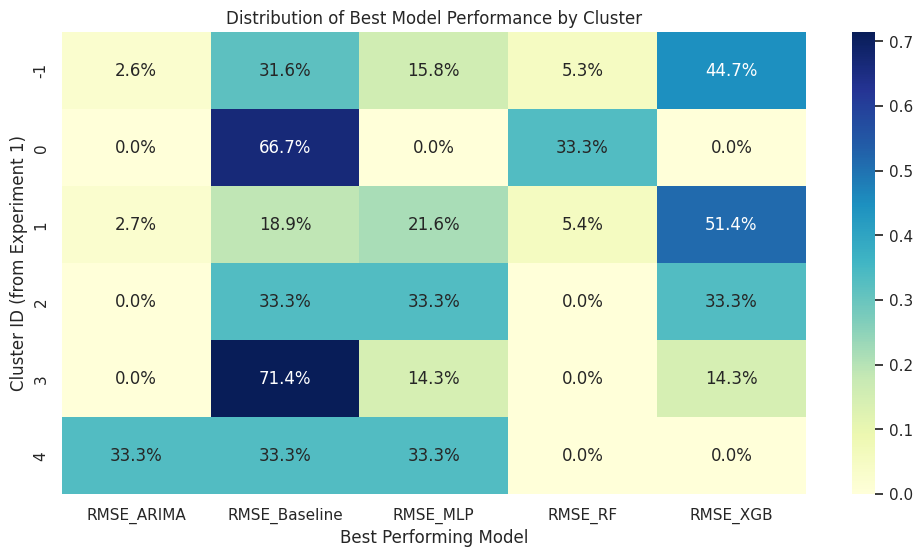


Win Rates by Cluster:
Best_Model  RMSE_ARIMA  RMSE_Baseline  RMSE_MLP   RMSE_RF  RMSE_XGB
Cluster                                                            
-1            0.026316       0.315789  0.157895  0.052632  0.447368
 0            0.000000       0.666667  0.000000  0.333333  0.000000
 1            0.027027       0.189189  0.216216  0.054054  0.513514
 2            0.000000       0.333333  0.333333  0.000000  0.333333
 3            0.000000       0.714286  0.142857  0.000000  0.142857
 4            0.333333       0.333333  0.333333  0.000000  0.000000


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

#Step 0: Prepare Static Features
# We need to define which features from Experiment 1 to use in Experiment 2
static_features_df = final_features_clean.copy()
if 'CPE' not in static_features_df.columns:
    static_features_df = static_features_df.reset_index()

# Select cluster info and key characteristics
selected_static_cols = [
    'CPE', 'cluster_dbscan', 'load_variability_index',
    'nighttime_load_share', 'power_factor', 'avg_daily_peak_time'
]
# Only keep columns that actually exist to prevent errors
existing_cols = [c for c in selected_static_cols if c in static_features_df.columns]
static_features_subset = static_features_df[existing_cols]


# Step 1: Hybrid Dataset Function
def create_hybrid_dataset(df_clean, target_cpe, static_df):
    """
    Merges hourly time-series data (lags) with static features (cluster info) for a single CPE.
    """
    # 1. Extract the specific CPE data
    df_cpe = df_clean[df_clean['CPE'] == target_cpe].copy()

    # Handle index if 'tstamp' is a column
    if 'tstamp' in df_cpe.columns:
        df_cpe = df_cpe.set_index('tstamp')

    # 2. Resample to Hourly frequency (Mean aggregation)
    df_hourly = df_cpe[['PotActiva']].resample('H').mean().dropna()

    # 3. Create Temporal Features (Week-Safe Lags)
    # We use lags >= 168 hours (1 week) to prevent data leakage
    df_hourly['hour'] = df_hourly.index.hour
    df_hourly['dayofweek'] = df_hourly.index.dayofweek
    df_hourly['lag_168'] = df_hourly['PotActiva'].shift(168) # Same time last week
    df_hourly['lag_336'] = df_hourly['PotActiva'].shift(336) # Same time 2 weeks ago
    df_hourly['roll_mean_168'] = df_hourly['PotActiva'].shift(168).rolling(24).mean()

    # Drop NaNs created by lagging
    df_hourly = df_hourly.dropna()

    # 4. Broadcast Static Features (Cluster ID, etc.) to every hourly row
    cpe_static = static_df[static_df['CPE'] == target_cpe]

    if cpe_static.empty:
        return df_hourly

    for col in cpe_static.columns:
        if col != 'CPE':
            df_hourly[col] = cpe_static[col].values[0]

    return df_hourly

#Step 2: Model Evaluation Function (Includes MLP)
def evaluate_models_for_cpe(df_clean, target_cpe, static_df):

    # 1. Prepare Data
    df_hybrid = create_hybrid_dataset(df_clean, target_cpe, static_df)

    # Skip if dataset is too small for meaningful training
    if len(df_hybrid) < 500:
        return None

    # 2. Chronological Split (70% Train, 30% Test)
    split_idx = int(len(df_hybrid) * 0.7)
    train = df_hybrid.iloc[:split_idx]
    test = df_hybrid.iloc[split_idx:]

    # Define Target and Features
    target_col = 'PotActiva'
    feature_cols = [c for c in df_hybrid.columns if c != target_col]

    X_train, y_train = train[feature_cols], train[target_col]
    X_test, y_test = test[feature_cols], test[target_col]

    # Store results (Keep Cluster ID for analysis)
    cluster_val = df_hybrid['cluster_dbscan'].iloc[0] if 'cluster_dbscan' in df_hybrid.columns else -1
    results = {'CPE': target_cpe, 'Cluster': cluster_val}

    #MODEL 1: Baseline (Persistence)
    # Prediction is simply the value from 1 week ago (lag_168)
    y_pred_base = X_test['lag_168']
    results['RMSE_Baseline'] = np.sqrt(mean_squared_error(y_test, y_pred_base))

    #MODEL 2: XGBoost (Tree-based)
    xgb = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, n_jobs=-1, random_state=42)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    results['RMSE_XGB'] = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

    # MODEL 3: Random Forest (Tree-based)
    rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    results['RMSE_RF'] = np.sqrt(mean_squared_error(y_test, y_pred_rf))

    # MODEL 4: MLP (Neural Network)
    # MLP requires feature scaling (StandardScaler) to work correctly
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) # Apply train scaling to test

    mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
    try:
        mlp.fit(X_train_scaled, y_train)
        y_pred_mlp = mlp.predict(X_test_scaled)
        results['RMSE_MLP'] = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
    except:
        results['RMSE_MLP'] = np.nan # Handle convergence errors

    # MODEL 5: ARIMA (Time-Series)
    try:
        # Using a simple order (2,1,2) for speed
        arima_model = ARIMA(y_train, order=(2, 1, 2))
        arima_fit = arima_model.fit()
        # Forecast for the entire test period
        y_pred_arima = arima_fit.forecast(steps=len(y_test))
        results['RMSE_ARIMA'] = np.sqrt(mean_squared_error(y_test, y_pred_arima))
    except:
        results['RMSE_ARIMA'] = np.nan # Handle non-convergence

    return results

# Execution Loop
all_results = []
cpe_list = df_clean['CPE'].unique()

print("Running models (Baseline, XGB, RF, MLP, ARIMA)...")
print("This may take some time depending on the number of CPEs.")

# Loop through all CPEs
for i, cpe in enumerate(cpe_list):
    res = evaluate_models_for_cpe(df_clean, cpe, static_features_subset)
    if res:
        all_results.append(res)

    # Progress check
    if i % 10 == 0:
        print(f"Processed {i} CPEs...")

# Create DataFrame from results
results_df = pd.DataFrame(all_results)
print("Model Evaluation Completed.")

#Step 3: Visualization (Heatmap)
print("\nGenerating Cluster Analysis Heatmap...")

# 1. Identify the 'Best Model' for each CPE (lowest RMSE)
model_cols = ['RMSE_Baseline', 'RMSE_XGB', 'RMSE_RF', 'RMSE_MLP', 'RMSE_ARIMA']
results_df['Best_Model'] = results_df[model_cols].idxmin(axis=1)

# 2. Check if 'Cluster' column exists to group by
if 'Cluster' in results_df.columns:
    # Calculate the percentage of wins for each model within each cluster
    cluster_analysis = results_df.groupby('Cluster')['Best_Model'].value_counts(normalize=True).unstack().fillna(0)

    # 3. Plot Heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(cluster_analysis, annot=True, fmt=".1%", cmap="YlGnBu")
    plt.title("Distribution of Best Model Performance by Cluster")
    plt.ylabel("Cluster ID (from Experiment 1)")
    plt.xlabel("Best Performing Model")
    plt.show()

    # Optional: Print the raw table
    print("\nWin Rates by Cluster:")
    print(cluster_analysis)
else:
    print("Cluster information not found. Showing general distribution:")
    print(results_df['Best_Model'].value_counts(normalize=True))

# Experiment 3

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
import warnings
import pandas as pd # Import pandas here
warnings.filterwarnings("ignore")

# Define create_features_week_safe as per the comment
def create_features_week_safe(df, target_col='PotActiva'):

    d = df.copy()

    # Time Features
    d['hour'] = d.index.hour
    d['dayofweek'] = d.index.dayofweek
    d['month'] = d.index.month
    d['is_weekend'] = (d['dayofweek'] >= 5).astype(int)

    # Lag Features (1 week = 168 hours)
    # We use 1 week ago as the primary predictor to capture weekly seasonality
    d['lag_168'] = d[target_col].shift(168)
    d['lag_336'] = d[target_col].shift(336) # 2 weeks ago

    # Rolling Stats (shifted by 168 hours to be safe)
    d['rolling_mean_168'] = d[target_col].shift(168).rolling(24).mean()

    return d.dropna()


def hourly_week_profile(series):
    # hour_of_week: Monday 0 00:00 -> 0 .. Sunday 23 -> 167
    df = series.to_frame('y').copy()
    df['hour_of_week'] = df.index.dayofweek * 24 + df.index.hour
    profile = df.groupby('hour_of_week')['y'].mean()
    # ensure index 0..167
    profile = profile.reindex(range(168)).fillna(profile.mean())
    return profile  # Series indexed 0..167

def apply_hourly_detrend(series, profile):
    s = series.copy().to_frame('y')
    s['hour_of_week'] = s.index.dayofweek * 24 + s.index.hour
    s['seasonal'] = s['hour_of_week'].map(profile)
    return s['y'] - s['seasonal'], s['seasonal']

def inv_apply_hourly_detrend(y_pred, seasonal_values):
    return y_pred + seasonal_values.values

def rmse_mae(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

def run_normalization_grid(target_cpe,
                           features_fn=create_features_week_safe,
                           evaluate_h=168,
                           results_dir="norm_exp_results"):
    os.makedirs(results_dir, exist_ok=True)

    # 1) Build hourly series for target_cpe
    df_model = df_clean[df_clean['CPE'] == target_cpe].sort_index()
    s_hourly = df_model[['PotActiva']].resample('H').mean().replace([np.inf, -np.inf], np.nan).dropna()
    # train/test 70/30 as you had
    train_size = int(len(s_hourly) * 0.7)
    train_series = s_hourly.iloc[:train_size].copy()
    test_series  = s_hourly.iloc[train_size:].copy()
    test_1w = test_series.iloc[:evaluate_h].copy()
    print(f"Train samples: {len(train_series)}  Test samples: {len(test_series)}  1-week test used: {len(test_1w)}")

    # Baseline (t-168) on test_1w
    baseline = s_hourly['PotActiva'].shift(168).loc[test_1w.index]
    mask = ~baseline.isna()
    baseline_rmse, baseline_mae = rmse_mae(test_1w.loc[mask, 'PotActiva'].values, baseline.loc[mask].values)
    print("Baseline (t-168) RMSE, MAE:", baseline_rmse, baseline_mae)

    # Create input features (week-safe) for full series (so we can align later)
    # Convert s_hourly (Series) to DataFrame for features_fn
    feat_all = features_fn(s_hourly).dropna()
    # Restrict to indices that exist in train/test
    train_feat = feat_all.loc[train_series.index.intersection(feat_all.index)].copy()
    test_feat  = feat_all.loc[test_series.index.intersection(feat_all.index)].copy()
    X_train_full = train_feat.copy()
    y_train_full = train_feat['PotActiva']
    # For 1-week evaluation, pick first evaluate_h rows from test_feat
    X_test_1w = test_feat.iloc[:evaluate_h].copy()
    y_test_1w = test_feat['PotActiva'].iloc[:evaluate_h].copy()

    # Feature list (you used before)
    features = ["hour", "dayofweek", "month", "lag_168", "lag_336", "rolling_mean_168"]
    # Add rolling_std_168 if it exists in the dataframe, otherwise exclude it.
    if "rolling_std_168" in feat_all.columns: # This feature is not in the create_features_week_safe function
        features.append("rolling_std_168") # So removing it or making sure it exists before adding.


    # Models to test
    models_dict = {
        "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                                subsample=0.9, colsample_bytree=0.9, random_state=42, verbosity=0),
        "RandomForest": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
        "MLP": MLPRegressor(hidden_layer_sizes=(128,64), max_iter=400, random_state=42)
    }

    # Normalization configs for X (list of tuples: name, scaler object or None)
    scalers = [
        ("none", None),
        ("standard", StandardScaler()),
        ("minmax", MinMaxScaler()),
        ("robust", RobustScaler()),
    ]

    # Target transformations
    target_transforms = [
        ("none", None),
        ("log1p", "log1p"),
        ("standard", StandardScaler()),  # scaler on y (will be fit on train y)
        ("seasonal", "seasonal")  # subtract hourly-week profile from y
    ]

    results = []
    run_id = 0

    for scaler_name, scaler_obj in scalers:
        for target_name, target_obj in target_transforms:
            run_id += 1
            config_name = f"{scaler_name}__{target_name}"
            print("\n=== Run:", config_name, "===")

            # Copy raw train/test to avoid mutation
            X_tr = X_train_full[features].copy()
            X_te = X_test_1w[features].copy()
            y_tr = y_train_full.copy()
            y_te = y_test_1w.copy()

            # --- 1) Seasonal target detrend (if requested) ---
            seasonal_profile = None
            seasonal_series_train = None
            if target_name == "seasonal":
                seasonal_profile = hourly_week_profile(y_tr)  # length 168
                y_tr_d, _ = apply_hourly_detrend(y_tr, seasonal_profile)
                # For test, compute seasonal values aligned to test index
                y_te_d, seasonal_test_values = apply_hourly_detrend(y_te, seasonal_profile)
                y_tr = y_tr_d
                y_te = y_te_d
            elif target_name == "log1p":
                # apply log1p on train; ensure positive input (PotActiva presumably >=0)
                y_tr = np.log1p(y_tr)
                y_te = np.log1p(y_te)
            elif target_name == "standard":
                y_scaler = StandardScaler()
                y_tr = pd.Series(y_scaler.fit_transform(y_tr.values.reshape(-1,1)).ravel(), index=y_tr.index)
                # For inverse we keep y_scaler
            else:
                # none
                pass

            # 2) Fit scaler for X on training set ONLY (no leakage)
            if scaler_obj is not None:
                X_scaler = scaler_obj
                X_tr_scaled = pd.DataFrame(X_scaler.fit_transform(X_tr), index=X_tr.index, columns=X_tr.columns)
                X_te_scaled = pd.DataFrame(X_scaler.transform(X_te), index=X_te.index, columns=X_te.columns)
            else:
                X_tr_scaled, X_te_scaled = X_tr.copy(), X_te.copy()


            # 3) Train models on (X_tr_scaled, y_tr) and predict on X_te_scaled
            for mname, m in models_dict.items():
                # Make a fresh clone for each run
                from sklearn.base import clone
                model = clone(m)

                model.fit(X_tr_scaled.values, y_tr.values.ravel())
                # Predict on test
                y_pred = model.predict(X_te_scaled.values)

                # 4) Inverse target transforms to original units for metrics
                y_pred_orig = np.array(y_pred).copy()
                y_true_orig = np.array(y_test_1w.values).ravel().copy()  # original true (untransformed) for comparison

                # invert target transforms in reverse order
                if target_name == "seasonal":
                    # Need to add seasonal back using seasonal_test_values aligned
                    y_pred_orig = inv_apply_hourly_detrend(pd.Series(y_pred, index=X_te.index), seasonal_test_values)
                    y_pred_orig = np.asarray(y_pred_orig)
                elif target_name == "log1p":
                    y_pred_orig = np.expm1(y_pred_orig)  # inverse of log1p
                elif target_name == "standard":
                    # invert using y_scaler fitted earlier
                    y_pred_orig = y_scaler.inverse_transform(y_pred_orig.reshape(-1,1)).ravel()
                else:
                    # none -> already in original units
                    pass

                # Compute metrics against original test truth (test_1w)
                y_true_eval = y_test_1w.values.ravel()
                # If shapes mismatch, trim
                L = min(len(y_true_eval), len(y_pred_orig))
                y_true_eval = y_true_eval[:L]
                y_pred_orig = y_pred_orig[:L]

                rmse, mae = rmse_mae(y_true_eval, y_pred_orig)

                # Per-hour RMSE (hour of day)
                idx = X_te.index[:L]
                df_err = pd.DataFrame({'y_true': y_true_eval, 'y_pred': y_pred_orig}, index=idx)
                df_err['hour'] = df_err.index.hour
                per_hour_rmse = df_err.groupby('hour').apply(lambda g: np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])))

                result_row = {
                    "config": config_name,
                    "scaler": scaler_name,
                    "target_transform": target_name,
                    "model": mname,
                    "rmse": rmse,
                    "mae": mae,
                    "baseline_rmse": baseline_rmse,
                    "run_id": run_id,
                    "per_hour_rmse": per_hour_rmse.to_dict()
                }
                results.append(result_row)
                print(f"{mname} | rmse={rmse:.4f} mae={mae:.4f}")

    # Save results DF (summarize)
    summary_rows = []
    for r in results:
        summary_rows.append({
            "run_id": r['run_id'],
            "config": r['config'],
            "model": r['model'],
            "rmse": r['rmse'],
            "mae": r['mae']
        })
    summary_df = pd.DataFrame(summary_rows).sort_values('rmse')
    summary_df.to_csv(os.path.join(results_dir, f"norm_exp_summary_{target_cpe}.csv"), index=False)
    print("\nSaved summary to", os.path.join(results_dir, f"norm_exp_summary_{target_cpe}.csv"))

    # Also save full results with per-hour dict for inspection (pickle)
    import pickle
    with open(os.path.join(results_dir, f"norm_exp_full_{target_cpe}.pkl"), "wb") as f:
        pickle.dump(results, f)
    print("Saved full results (pickle).")

    return summary_df, results

# Run on the chosen target CPE
summary_df, full_results = run_normalization_grid(target_cpe)
print(summary_df.head(20))


Train samples: 14314  Test samples: 6135  1-week test used: 168
Baseline (t-168) RMSE, MAE: 1.4427311295270242 0.956845223903656

=== Run: none__none ===
XGBoost | rmse=1.9571 mae=1.3720
RandomForest | rmse=2.2153 mae=1.2891
MLP | rmse=2.0498 mae=1.2618

=== Run: none__log1p ===
XGBoost | rmse=1.6936 mae=1.2275
RandomForest | rmse=2.1130 mae=1.2237
MLP | rmse=2.2578 mae=1.5916

=== Run: none__standard ===
XGBoost | rmse=1.9881 mae=1.3938
RandomForest | rmse=2.2175 mae=1.2919
MLP | rmse=2.3868 mae=1.4850

=== Run: none__seasonal ===
XGBoost | rmse=2.4801 mae=1.6001
RandomForest | rmse=1.4650 mae=1.1602
MLP | rmse=2.7333 mae=2.1148

=== Run: standard__none ===
XGBoost | rmse=1.9571 mae=1.3720
RandomForest | rmse=2.2105 mae=1.2909
MLP | rmse=2.1397 mae=1.5400

=== Run: standard__log1p ===
XGBoost | rmse=1.6936 mae=1.2275
RandomForest | rmse=2.1085 mae=1.2219
MLP | rmse=1.7666 mae=1.3491

=== Run: standard__standard ===
XGBoost | rmse=1.9881 mae=1.3938
RandomForest | rmse=2.2102 mae=1.2921

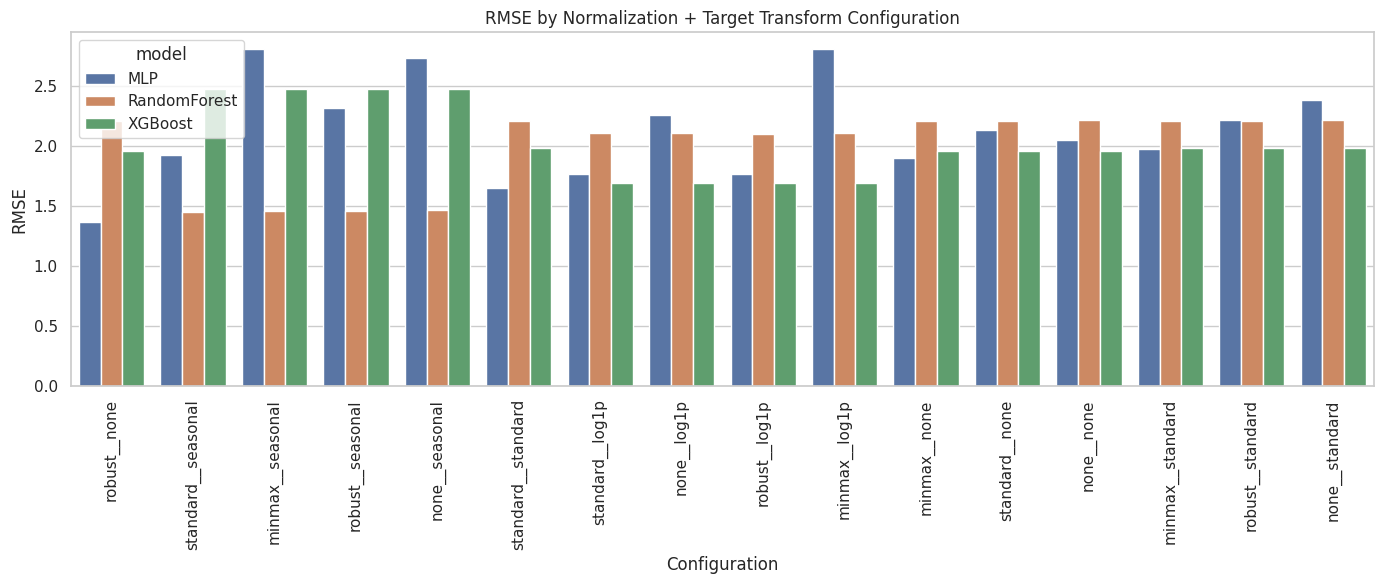

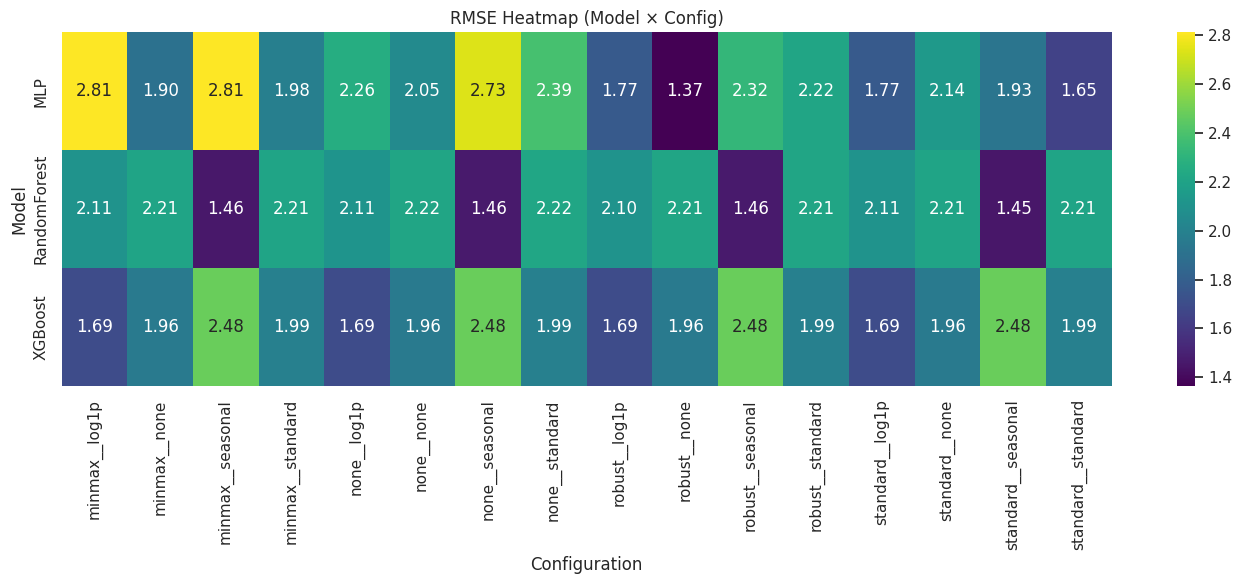

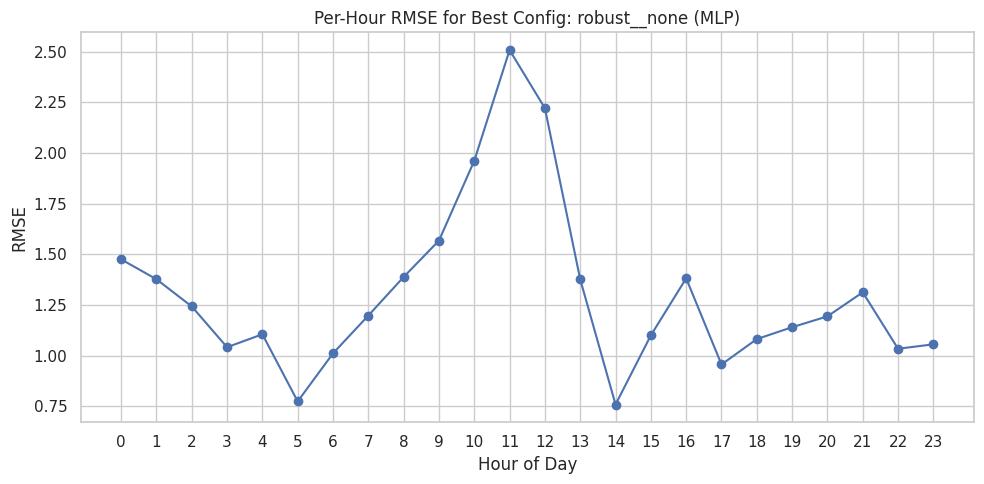

In [ ]:
# Ensure summary_df exists
df_plot = summary_df.copy()
df_plot = df_plot.sort_values("rmse")

plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x="config", y="rmse", hue="model")
plt.xticks(rotation=90)
plt.title("RMSE by Normalization + Target Transform Configuration")
plt.ylabel("RMSE")
plt.xlabel("Configuration")
plt.tight_layout()
plt.show()


pivot_rmse = summary_df.pivot_table(
    index="model",
    columns="config",
    values="rmse"
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_rmse, annot=True, fmt=".2f", cmap="viridis")
plt.title("RMSE Heatmap (Model × Config)")
plt.xlabel("Configuration")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# Find best run
best_run = min(full_results, key=lambda r: r["rmse"])

per_hour = best_run["per_hour_rmse"]

plt.figure(figsize=(10, 5))
hours = list(per_hour.keys())
values = list(per_hour.values())

plt.plot(hours, values, marker="o")
plt.title(f"Per-Hour RMSE for Best Config: {best_run['config']} ({best_run['model']})")
plt.xlabel("Hour of Day")
plt.ylabel("RMSE")
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()



It runs all combinations of scalers × target_transforms × models and prints results. It fits scalers ONLY on training set (no leakage).

Seasonal detrending uses a train-derived 168-hour hourly-week profile and is inverted correctly at prediction time.

log1p works when PotActiva is non-negative (typical for load); otherwise you must add offset.

standard target transform fits a StandardScaler on training target and inverts when evaluating.

It computes per-hour RMSE and stores it in the results dictionary — use that to check if errors spike at peak hours.

## Another tactics
The supervised models need per‑timestamp features, not per‑CPE aggregates. + For all CPEs

In [ ]:
def build_feature_matrix(df_cpe, target_col="PotActiva"):
    df = df_cpe.copy()

    # --- Lag features ---
    df["lag_1"] = df[target_col].shift(1)
    df["lag_24"] = df[target_col].shift(24)
    df["lag_96"] = df[target_col].shift(96)
    df["lag_168"] = df[target_col].shift(168)  # 1 week

    # --- Rolling windows ---
    df["roll_mean_24"] = df[target_col].rolling(24).mean()
    df["roll_std_24"] = df[target_col].rolling(24).std()
    df["roll_mean_168"] = df[target_col].rolling(168).mean()

    # --- Time encodings ---
    df["hour"] = df.index.hour
    df["weekday"] = df.index.weekday
    df["month"] = df.index.month
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)

    # --- Fourier seasonal features ---
    df["sin_day"] = np.sin(2*np.pi*df.index.hour/24)
    df["cos_day"] = np.cos(2*np.pi*df.index.hour/24)
    df["sin_week"] = np.sin(2*np.pi*df.index.dayofyear/365)
    df["cos_week"] = np.cos(2*np.pi*df.index.dayofyear/365)

    # Drop rows with NaN from lag/rolling
    df = df.dropna()

    return df

# Split data
def split_train_test(df, target_col="PotActiva"):
    split_idx = int(len(df) * 0.7)
    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]

    X_train = train.drop(columns=[target_col])
    y_train = train[target_col]

    X_test = test.drop(columns=[target_col])
    y_test = test[target_col]

    return X_train, X_test, y_train, y_test

# Scalers
scalers = { "none": None, "standard": StandardScaler(), "minmax": MinMaxScaler(), "robust": RobustScaler() }

# Models to evaluate

models = {
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror"
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1
    ),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    )
}

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    return rmse, mae



Test results


=== Normalization: none ===
XGBoost: RMSE=0.4481, MAE=0.2775
RandomForest: RMSE=0.4805, MAE=0.2899
MLP: RMSE=0.4560, MAE=0.3051

=== Normalization: standard ===
XGBoost: RMSE=0.4445, MAE=0.2744
RandomForest: RMSE=0.4826, MAE=0.2905
MLP: RMSE=0.4808, MAE=0.3449

=== Normalization: minmax ===
XGBoost: RMSE=0.4471, MAE=0.2811
RandomForest: RMSE=0.4804, MAE=0.2895
MLP: RMSE=0.4170, MAE=0.2793

=== Normalization: robust ===
XGBoost: RMSE=0.4475, MAE=0.2776
RandomForest: RMSE=0.4808, MAE=0.2892
MLP: RMSE=0.4943, MAE=0.3568


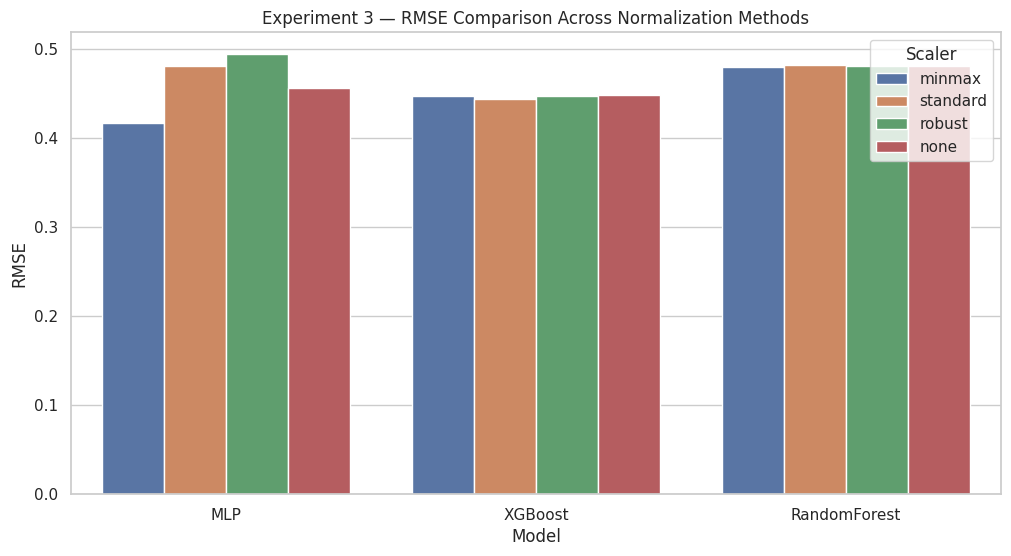

In [ ]:
# Re-obtain target_cpe and df_hourly (if not already globally available or might have changed)
main_cluster_cpes = final_features_clean[final_features_clean["cluster_dbscan"] == 0].index.tolist()
target_cpe = main_cluster_cpes[0]
df_model = df_clean[df_clean["CPE"].isin(df_clean["CPE"].unique())].copy().sort_index()
df_hourly = df_model[['PotActiva']].resample('H').mean().replace([np.inf, -np.inf], np.nan).dropna()


# Build features
feature_matrix_df = build_feature_matrix(df_hourly, target_col="PotActiva")

# Split data
X_train, X_test, y_train, y_test = split_train_test(feature_matrix_df, target_col="PotActiva")

results = []

for scaler_name, scaler in scalers.items():
    print(f"\n=== Normalization: {scaler_name} ===")

    # Apply scaling
    if scaler is None:
        X_train_scaled = X_train.values
        X_test_scaled = X_test.values
    else:
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        rmse, mae = evaluate_model(
            model,
            X_train_scaled, y_train,
            X_test_scaled, y_test
        )

        results.append({
            "Scaler": scaler_name,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae
        })

        print(f"{model_name}: RMSE={rmse:.4f}, MAE={mae:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE")
results_df

plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x="Model", y="RMSE", hue="Scaler")
plt.title("Experiment 3 — RMSE Comparison Across Normalization Methods")
plt.ylabel("RMSE")
plt.show()

Running normalization experiment for CPE: PT0002000068859187RL
Baseline (t-168) RMSE=1.4218, MAE=0.9315
[none] XGBoost: RMSE=0.8201, MAE=0.4820
[none] RandomForest: RMSE=0.9501, MAE=0.5230
[none] MLP: RMSE=1.1019, MAE=0.6371
[standard] XGBoost: RMSE=0.8731, MAE=0.5102
[standard] RandomForest: RMSE=0.9496, MAE=0.5220
[standard] MLP: RMSE=0.9774, MAE=0.5828
[minmax] XGBoost: RMSE=0.8731, MAE=0.5102
[minmax] RandomForest: RMSE=0.9491, MAE=0.5219
[minmax] MLP: RMSE=0.9256, MAE=0.5576
[robust] XGBoost: RMSE=0.8201, MAE=0.4820
[robust] RandomForest: RMSE=0.9499, MAE=0.5230
[robust] MLP: RMSE=0.9965, MAE=0.5787


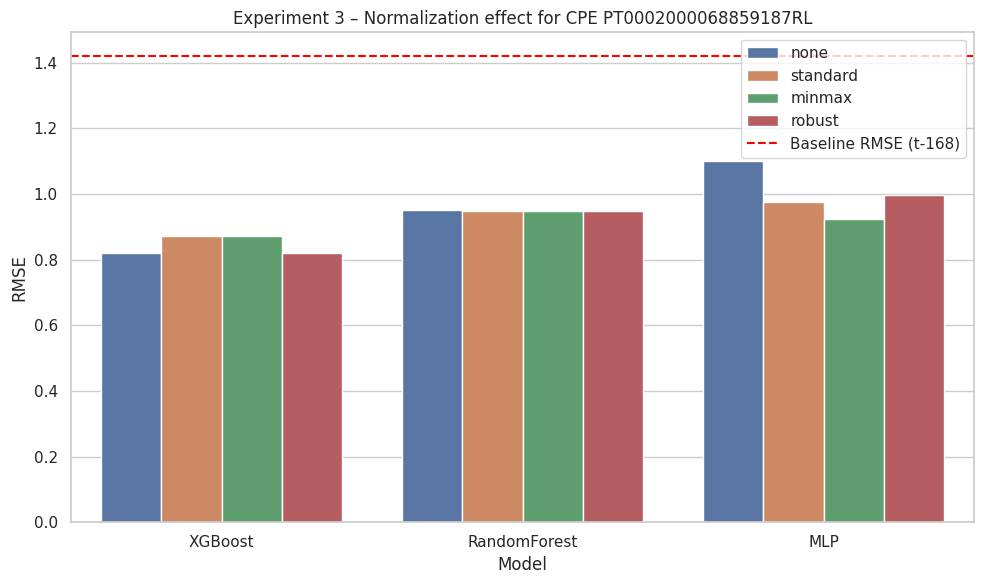

,CPE,Scaler,Model,RMSE,MAE,Baseline_RMSE,Baseline_MAE
0,PT0002000068859187RL,none,XGBoost,0.820074,0.482041,1.421822,0.931548
9,PT0002000068859187RL,robust,XGBoost,0.820074,0.482041,1.421822,0.931548
6,PT0002000068859187RL,minmax,XGBoost,0.873139,0.510204,1.421822,0.931548
3,PT0002000068859187RL,standard,XGBoost,0.873139,0.510204,1.421822,0.931548
8,PT0002000068859187RL,minmax,MLP,0.925557,0.557581,1.421822,0.931548
7,PT0002000068859187RL,minmax,RandomForest,0.949135,0.521939,1.421822,0.931548
4,PT0002000068859187RL,standard,RandomForest,0.949567,0.522008,1.421822,0.931548
10,PT0002000068859187RL,robust,RandomForest,0.949898,0.522981,1.421822,0.931548
1,PT0002000068859187RL,none,RandomForest,0.950068,0.523001,1.421822,0.931548
5,PT0002000068859187RL,standard,MLP,0.977357,0.582755,1.421822,0.931548


In [ ]:
def run_normalization_experiment(target_cpe,
                                 df_clean,
                                 h_eval=168,
                                 plot_results=True): # Add this parameter
    print(f"Running normalization experiment for CPE: {target_cpe}")

    # 1) Hourly series
    df_model = df_clean[df_clean["CPE"] == target_cpe].copy()
    df_hourly = df_model[["PotActiva"]].resample("1H").mean().replace([np.inf, -np.inf], np.nan).dropna()

    # 2) Build features
    df_feat = build_feature_matrix(df_hourly, target_col="PotActiva")

    # 3) Train/test split
    split_idx = int(len(df_feat) * 0.7)
    train = df_feat.iloc[:split_idx]
    test  = df_feat.iloc[split_idx:]

    X_train = train.drop(columns=["PotActiva"])
    y_train = train["PotActiva"]
    X_test  = test.drop(columns=["PotActiva"])
    y_test  = test["PotActiva"]

    h = min(h_eval, len(y_test))
    X_test_1w = X_test.iloc[:h]
    y_test_1w = y_test.iloc[:h]

    # 4) Baseline for reference (t-168)
    y_all = df_hourly["PotActiva"]
    baseline = y_all.shift(168).loc[y_test_1w.index]
    mask = ~baseline.isna()
    baseline_rmse = np.sqrt(mean_squared_error(y_test_1w[mask], baseline[mask]))
    baseline_mae  = mean_absolute_error(y_test_1w[mask], baseline[mask])

    print(f"Baseline (t-168) RMSE={baseline_rmse:.4f}, MAE={baseline_mae:.4f}")

    # 5) Models and scalers
    models = {
        "XGBoost": XGBRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=6,
            subsample=0.9, colsample_bytree=0.9,
            objective="reg:squarederror", random_state=42
        ),
        "RandomForest": RandomForestRegressor(
            n_estimators=400, max_depth=20, min_samples_leaf=5,
            random_state=42, n_jobs=-1
        ),
        "MLP": MLPRegressor(
            hidden_layer_sizes=(128, 64, 32),
            max_iter=400, random_state=42
        )
    }

    scalers = {
        "none": None,
        "standard": StandardScaler(),
        "minmax": MinMaxScaler(),
        "robust": RobustScaler()
    }

    results = []

    from sklearn.base import clone

    for sc_name, sc in scalers.items():
        # Fit scaler only on train
        if sc is None:
            X_tr_sc = X_train.values
            X_te_sc = X_test_1w.values
        else:
            sc_fit = clone(sc).fit(X_train.values)
            X_tr_sc = sc_fit.transform(X_train.values)
            X_te_sc = sc_fit.transform(X_test_1w.values)

        for m_name, m in models.items():
            model = clone(m)
            model.fit(X_tr_sc, y_train.values)
            y_pred = model.predict(X_te_sc)

            rmse = np.sqrt(mean_squared_error(y_test_1w, y_pred))
            mae  = mean_absolute_error(y_test_1w, y_pred)
            print(f"[{sc_name}] {m_name}: RMSE={rmse:.4f}, MAE={mae:.4f}")

            results.append({
                "CPE": target_cpe,
                "Scaler": sc_name,
                "Model": m_name,
                "RMSE": rmse,
                "MAE": mae,
                "Baseline_RMSE": baseline_rmse,
                "Baseline_MAE": baseline_mae
            })

    norm_results = pd.DataFrame(results)

    if plot_results: # Only plot if flag is True
        plt.figure(figsize=(10,6))
        sns.barplot(data=norm_results, x="Model", y="RMSE", hue="Scaler")
        plt.axhline(norm_results["Baseline_RMSE"].iloc[0],
                    color="red", linestyle="--", label="Baseline RMSE (t-168)")
        plt.title(f"Experiment 3 – Normalization effect for CPE {target_cpe}")
        plt.ylabel("RMSE")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return norm_results # Return the DataFrame of results

# Example run:
norm_results = run_normalization_experiment(target_cpe, df_clean)
norm_results.sort_values("RMSE")


In [ ]:
def create_hybrid_dataset(df_clean, target_cpe, static_df):
    df_cpe = df_clean[df_clean['CPE'] == target_cpe].copy()

    if 'tstamp' in df_cpe.columns:
        df_cpe = df_cpe.set_index('tstamp')

    df_hourly = df_cpe[['PotActiva']].resample('H').mean().dropna()

    df_hourly['hour'] = df_hourly.index.hour
    df_hourly['dayofweek'] = df_hourly.index.dayofweek
    df_hourly['lag_168'] = df_hourly['PotActiva'].shift(168)
    df_hourly['lag_336'] = df_hourly['PotActiva'].shift(336)
    df_hourly['roll_mean_168'] = df_hourly['PotActiva'].shift(168).rolling(24).mean()

    df_hourly = df_hourly.dropna()

    cpe_static = static_df[static_df['CPE'] == target_cpe]
    if not cpe_static.empty:
        for col in cpe_static.columns:
            if col != 'CPE':
                df_hourly[col] = cpe_static[col].values[0]

    return df_hourly


def evaluate_models_with_normalization(df_clean, target_cpe, static_df):
    df_hybrid = create_hybrid_dataset(df_clean, target_cpe, static_df)

    if len(df_hybrid) < 500:
        return None

    split_idx = int(len(df_hybrid) * 0.7)
    train = df_hybrid.iloc[:split_idx]
    test  = df_hybrid.iloc[split_idx:]

    target_col = 'PotActiva'
    feature_cols = [c for c in df_hybrid.columns if c != target_col]

    X_train, y_train = train[feature_cols], train[target_col]
    X_test,  y_test  = test[feature_cols],  test[target_col]

    cluster_val = df_hybrid['cluster_dbscan'].iloc[0] if 'cluster_dbscan' in df_hybrid.columns else -1

    results = {'CPE': target_cpe, 'Cluster': cluster_val}


    y_pred_base = X_test['lag_168']
    results['RMSE_Baseline'] = np.sqrt(mean_squared_error(y_test, y_pred_base))


    models = {
        "XGB": XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, random_state=42
        ),
        "RF": RandomForestRegressor(
            n_estimators=200, max_depth=12, n_jobs=-1, random_state=42
        ),
        "MLP": MLPRegressor(
            hidden_layer_sizes=(64, 32), max_iter=300, random_state=42
        )
    }

    scalers = {
        "none": None,
        "standard": StandardScaler(),
        "minmax": MinMaxScaler(),
        "robust": RobustScaler()
    }

    for sc_name, scaler in scalers.items():

        # Scale features
        if scaler is None:
            X_train_sc = X_train.values
            X_test_sc  = X_test.values
        else:
            scaler_fit = scaler.fit(X_train.values)
            X_train_sc = scaler_fit.transform(X_train.values)
            X_test_sc  = scaler_fit.transform(X_test.values)

        for m_name, model in models.items():
            model_fit = clone(model)
            model_fit.fit(X_train_sc, y_train)
            y_pred = model_fit.predict(X_test_sc)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            results[f"RMSE_{m_name}_{sc_name}"] = rmse

    try:
        arima_model = ARIMA(y_train, order=(2,1,2))
        arima_fit = arima_model.fit()
        y_pred_arima = arima_fit.forecast(steps=len(y_test))
        results['RMSE_ARIMA'] = np.sqrt(mean_squared_error(y_test, y_pred_arima))
    except:
        results['RMSE_ARIMA'] = np.nan

    return results





In [ ]:
all_results = []
cpe_list = df_clean['CPE'].unique()

print("Running normalization-aware models for all CPEs...")

for i, cpe in enumerate(cpe_list):
    res = evaluate_models_with_normalization(df_clean, cpe, static_features_subset)
    if res:
        all_results.append(res)

    if i % 10 == 0:
        print(f"Processed {i} CPEs...")

results_df = pd.DataFrame(all_results)
print("Normalization Experiment Completed.")



model_cols = [c for c in results_df.columns if c.startswith("RMSE_")]

results_df["Best_Model"] = results_df[model_cols].idxmin(axis=1)

cluster_analysis = (
    results_df.groupby("Cluster")["Best_Model"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_analysis, annot=True, fmt=".1%", cmap="YlGnBu")
plt.title("Best Model (with Normalization) by Cluster")
plt.ylabel("Cluster ID")
plt.xlabel("Model + Normalization")
plt.show()

print(cluster_analysis)


Running normalization-aware models for all CPEs...
Processed 0 CPEs...
Processed 10 CPEs...
Processed 20 CPEs...
Processed 30 CPEs...


#Prediction for each cluster

Create a function to run the comparison for one cluster


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# --- 1. Metrics & Feature Engineering Helpers (Your provided code) ---

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

def nrmse(y_true, y_pred):
    return rmse(y_true, y_pred) / (np.std(y_true) + 1e-8)

def make_features_15m(s_df, target_col="PotActiva"):
    d = s_df.copy()
    d["hour"]      = d.index.hour
    d["dayofweek"] = d.index.dayofweek
    d["month"]     = d.index.month
    # 15min lags: 1 week = 672 steps
    d["lag_672"]   = d[target_col].shift(672)
    d["lag_1344"]  = d[target_col].shift(1344)
    d["roll_mean_672"] = d[target_col].shift(672).rolling(672).mean()
    d["roll_std_672"]  = d[target_col].shift(672).rolling(672).std()
    d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
    d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)
    return d.dropna()

def make_features_1h(s_df, target_col="PotActiva"):
    d = s_df.copy()
    d["hour"]      = d.index.hour
    d["dayofweek"] = d.index.dayofweek
    d["month"]     = d.index.month
    # Hourly lags: 1 week = 168 steps
    d["lag_168"]   = d[target_col].shift(168)
    d["lag_336"]   = d[target_col].shift(336)
    d["roll_mean_168"] = d[target_col].shift(168).rolling(168).mean()
    d["roll_std_168"]  = d[target_col].shift(168).rolling(168).std()
    d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
    d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)
    return d.dropna()

def weekly_baseline(series, weekly_shift):
    return series.shift(weekly_shift)

def time_split(df, target_col="PotActiva", train_ratio=0.7):
    split_idx = int(len(df) * train_ratio)
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]
    X_train = train.drop(columns=[target_col])
    y_train = train[target_col]
    X_test  = test.drop(columns=[target_col])
    y_test  = test[target_col]
    return X_train, y_train, X_test, y_test

def get_model(model_name="RandomForest"):
    if model_name == "RandomForest":
        return RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    elif model_name == "XGB":
        return XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0)
    else:
        return RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

# 2. Main Comparison Function (Modified for flexible naming)

def compare_15min_vs_hourly(df_clean, target_cpe, cluster_id, target_col="PotActiva", model_name="RandomForest"):

    print(f"\nProcessing CPE: {target_cpe} (Cluster {cluster_id})...")

    # 1) Extract one CPE time series
    df_cpe = df_clean[df_clean["CPE"] == target_cpe].copy().sort_index()
    if df_cpe.empty:
        print(f"No data for CPE {target_cpe}")
        return None

    # 2) 15-minute series (assuming df_clean is 15m)
    s_15m = df_cpe[[target_col]].copy()
    WEEK_SHIFT_15M = 672

    # 3) Hourly series via resample
    s_1h = df_cpe[[target_col]].resample("1H").mean().dropna()
    WEEK_SHIFT_1H  = 168

    # 4) Features
    f_15m = make_features_15m(s_15m, target_col=target_col)
    f_1h  = make_features_1h(s_1h,  target_col=target_col)

    if f_15m.empty or f_1h.empty:
        print("Not enough data for features.")
        return None

    # 5) Split
    Xtr_15m, ytr_15m, Xte_15m, yte_15m = time_split(f_15m, target_col=target_col)
    Xtr_1h,  ytr_1h,  Xte_1h,  yte_1h  = time_split(f_1h,  target_col=target_col)

    # 6) Define 7-day window
    start = max(yte_15m.index.min(), yte_1h.index.min())
    end   = start + pd.Timedelta(days=7)

    # Filter to window
    yte_15m_w = yte_15m.loc[(yte_15m.index >= start) & (yte_15m.index < end)]
    yte_1h_w  = yte_1h.loc[(yte_1h.index >= start)  & (yte_1h.index  < end)]

    if yte_15m_w.empty or yte_1h_w.empty:
        print("Test window empty.")
        return None

    Xte_15m_w = Xte_15m.loc[yte_15m_w.index]
    Xte_1h_w  = Xte_1h.loc[yte_1h_w.index]

    # 7) Baselines
    base_15m_w = weekly_baseline(s_15m[target_col], WEEK_SHIFT_15M).loc[yte_15m_w.index]
    base_1h_w  = weekly_baseline(s_1h[target_col],  WEEK_SHIFT_1H).loc[yte_1h_w.index]

    # 8) Train & Predict
    model_15m = get_model(model_name)
    model_1h  = get_model(model_name)

    model_15m.fit(Xtr_15m.values, ytr_15m.values)
    pred_15m_w = model_15m.predict(Xte_15m_w.values)

    model_1h.fit(Xtr_1h.values, ytr_1h.values)
    pred_1h_w = model_1h.predict(Xte_1h_w.values)

    # 9) Metrics
    metrics = {
        "15m": {
            "RMSE_base": rmse(yte_15m_w, base_15m_w), "RMSE_model": rmse(yte_15m_w, pred_15m_w),
            "NRMSE_base": nrmse(yte_15m_w, base_15m_w), "NRMSE_model": nrmse(yte_15m_w, pred_15m_w),
            "N_points": len(yte_15m_w)
        },
        "1h": {
            "RMSE_base": rmse(yte_1h_w, base_1h_w), "RMSE_model": rmse(yte_1h_w, pred_1h_w),
            "NRMSE_base": nrmse(yte_1h_w, base_1h_w), "NRMSE_model": nrmse(yte_1h_w, pred_1h_w),
            "N_points": len(yte_1h_w)
        }
    }

    # 10) Plot
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.2])

    # (A) 15-minute
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(yte_15m_w.index, yte_15m_w.values, label="Actual 15'", color="#1f77b4", lw=1)
    ax1.plot(yte_15m_w.index, pred_15m_w, label="Model 15'", color="#2ca02c", alpha=0.8)
    ax1.set_title(f"Cluster {cluster_id} Rep ({target_cpe}): 15-min Forecast")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # (B) Hourly
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(yte_1h_w.index, yte_1h_w.values, label="Actual 1h", color="#1f77b4", lw=1.5)
    ax2.plot(yte_1h_w.index, pred_1h_w, label="Model 1h", color="#2ca02c", alpha=0.8)
    ax2.set_title(f"Cluster {cluster_id} Rep ({target_cpe}): Hourly Forecast")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # (C) Bar Chart
    ax3 = fig.add_subplot(gs[1, :])
    labels = ["15' Base", "15' Model", "1h Base", "1h Model"]
    vals = [metrics["15m"]["NRMSE_base"], metrics["15m"]["NRMSE_model"],
            metrics["1h"]["NRMSE_base"], metrics["1h"]["NRMSE_model"]]
    colors = ["#ff7f0e", "#2ca02c", "#ff7f0e", "#2ca02c"]

    bars = ax3.bar(labels, vals, color=colors)
    ax3.set_title("NRMSE Comparison (Lower is Better)")
    ax3.set_ylabel("NRMSE")
    ax3.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show() # Display immediately

    return metrics

# 3. Execution Loop (One Rep Per Cluster)

# 1. Identify Representatives (if not already defined)
if 'static_features_subset' in locals():
    representative_cpes = static_features_subset.groupby('cluster_dbscan')['CPE'].first().tolist()
else:
    # Fallback: just take first 3 CPEs if static features aren't loaded
    representative_cpes = df_clean['CPE'].unique()[:3]
    print("Warning: Cluster info not found, running on first 3 CPEs.")

# 2. Run Loop
results_comparison = []

print(f"Running comparison for Representatives: {representative_cpes}\n")

for cpe in representative_cpes:

    # Get cluster ID
    try:
        c_id = static_features_subset[static_features_subset['CPE']==cpe]['cluster_dbscan'].values[0]
    except:
        c_id = "Unknown"

    # Run the comparison
    res = compare_15min_vs_hourly(df_clean, target_cpe=cpe, cluster_id=c_id, model_name="RandomForest")

    if res:
        results_comparison.append((cpe, c_id, res))

11-clusters from k-means

In [ ]:

def create_hybrid_dataset(df_clean, target_cpe, static_df):
    """
    Creates a dataset merging time-series data with static features (including Clusters).
    """
    df_cpe = df_clean[df_clean['CPE'] == target_cpe].copy()

    # Ensure timestamp index
    if 'tstamp' in df_cpe.columns:
        df_cpe['tstamp'] = pd.to_datetime(df_cpe['tstamp'])
        df_cpe = df_cpe.set_index('tstamp')

    # Resample to Hourly
    df_hourly = df_cpe[['PotActiva']].resample('H').mean().dropna()

    # Create Features
    df_hourly['hour'] = df_hourly.index.hour
    df_hourly['dayofweek'] = df_hourly.index.dayofweek
    df_hourly['lag_168'] = df_hourly['PotActiva'].shift(168) # 1 week
    df_hourly['lag_336'] = df_hourly['PotActiva'].shift(336) # 2 weeks
    df_hourly['roll_mean_168'] = df_hourly['PotActiva'].shift(168).rolling(24).mean()

    df_hourly = df_hourly.dropna()

    # Merge Static Features (This brings in 'cluster_kmeans')
    cpe_static = static_df[static_df['CPE'] == target_cpe]

    if not cpe_static.empty:
        for col in cpe_static.columns:
            if col != 'CPE':
                # Broadcast static value to all time steps
                df_hourly[col] = cpe_static[col].values[0]

    return df_hourly

def evaluate_models_with_normalization(df_clean, target_cpe, static_df):

    # Create dataset
    df_hybrid = create_hybrid_dataset(df_clean, target_cpe, static_df)

    # Check data sufficiency
    if len(df_hybrid) < 500:
        return None

    # Split Train/Test (Last 30% as test)
    split_idx = int(len(df_hybrid) * 0.7)
    train = df_hybrid.iloc[:split_idx]
    test  = df_hybrid.iloc[split_idx:]

    target_col = 'PotActiva'
    feature_cols = [c for c in df_hybrid.columns if c != target_col]

    X_train, y_train = train[feature_cols], train[target_col]
    X_test,  y_test  = test[feature_cols],  test[target_col]

    cluster_val = df_hybrid['cluster_kmeans'].iloc[0] if 'cluster_kmeans' in df_hybrid.columns else -1

    results = {'CPE': target_cpe, 'Cluster': cluster_val}

    y_pred_base = X_test['lag_168']
    results['RMSE_Baseline'] = np.sqrt(mean_squared_error(y_test, y_pred_base))


    models = {
        "XGB": XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1
        ),
        "RF": RandomForestRegressor(
            n_estimators=200, max_depth=12, n_jobs=-1, random_state=42
        ),
        "MLP": MLPRegressor(
            hidden_layer_sizes=(64, 32), max_iter=300, random_state=42
        )
    }


    scalers = {
        "none": None,
        "standard": StandardScaler(),
        "minmax": MinMaxScaler(),
        "robust": RobustScaler()
    }

    for sc_name, scaler in scalers.items():

        # Scale features
        if scaler is None:
            X_train_sc = X_train.values
            X_test_sc  = X_test.values
        else:
            scaler_fit = scaler.fit(X_train.values)
            X_train_sc = scaler_fit.transform(X_train.values)
            X_test_sc  = scaler_fit.transform(X_test.values)

        for m_name, model in models.items():
            try:
                model_fit = clone(model)
                model_fit.fit(X_train_sc, y_train)
                y_pred = model_fit.predict(X_test_sc)

                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                results[f"RMSE_{m_name}_{sc_name}"] = rmse
            except Exception as e:
                results[f"RMSE_{m_name}_{sc_name}"] = np.nan


    try:
        # Simple ARIMA on the target variable only
        arima_model = ARIMA(y_train, order=(2,1,2))
        arima_fit = arima_model.fit()
        y_pred_arima = arima_fit.forecast(steps=len(y_test))
        results['RMSE_ARIMA'] = np.sqrt(mean_squared_error(y_test, y_pred_arima))
    except:
        results['RMSE_ARIMA'] = np.nan

    return results


all_results = []

static_df_input = final_features_clean.reset_index()

# 1. Identify Representatives for the 11 K-Means Clusters
representatives_list = static_df_input.sort_values('cluster_kmeans').groupby('cluster_kmeans')['CPE'].first().tolist()

print(f"Running normalization experiments for {len(representatives_list)} Cluster Representatives...")
print(f"Representatives: {representatives_list}\n")

for i, cpe in enumerate(representatives_list):
    print(f"Processing Rep {i+1}/{len(representatives_list)}: {cpe}...")

    # Pass the static df that contains 'cluster_kmeans'
    res = evaluate_models_with_normalization(df_clean, cpe, static_df_input)

    if res:
        all_results.append(res)

print("\nNormalization Experiment Completed.")

results_df = pd.DataFrame(all_results)

# Identify the columns that contain RMSE results
model_cols = [c for c in results_df.columns if c.startswith("RMSE_")]

# Find the column name with the minimum RMSE for each row
results_df["Best_Model_Config"] = results_df[model_cols].idxmin(axis=1)
results_df["Best_RMSE"] = results_df[model_cols].min(axis=1)

# Display table of Best Model per Cluster
summary_table = results_df[["Cluster", "CPE", "Best_Model_Config", "Best_RMSE", "RMSE_Baseline"]].sort_values("Cluster")

print("\n--- Best Model Configuration per K-Means Cluster ---")
print(summary_table)

if not results_df.empty:
    plt.figure(figsize=(12, 8))

    # We plot the Best RMSE vs Baseline RMSE for each Cluster Representative

    plot_data = results_df.melt(id_vars=['Cluster'],
                                value_vars=['Best_RMSE', 'RMSE_Baseline'],
                                var_name='Metric', value_name='RMSE')

    sns.barplot(data=plot_data, x='Cluster', y='RMSE', hue='Metric', palette=['#2ca02c', '#d62728'])

    plt.title('Best Model RMSE vs Baseline (Naive) by K-Means Cluster')
    plt.ylabel('RMSE (kW)')
    plt.xlabel('Cluster ID (K-Means)')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    plt.figure(figsize=(14, 8))

    heatmap_data = results_df.set_index('Cluster')[model_cols]
    sns.heatmap(heatmap_data, cmap='viridis_r', annot=False)
    plt.title('RMSE Heatmap: Models (columns) vs Clusters (rows)')
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

def predict_and_plot_best_model(df_clean, target_cpe, static_df, model_config_str):
    """
    Retrains the best model configuration for a specific CPE and plots the results.
    model_config_str format expected: 'RMSE_ModelName_ScalerName' (e.g. 'RMSE_XGB_standard')
    """

    # 1. Parse Configuration
    parts = model_config_str.replace('RMSE_', '').split('_')

    if len(parts) == 1 and parts[0] == 'ARIMA':
        model_name = 'ARIMA'
        scaler_name = 'none'
    elif len(parts) >= 2:
        model_name = parts[0]
        scaler_name = parts[1]
    else:
        # Fallback
        model_name = 'XGB'
        scaler_name = 'standard'

    print(f"Generating plot for {target_cpe} using [Model: {model_name}, Scaler: {scaler_name}]...")

    # 2. Prepare Data (Reuse existing function)
    df_hybrid = create_hybrid_dataset(df_clean, target_cpe, static_df)

    if len(df_hybrid) < 100:
        print(f"Not enough data for {target_cpe}")
        return

    # 3. Train/Test Split
    split_idx = int(len(df_hybrid) * 0.7)
    train = df_hybrid.iloc[:split_idx]
    test  = df_hybrid.iloc[split_idx:]

    target_col = 'PotActiva'
    feature_cols = [c for c in df_hybrid.columns if c != target_col]

    X_train, y_train = train[feature_cols], train[target_col]
    X_test,  y_test  = test[feature_cols],  test[target_col]

    # 4. Handle ARIMA Separately
    if model_name == 'ARIMA':
        try:
            # Re-fit ARIMA
            model = ARIMA(y_train, order=(2,1,2))
            model_fit = model.fit()
            y_pred = model_fit.forecast(steps=len(y_test))
            y_pred.index = y_test.index # Align index
        except:
            print(f"ARIMA failed for {target_cpe}")
            return

    else:
        # 5. Handle ML Models (XGB, RF, MLP)
        scalers = {
            "none": None,
            "standard": StandardScaler(),
            "minmax": MinMaxScaler(),
            "robust": RobustScaler()
        }
        scaler = scalers.get(scaler_name, None)

        # Scale Data
        if scaler:
            scaler_fit = scaler.fit(X_train.values)
            X_train_vals = scaler_fit.transform(X_train.values)
            X_test_vals  = scaler_fit.transform(X_test.values)
        else:
            X_train_vals = X_train.values
            X_test_vals  = X_test.values

        model_dict = {
            "XGB": XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1),
            "RF": RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
            "MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
        }

        model = model_dict.get(model_name)
        if not model:
            print(f"Model {model_name} not found.")
            return

        # Fit & Predict
        model.fit(X_train_vals, y_train)
        y_pred_vals = model.predict(X_test_vals)
        y_pred = pd.Series(y_pred_vals, index=y_test.index)

    # 6. Calculate Final RMSE for Display
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # 7. Plotting
    plt.figure(figsize=(14, 6))

    # Plot a portion of Training data (last 200 points) to show continuity
    plt.plot(y_train.index[-200:], y_train.iloc[-200:], label='Training Data (End)', color='gray', alpha=0.5)

    # Plot Actual Test Data
    plt.plot(y_test.index, y_test, label='Actual Test Data', color='#1f77b4', linewidth=1.5)

    # Plot Predictions
    plt.plot(y_pred.index, y_pred, label=f'Prediction ({model_name})', color='#ff7f0e', linestyle='--', linewidth=1.5)

    plt.title(f"Cluster {df_hybrid['cluster_kmeans'].iloc[0]:.0f} Rep: {target_cpe} | Best Model: {model_name} + {scaler_name} | RMSE: {rmse:.3f}")
    plt.xlabel('Time')
    plt.ylabel('Active Power (PotActiva)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n--- Generating Forecast Plots for Representatives ---")

# Ensure 'results_df' exists from the previous step
if 'results_df' in locals() and not results_df.empty:

    # Iterate through the representatives we analyzed
    for idx, row in results_df.iterrows():
        cpe = row['CPE']
        best_config = row['Best_Model_Config']

        # Call the plotting function
        predict_and_plot_best_model(df_clean, cpe, static_df_input, best_config)

else:
    print("Error: 'results_df' not found. Please run the evaluation step first.")

In [ ]:

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def nrmse(y_true, y_pred):
    return rmse(y_true, y_pred) / (np.std(y_true) + 1e-8)

def make_features_15m(s_df, target_col="PotActiva"):
    d = s_df.copy()
    d["hour"]      = d.index.hour
    d["dayofweek"] = d.index.dayofweek
    d["month"]     = d.index.month
    # 15min lags: 1 week = 672 steps (4 * 24 * 7)
    d["lag_672"]   = d[target_col].shift(672)
    d["lag_1344"]  = d[target_col].shift(1344)
    d["roll_mean_672"] = d[target_col].shift(672).rolling(672).mean()
    d["roll_std_672"]  = d[target_col].shift(672).rolling(672).std()
    d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
    d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)
    return d.dropna()

def make_features_1h(s_df, target_col="PotActiva"):
    d = s_df.copy()
    d["hour"]      = d.index.hour
    d["dayofweek"] = d.index.dayofweek
    d["month"]     = d.index.month
    # Hourly lags: 1 week = 168 steps
    d["lag_168"]   = d[target_col].shift(168)
    d["lag_336"]   = d[target_col].shift(336)
    d["roll_mean_168"] = d[target_col].shift(168).rolling(168).mean()
    d["roll_std_168"]  = d[target_col].shift(168).rolling(168).std()
    d["sin_day"] = np.sin(2 * np.pi * d.index.hour / 24)
    d["cos_day"] = np.cos(2 * np.pi * d.index.hour / 24)
    return d.dropna()

def weekly_baseline(series, weekly_shift):
    return series.shift(weekly_shift)

def time_split(df, target_col="PotActiva", train_ratio=0.7):
    split_idx = int(len(df) * train_ratio)
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]
    X_train = train.drop(columns=[target_col])
    y_train = train[target_col]
    X_test  = test.drop(columns=[target_col])
    y_test  = test[target_col]
    return X_train, y_train, X_test, y_test

def get_model(model_name="RandomForest"):
    if model_name == "RandomForest":
        return RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    elif model_name == "XGB":
        return XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0, n_jobs=-1)
    else:
        return RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

def compare_15min_vs_hourly(df_clean, target_cpe, cluster_id, target_col="PotActiva", model_name="RandomForest"):

    print(f"\nProcessing CPE: {target_cpe} (Cluster {cluster_id})...")

    # 1) Extract one CPE time series
    df_cpe = df_clean[df_clean["CPE"] == target_cpe].copy()

    # Ensure datetime index
    if 'tstamp' in df_cpe.columns:
        df_cpe['tstamp'] = pd.to_datetime(df_cpe['tstamp'])
        df_cpe = df_cpe.set_index('tstamp')

    df_cpe = df_cpe.sort_index()

    if df_cpe.empty:
        print(f"No data for CPE {target_cpe}")
        return None

    # 2) 15-minute series (assuming df_clean is 15m raw data)
    s_15m = df_cpe[[target_col]].copy()
    WEEK_SHIFT_15M = 672

    # 3) Hourly series via resample
    s_1h = df_cpe[[target_col]].resample("1H").mean().dropna()
    WEEK_SHIFT_1H  = 168

    # 4) Features
    f_15m = make_features_15m(s_15m, target_col=target_col)
    f_1h  = make_features_1h(s_1h,  target_col=target_col)

    if f_15m.empty or f_1h.empty:
        print("Not enough data for features.")
        return None

    # 5) Split
    Xtr_15m, ytr_15m, Xte_15m, yte_15m = time_split(f_15m, target_col=target_col)
    Xtr_1h,  ytr_1h,  Xte_1h,  yte_1h  = time_split(f_1h,  target_col=target_col)

    # 6) Define 7-day window for evaluation
    start = max(yte_15m.index.min(), yte_1h.index.min())
    end   = start + pd.Timedelta(days=7)

    # Filter to window
    yte_15m_w = yte_15m.loc[(yte_15m.index >= start) & (yte_15m.index < end)]
    yte_1h_w  = yte_1h.loc[(yte_1h.index >= start)  & (yte_1h.index  < end)]

    if yte_15m_w.empty or yte_1h_w.empty:
        print("Test window empty.")
        return None

    Xte_15m_w = Xte_15m.loc[yte_15m_w.index]
    Xte_1h_w  = Xte_1h.loc[yte_1h_w.index]

    # 7) Baselines
    base_15m_w = weekly_baseline(s_15m[target_col], WEEK_SHIFT_15M).loc[yte_15m_w.index]
    base_1h_w  = weekly_baseline(s_1h[target_col],  WEEK_SHIFT_1H).loc[yte_1h_w.index]

    # 8) Train & Predict
    model_15m = get_model(model_name)
    model_1h  = get_model(model_name)

    # Fit on all training data
    model_15m.fit(Xtr_15m.values, ytr_15m.values)
    pred_15m_w = model_15m.predict(Xte_15m_w.values)

    model_1h.fit(Xtr_1h.values, ytr_1h.values)
    pred_1h_w = model_1h.predict(Xte_1h_w.values)

    # 9) Metrics
    metrics = {
        "15m": {
            "RMSE_base": rmse(yte_15m_w, base_15m_w), "RMSE_model": rmse(yte_15m_w, pred_15m_w),
            "NRMSE_base": nrmse(yte_15m_w, base_15m_w), "NRMSE_model": nrmse(yte_15m_w, pred_15m_w),
            "N_points": len(yte_15m_w)
        },
        "1h": {
            "RMSE_base": rmse(yte_1h_w, base_1h_w), "RMSE_model": rmse(yte_1h_w, pred_1h_w),
            "NRMSE_base": nrmse(yte_1h_w, base_1h_w), "NRMSE_model": nrmse(yte_1h_w, pred_1h_w),
            "N_points": len(yte_1h_w)
        }
    }

    # 10) Plot
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.2])

    # (A) 15-minute
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(yte_15m_w.index, yte_15m_w.values, label="Actual 15'", color="#1f77b4", lw=1)
    ax1.plot(yte_15m_w.index, pred_15m_w, label="Model 15'", color="#2ca02c", alpha=0.8)
    ax1.set_title(f"Cluster {int(cluster_id)} Rep ({target_cpe}): 15-min Forecast")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # (B) Hourly
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(yte_1h_w.index, yte_1h_w.values, label="Actual 1h", color="#1f77b4", lw=1.5)
    ax2.plot(yte_1h_w.index, pred_1h_w, label="Model 1h", color="#2ca02c", alpha=0.8)
    ax2.set_title(f"Cluster {int(cluster_id)} Rep ({target_cpe}): Hourly Forecast")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # (C) Bar Chart
    ax3 = fig.add_subplot(gs[1, :])
    labels = ["15' Base", "15' Model", "1h Base", "1h Model"]
    vals = [metrics["15m"]["NRMSE_base"], metrics["15m"]["NRMSE_model"],
            metrics["1h"]["NRMSE_base"], metrics["1h"]["NRMSE_model"]]
    colors = ["#ff7f0e", "#2ca02c", "#ff7f0e", "#2ca02c"]

    bars = ax3.bar(labels, vals, color=colors)
    ax3.set_title("NRMSE Comparison (Lower is Better)")
    ax3.set_ylabel("NRMSE")
    ax3.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return metrics


print("Selecting representatives from K-Means clusters...")

if 'final_features_clean' in locals():
    # Sort by cluster to keep order 0, 1, 2...
    df_sorted = final_features_clean.reset_index().sort_values('cluster_kmeans')

    # Select first CPE from each cluster
    representative_cpes = df_sorted.groupby('cluster_kmeans')['CPE'].first().tolist()

    print(f"Representatives: {representative_cpes}")
else:
    print("Error: 'final_features_clean' not found. Please run the K-Means clustering step first.")
    representative_cpes = []

# Run the Comparison Loop
results_comparison = []

if representative_cpes:
    print(f"\nStarting 15m vs 1h Comparison for {len(representative_cpes)} clusters...\n")

    for cpe in representative_cpes:
        # Retrieve the K-Means cluster ID
        try:
            c_id = final_features_clean.loc[cpe, 'cluster_kmeans']
        except KeyError:
            # Fallback if CPE is not in index, try searching column
            c_id = final_features_clean[final_features_clean['CPE'] == cpe]['cluster_kmeans'].values[0]

        # Run the logic
        res = compare_15min_vs_hourly(
            df_clean,
            target_cpe=cpe,
            cluster_id=c_id,
            model_name="RandomForest"
        )

        if res:
            results_comparison.append((cpe, c_id, res))